# Lección 9.2 · Pipeline con bcftools: del BAM a un VCF en el que se pueda confiar

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-09-variantes/9.2_pipeline_bcftools.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 9 — Detección de variantes** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 7.2 (BWA-MEM, samtools, MAPQ), 7.3 (pileup y cobertura) y 9.1 (PL, θ, QUAL, GQ); manejo básico de la terminal |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Leer** un archivo **VCF** campo a campo (cabecera `##`, las ocho columnas fijas, `FORMAT` y la columna de la
   muestra) y **reconocer** los errores clásicos: coordenadas 1-based, base de anclaje de los *indels*, fase `0/1`
   frente a `0|1`, número de PL con $k$ alelos.
2. **Ejecutar** y **justificar**, opción por opción, el flujo del libro con `bcftools` (`mpileup` → `call -mv` →
   `norm -f -m -any` → `filter` → `stats`) sobre lecturas **reales** del clon del experimento de evolución a largo
   plazo de Lenski (LTEE), desde el FASTQ hasta la razón ti/tv.
3. **Explicar** con los PL y la distribución *a priori* $\theta$ de la Lección 9.1 por qué casi todas las llamadas
   seguras tienen exactamente `QUAL=225.417`, y reconocer los avisos inofensivos de la cabecera.
4. **Normalizar** *indels* a mano y con el algoritmo de Tan *et al.* (2015), y **comprobar** que las
   representaciones de una misma deleción convergen a un único registro, en el ejemplo del libro y en las
   repeticiones reales del clon.
5. **Diagnosticar** un racimo real de falsas SNV (sobre copias repetidas de genes Ldr) con DP, DP4, MQ y la distancia
   de edición de las lecturas, y **decidir** qué filtros lo eliminan y cuáles no.
6. **Usar** la razón **ti/tv** como termómetro (ecuación 09-titv) y **descubrir** cuándo ese termómetro engaña.
7. **Evaluar** un llamador al estilo de Genome in a Bottle/hap.py con precisión, sensibilidad y $F_1$
   (ecuación 09-metricas), **submuestrear** las lecturas a 5, 10, 20 y 40× y **elegir** un umbral de QUAL con una
   curva precisión-sensibilidad.

## 🗺️ Mapa de la clase

1. El problema: confirmar qué mutaciones lleva un clon (y validar un pipeline clínico)
2. El formato VCF, campo a campo (🔍 interactivo con las 40 llamadas reales)
3. El flujo de trabajo con `bcftools`, en vivo: índice, mapeo, `mpileup`, `call`, `norm`, `filter`, `stats`
4. La línea de montaje lectura a lectura y el techo de QUAL = 225.417 (🎬 animación)
5. Normalización de *indels*: el ejemplo del libro y las repeticiones reales
6. Filtrado: el caso real del racimo Ldr
7. La razón ti/tv como termómetro (🔍 interactivo) … y cuándo se estropea
8. Evaluar frente a la verdad: Genome in a Bottle, hap.py y nuestro mini-GIAB con submuestreo (🔍 interactivo)
9. Elegir el umbral de QUAL (🎬 animación)
10. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Pipeline con bcftools» del capítulo 9 del libro
> *Bioinformática Práctica*. Usamos los mismos comandos, los mismos símbolos ($R_T$, $R_F$, $p$, $\alpha$, TP, FP,
> FN) y reproducimos con código, cifra por cifra, sus ejemplos resueltos («Normalizar paso a paso», «Leer un informe
> de hap.py» y la simulación de la curva precisión-sensibilidad). El notebook se puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, math, time, shutil, subprocess, collections
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle

# pysam: la interfaz de Python a htslib (lee BAM y VCF); en Colab se instala con pip
try:
    import pysam
except ImportError:
    %pip install -q pysam
    import pysam

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

CHROM = "NC_012967.1"                         # cromosoma de E. coli B REL606 (el ancestro del LTEE)
THETA = 1.1e-3                                # -P por omisión de bcftools call: el θ de la Lección 9.1
LDR = (1_269_316, 1_270_493)                  # tramo con las tres copias de genes Ldr (toxina-antitoxina tipo I)
rng = np.random.default_rng(92)               # semilla fija: todos obtenemos los mismos números
pysam.set_verbosity(0)                        # silencia los avisos de htslib al abrir VCF sin índice
print("pysam", pysam.__version__, "· Listo para la Lección 9.2")

Entorno listo ✔  |  Colab: False
pysam 0.24.1 · Listo para la Lección 9.2


## 1. El problema: confirmar qué mutaciones lleva un clon

Imagine el laboratorio que mantiene el **experimento de evolución a largo plazo** (LTEE) de Richard Lenski: doce
poblaciones de *Escherichia coli* que se propagan desde 1988 a partir de un mismo ancestro, la cepa **REL606**. De
vez en cuando se congela un **clon** y se secuencia su genoma para saber **qué mutaciones acumuló**. En este curso
seguimos a uno de ellos, el clon **REL7179B** (corrida SRR2584863 del proyecto de Tenaillon *et al.*, 2016): en la
Lección 6.2 controlamos la calidad de sus lecturas, en el Módulo 7 las mapeamos contra REL606 y en el Módulo 8
ensamblamos su genoma. En la Lección 9.1 aprendimos a pasar de una columna de bases a un genotipo con una medida
honesta de confianza. Hoy toca responder la pregunta práctica:

> **¿Qué lista de mutaciones le entregamos al investigador, y cuánto podemos confiar en ella?**

La pregunta no es exclusiva de las bacterias. Un **laboratorio clínico** que ofrece secuenciación de exomas debe
demostrar ante un ente acreditador que su pipeline encuentra las variantes reales (sensibilidad) y que casi no
inventa variantes falsas (precisión). Para ello secuencia una muestra de referencia cuyo genotipo verdadero se conoce
(las muestras de **Genome in a Bottle**, como HG002) y compara. Hoy haremos exactamente eso, a escala de laboratorio,
con nuestro clon: construiremos un conjunto de verdad con las lecturas a ~90× de profundidad media y veremos qué pasa con
el mismo pipeline cuando sólo tenemos 5, 10, 20 o 40 lecturas por posición.

### La cocina de un restaurante

En la cocina de un buen restaurante nadie cocina "un plato": una estación prepara los ingredientes, otra cocina, otra
emplata y un jefe prueba cada plato antes de que salga. Cada estación recibe algo en un formato conocido y entrega algo
en otro formato conocido; si un plato sale mal, se sabe en qué estación buscar. Y el restaurante no mide su calidad por
lo bien que **cree** que cocina, sino por lo que dicen los comensales. Un flujo de llamado de variantes funciona igual:

| Estación | Herramienta | Recibe | Entrega |
|---|---|---|---|
| preparar los ingredientes | `bcftools mpileup` | BAM + referencia | columnas de bases y verosimilitudes $P(D\mid G)$ (PL) |
| cocinar | `bcftools call -mv` | PL | genotipo (GT) y QUAL de cada sitio variable |
| emplatar | `bcftools norm` | VCF crudo | cada variante en su forma canónica, una por línea |
| probar | `bcftools filter` | VCF normalizado | la columna `FILTER` marcada (`PASS` o el motivo del rechazo) |
| el comensal exigente | `bcftools stats`, `hap.py` + GIAB | VCF final | ti/tv, precisión, sensibilidad |

> 🤔 **Antes de seguir, prediga.** El clon lleva unas pocas decenas de mutaciones en 4.6 millones de bases. Si el
> pipeline se equivocara en una de cada 10 000 posiciones, ¿cuántas variantes falsas aparecerían en el genoma?
> ¿Muchas o pocas comparadas con las verdaderas? (Respuesta: $4.6\times10^6/10^4 = 460$ falsas frente a ~25
> verdaderas. Por eso un llamador necesita tasas de error de **uno en millones**, y por eso filtramos y evaluamos.)

## 2. El formato VCF, campo a campo

Antes de producir variantes necesitamos un lugar donde escribirlas. El **Variant Call Format** (VCF) fue diseñado para
el Proyecto 1000 Genomas como un formato de texto tabulado, extensible y capaz de representar desde una SNV hasta
variantes estructurales para miles de muestras (Danecek *et al.*, 2011). Su versión binaria comprimida, **BCF**, es la
que `bcftools` usa internamente para ganar velocidad.

Un VCF tiene dos partes:

* La **cabecera**: líneas que empiezan por `##`. Declara la versión del formato, la referencia, los contigs y, sobre
  todo, **el significado de cada campo** `INFO`, `FORMAT` y `FILTER`. Es un archivo que se describe a sí mismo: un
  campo que no está declarado en la cabecera no debería aparecer en los registros.
* El **cuerpo**: una línea por sitio variable, con **ocho columnas fijas** (`CHROM`, `POS`, `ID`, `REF`, `ALT`, `QUAL`,
  `FILTER`, `INFO`), seguidas opcionalmente de `FORMAT` y de una columna por muestra.

### El registro del libro: la columna 8 de la Lección 9.1

El libro usa este registro, que corresponde a la "columna 8" que resolvimos a mano en la Lección 9.1 (seis lecturas,
tres `A` y tres `G`):

```
##fileformat=VCFv4.2
##reference=GRCh38.fa
##INFO=<ID=DP,Number=1,Type=Integer,Description="Profundidad total">
##FORMAT=<ID=PL,Number=G,Type=Integer,Description="Verosimilitudes Phred">
##FILTER=<ID=BajaCal,Description="QUAL<30 || DP<10">
#CHROM  POS    ID  REF  ALT  QUAL  FILTER  INFO                   FORMAT          muestra1
chr1    10408  .   A    G    36    PASS    DP=6;AC=1;AN=2;MQ=60   GT:AD:DP:GQ:PL  0/1:3,3:6:36:66,0,76
```

Leámoslo con un pequeño intérprete propio antes de usar bibliotecas: así se ve que no hay magia, sólo texto separado
por tabuladores, `;`, `:` y `,`.

In [2]:
book_record = "chr1\t10408\t.\tA\tG\t36\tPASS\tDP=6;AC=1;AN=2;MQ=60\tGT:AD:DP:GQ:PL\t0/1:3,3:6:36:66,0,76"

def parse_vcf_line(line):
    """Separa un registro VCF en sus campos (sin bibliotecas): 8 columnas fijas + FORMAT + muestras."""
    f = line.rstrip("\n").split("\t")
    rec = dict(zip(["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER"], f[:7]))
    rec["POS"] = int(rec["POS"])
    rec["ALT"] = rec["ALT"].split(",")                      # puede haber varios alelos alternativos
    rec["INFO"] = {kv.split("=")[0]: (kv.split("=")[1] if "=" in kv else True) for kv in f[7].split(";")}
    keys = f[8].split(":")
    rec["SAMPLES"] = [dict(zip(keys, s.split(":"))) for s in f[9:]]
    return rec

rec = parse_vcf_line(book_record)
for k in ["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO"]:
    print(f"{k:7s} → {rec[k]}")
s = rec["SAMPLES"][0]
print("muestra →", s)

alleles = [rec["REF"]] + rec["ALT"]
gt = [alleles[int(i)] for i in re.split(r"[/|]", s["GT"])]
PL = list(map(int, s["PL"].split(",")))
print(f"\nGT {s['GT']} = alelos {gt}  (0 = REF, 1 = primer ALT; '/' = sin fase)")
print(f"PL = (RR, RA, AA) = {PL}: el genotipo con PL 0 es el más verosímil; RR es 10^{PL[0]/10:.1f} ≈ "
      f"{10**(PL[0]/10):.1e} veces menos verosímil")
print(f"GQ = {s['GQ']}: calidad del genotipo calculada con la posterior (Lección 9.1); la diferencia entre los dos PL "
      f"más pequeños daría {sorted(PL)[1]} (la otra convención) · QUAL = {rec['QUAL']}")

CHROM   → chr1
POS     → 10408
ID      → .
REF     → A
ALT     → ['G']
QUAL    → 36
FILTER  → PASS
INFO    → {'DP': '6', 'AC': '1', 'AN': '2', 'MQ': '60'}
muestra → {'GT': '0/1', 'AD': '3,3', 'DP': '6', 'GQ': '36', 'PL': '66,0,76'}

GT 0/1 = alelos ['A', 'G']  (0 = REF, 1 = primer ALT; '/' = sin fase)
PL = (RR, RA, AA) = [66, 0, 76]: el genotipo con PL 0 es el más verosímil; RR es 10^6.6 ≈ 4.0e+06 veces menos verosímil
GQ = 36: calidad del genotipo calculada con la posterior (Lección 9.1); la diferencia entre los dos PL más pequeños daría 66 (la otra convención) · QUAL = 36


| Campo | Valor | Qué significa |
|---|---|---|
| `POS` | 10408 | posición **1-based** (la primera base del cromosoma es la 1; en BED sería 10407, porque BED es 0-based y semiabierto) |
| `REF`/`ALT` | `A`/`G` | `REF` debe coincidir con la referencia; `ALT` puede tener varios alelos separados por comas |
| `QUAL` | 36 | $-10\log_{10}P(RR\mid D)$: evidencia de que **hay** variación en el sitio |
| `INFO` | `DP=6;…` | anotaciones del **sitio** (todas las muestras juntas) |
| `GT` | `0/1` | heterocigoto sin fase; `0|1` diría que la referencia está en el primer haplotipo |
| `AD` | `3,3` | lecturas que apoyan REF y ALT |
| `GQ` | 36 | calidad del genotipo |
| `PL` | `66,0,76` | $\mathrm{PL}(RR), \mathrm{PL}(RA), \mathrm{PL}(AA)$, verosimilitudes en escala Phred relativas a la mejor |

Dos detalles más causan una cantidad sorprendente de errores:

* **Indels con base de anclaje.** `REF` y `ALT` incluyen una base a la izquierda: una deleción de `TC` tras una `G` se
  escribe `REF=GTC`, `ALT=G`. Sin ella, uno de los alelos sería una cadena vacía.
* **Número de PL.** Un sitio con $k$ alelos (REF + ALT) tiene $\binom{k+1}{2}$ genotipos diploides, así que con
  `ALT=G,T` ($k=3$) hay seis PL. En un organismo **haploide** como *E. coli* hay sólo $k$ genotipos: con REF y un ALT,
  dos PL.

$$
n_\text{genotipos} = \binom{k+m-1}{m}
\qquad\Longrightarrow\qquad
m=2:\ \binom{k+1}{2}, \qquad m=1:\ k
$$

| Símbolo | Significado |
|---|---|
| $k$ | número de alelos del sitio (REF + los ALT) |
| $m$ | ploidía (2 en humanos, 1 en *E. coli*) |
| $n_\text{genotipos}$ | número de genotipos posibles = número de valores PL por muestra |

### El VCF real del clon

Ahora el archivo de verdad: las **40 llamadas crudas** que produjo `bcftools` con **todas** las lecturas del clon
(~90× de profundidad media, mapeadas con minimap2 en el Módulo 7). Lo leemos con **pysam**, la interfaz de Python a htslib,
la misma biblioteca en C que usa `bcftools`.

In [3]:
FULL_VCF = course_file("SRR2584863_REL606_bcftools.vcf.gz")
vf = pysam.VariantFile(FULL_VCF)
hdr_lines = str(vf.header).splitlines()
print(f"Cabecera: {len(hdr_lines)} líneas. Algunas de ellas:")
for l in hdr_lines:
    if l.startswith(("##fileformat", "##bcftools", "##contig", "##INFO=<ID=DP,", "##INFO=<ID=DP4", "##INFO=<ID=MQ,",
                     "##FORMAT=<ID=PL", "##FORMAT=<ID=AD", "#CHROM")):
        print("  ", l[:118])

rows = []
for r in vf:
    smp = r.samples[0]
    rows.append(dict(pos=r.pos, ref=r.ref, alt=r.alts[0], qual=r.qual, dp=r.info["DP"], mq=r.info["MQ"],
                     dp4=tuple(r.info["DP4"]), gt=smp["GT"], pl=tuple(smp["PL"]), ad=tuple(smp["AD"]),
                     indel="INDEL" in r.info))
calls100 = pd.DataFrame(rows)
print(f"\n{len(calls100)} registros · {calls100.indel.sum()} indels · {(~calls100.indel).sum()} SNV")
print("\nEl primer registro, tal como está en el archivo:")
with gzip.open(FULL_VCF, "rt") as fh:
    first = next(l for l in fh if not l.startswith("#"))
print(first)

Cabecera: 30 líneas. Algunas de ellas:
   ##fileformat=VCFv4.2
   ##bcftoolsVersion=1.24+htslib-1.24
   ##bcftoolsCommand=mpileup -Ou -f REL606.fa -q 20 -Q 20 -a AD,DP all.bam
   ##contig=<ID=NC_012967.1,length=4629812>
   ##INFO=<ID=DP,Number=1,Type=Integer,Description="Raw read depth">
   ##FORMAT=<ID=PL,Number=G,Type=Integer,Description="List of Phred-scaled genotype likelihoods">
   ##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths (high-quality bases)">
   ##INFO=<ID=DP4,Number=4,Type=Integer,Description="Number of high-quality ref-forward , ref-reverse, alt-forward and al
   ##INFO=<ID=MQ,Number=1,Type=Integer,Description="Average mapping quality">
   ##bcftools_callVersion=1.24+htslib-1.24
   ##bcftools_callCommand=call --ploidy 1 -mv -Oz -o full_raw.vcf.gz; Date=Wed Sep 30 14:32:37 2026
   #CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	all.bam

40 registros · 6 indels · 34 SNV

El primer registro, tal como está en el archivo:
NC_012967.1	9972	.	T	G	225.417	.	DP=5

Leamos el primer registro campo a campo, como lo haría el investigador que recibe el archivo:

| Campo | Valor | Lectura |
|---|---|---|
| `CHROM` | `NC_012967.1` | el cromosoma de REL606 (el genoma entero es un solo contig circular) |
| `POS` | 9972 | 1-based: la base 9 972 de REL606 |
| `REF`→`ALT` | `T`→`G` | una transversión (pirimidina → purina) |
| `QUAL` | 225.417 | evidencia enorme de variación; pronto veremos por qué es **exactamente** este número |
| `DP` | 59 | lecturas crudas que cubren el sitio |
| `DP4` | `0,0,21,34` | bases de alta calidad: REF-adelante, REF-atrás, ALT-adelante, ALT-atrás. Cero lecturas con la referencia y el alelo alternativo **en ambas hebras** |
| `MQ` | 60 | calidad de mapeo media (la máxima de minimap2/BWA) |
| `VDB`, `SGB`, `MQSBZ`, `MQ0F`, `RPBZ`… | | pruebas de sesgo que añade `mpileup` (distancia a los extremos, segregación, sesgo de MQ o de posición en la lectura; más cerca de 0 es mejor para las `…BZ`) |
| `AC`/`AN` | 1/1 | un alelo alternativo de un alelo llamado: el genotipo es haploide |
| `GT:PL:DP:AD` | `1:255,0:55:0,55` | genotipo `1` (**un solo número**: haploide), **dos** PL, 55 bases de alta calidad, todas alternativas |

Observe el genotipo `1` en lugar de `1/1`: se llamó con `--ploidy 1`, porque *E. coli* tiene un solo cromosoma. El
conjunto de genotipos $\{RR, RA, AA\}$ de la Lección 9.1 colapsa a $\{R, A\}$, y el vector PL tiene dos números.

La figura interactiva muestra las 40 llamadas a lo largo del genoma. Pase el cursor por cada punto.

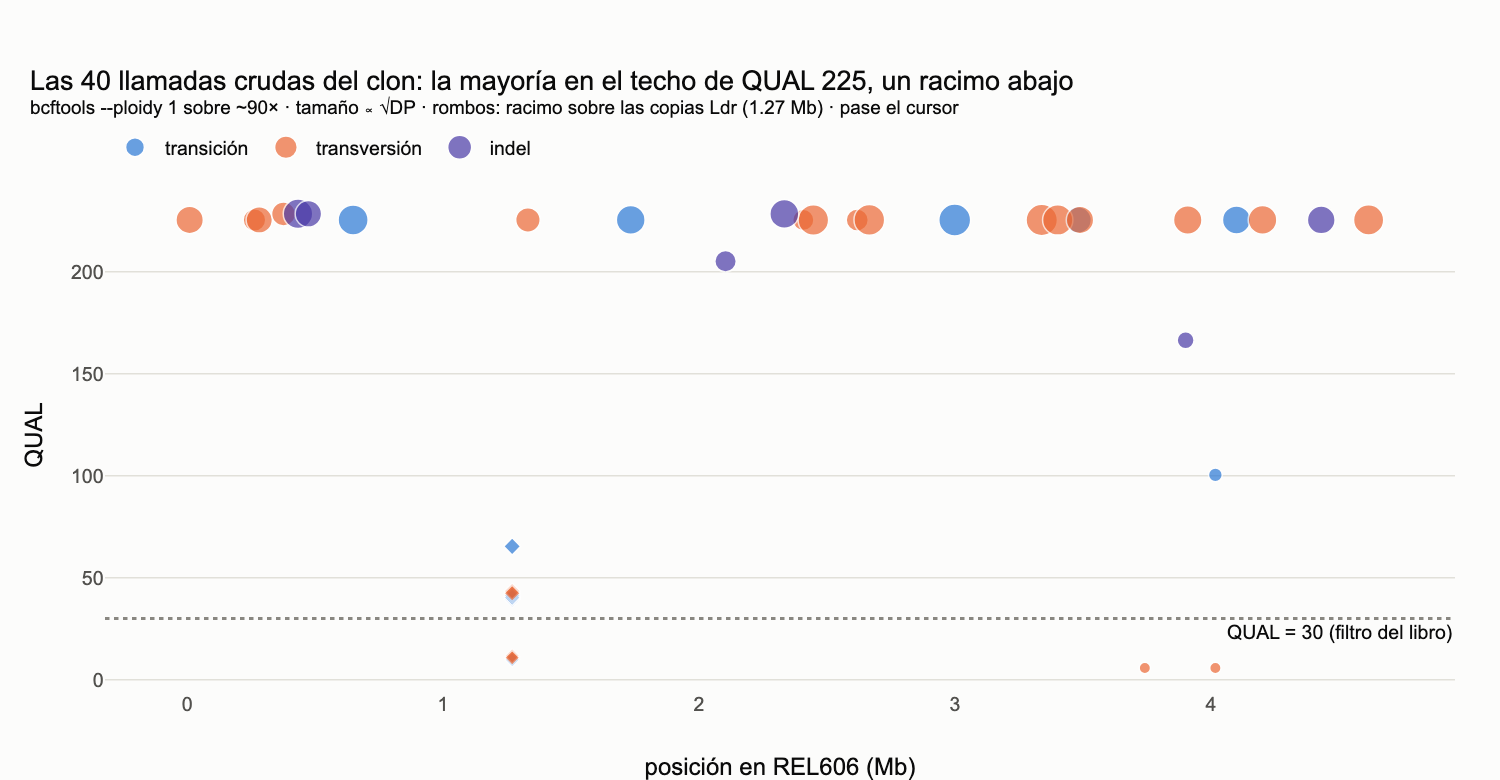

In [4]:
def snv_class(ref, alt):
    """Transición (purina↔purina o pirimidina↔pirimidina), transversión o indel."""
    if len(ref) != 1 or len(alt) != 1:
        return "indel"
    pur = set("AG")
    return "transición" if (ref in pur) == (alt in pur) else "transversión"

calls100["tipo"] = [snv_class(a, b) for a, b in zip(calls100.ref, calls100.alt)]
calls100["ldr"] = calls100.pos.between(1_270_100, 1_270_600)
def verdict(r):
    if r.ldr:
        return "racimo sobre las copias Ldr: DP bajísimo, todas las lecturas ALT en una hebra"
    if r.dp < 10:
        return "profundidad muy baja: evidencia escasa"
    if r.qual < 100:
        return "QUAL moderado: revisar"
    return "llamada segura"
calls100["diagnóstico"] = calls100.apply(verdict, axis=1)

colors = {"transición": ec.BLUE, "transversión": ec.ORANGE, "indel": ec.VIOLET}
fig = go.Figure()
for t, c in colors.items():
    d = calls100[calls100.tipo == t]
    fig.add_trace(go.Scatter(
        x=d.pos / 1e6, y=d.qual, mode="markers", name=t,
        marker=dict(size=6 + 1.6 * np.sqrt(d.dp), color=c, line=dict(width=1, color="white"),
                    symbol=np.where(d.ldr, "diamond", "circle")),
        customdata=np.stack([d.pos, d.ref.str[:12], d.alt.str[:12], d.dp, d.mq,
                             d.dp4.astype(str), d.pl.astype(str), d["diagnóstico"]], axis=1),
        hovertemplate=("<b>POS %{customdata[0]:,}</b>  %{customdata[1]} → %{customdata[2]}<br>"
                       "QUAL %{y:.1f} · DP %{customdata[3]} · MQ %{customdata[4]}<br>"
                       "DP4 (ref+, ref−, alt+, alt−) = %{customdata[5]}<br>PL (R, A) = %{customdata[6]}<br>"
                       "<i>%{customdata[7]}</i><extra></extra>")))
fig.add_hline(y=30, line_dash="dot", line_color=ec.MUTED,
              annotation_text="QUAL = 30 (filtro del libro)", annotation_position="bottom right")
fig.update_layout(
    title=dict(text="Las 40 llamadas crudas del clon: la mayoría en el techo de QUAL 225, un racimo abajo"
                    "<br><sup>bcftools --ploidy 1 sobre ~90× · tamaño ∝ √DP · rombos: racimo sobre las copias Ldr "
                    "(1.27 Mb) · pase el cursor</sup>"),
    xaxis=dict(title="posición en REL606 (Mb)"), yaxis=dict(title="QUAL", range=[-5, 245]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=520, margin=dict(t=120, l=70, r=30, b=60))
fig.show()

> 🔎 **Qué observamos.** Dos poblaciones muy distintas. Arriba, **25** llamadas con QUAL entre 205 y 228 (casi todas
> exactamente 225.417), profundidades de 26 a 91 lecturas y casi todas las bases de alta calidad a favor del alelo
> alternativo: mutaciones fijadas en el clon, como se espera en un organismo haploide clonal. Abajo, **14** llamadas con
> QUAL ≤ 101 y sólo 1 a 4 lecturas; 11 de ellas forman el **racimo Ldr** alrededor de la posición 1 270 000: 11
> registros (8 SNV en ~100 pb con DP 2–3 + 3 de una sola lectura en el mismo hueco). En medio queda una inserción
> dudosa (3 901 455, QUAL 166, DP 11, todas las lecturas en la misma hebra) que no daremos por confirmada. Esas
> diferencias las explotaremos al filtrar (sección 6) y al evaluar (sección 8).

> ✅ **Compruebe su comprensión.** (a) Un registro tiene `REF=A`, `ALT=C,T` y es diploide: ¿cuántos PL trae? (b) Si
> fuera haploide, ¿cuántos? (c) En BED, ¿cómo se escribe el intervalo de una SNV en `POS=9972`? *(a) $\binom{4}{2}=6$;
> (b) 3; (c) `NC_012967.1  9971  9972`.)*

## 3. El flujo de trabajo con `bcftools`, en vivo

`bcftools` es el compañero de SAMtools para manipular VCF/BCF y llamar variantes; Danecek *et al.* (2021) resumen
doce años de su desarrollo. El flujo mínimo del libro para una o varias muestras tiene cinco pasos:

```bash
REF=GRCh38.fa
# 1-2. Columnas + verosimilitudes, y llamado multialelico
bcftools mpileup -Ob -o pl.bcf -f $REF -q 20 -Q 20 \
    -a FORMAT/AD,FORMAT/DP muestra.bam
bcftools call -mv -Ob -o crudo.bcf pl.bcf
# 3. Normalizacion: alinear a la izquierda y separar multialelicos
bcftools norm -f $REF -m -any -Ob -o norm.bcf crudo.bcf
# 4. Filtro "suave": marca en FILTER en lugar de borrar
bcftools filter -s BajaCal -e 'QUAL<30 || INFO/DP<10' \
    -Oz -o final.vcf.gz norm.bcf
bcftools index -t final.vcf.gz
# 5. Estadisticas (incluye ti/tv) de los sitios que pasan
bcftools stats -f PASS final.vcf.gz > final.stats
grep ^TSTV final.stats
```

Vamos a ejecutarlo **tal cual**, con dos cambios: la referencia es REL606 en lugar de GRCh38, y a `call` le diremos
`--ploidy 1` porque *E. coli* es haploide (también correremos la versión diploide del libro para comparar). La entrada
son **17 910 pares de lecturas reales** del clon: todas las que caen a ±600 pb de cada una de las 40 llamadas de la
figura anterior. Así el ejercicio tarda segundos, pero las lecturas, la referencia (el genoma **completo** de REL606) y
los comandos son los de un análisis real.

La figura resume el recorrido y lo que entrega cada estación.

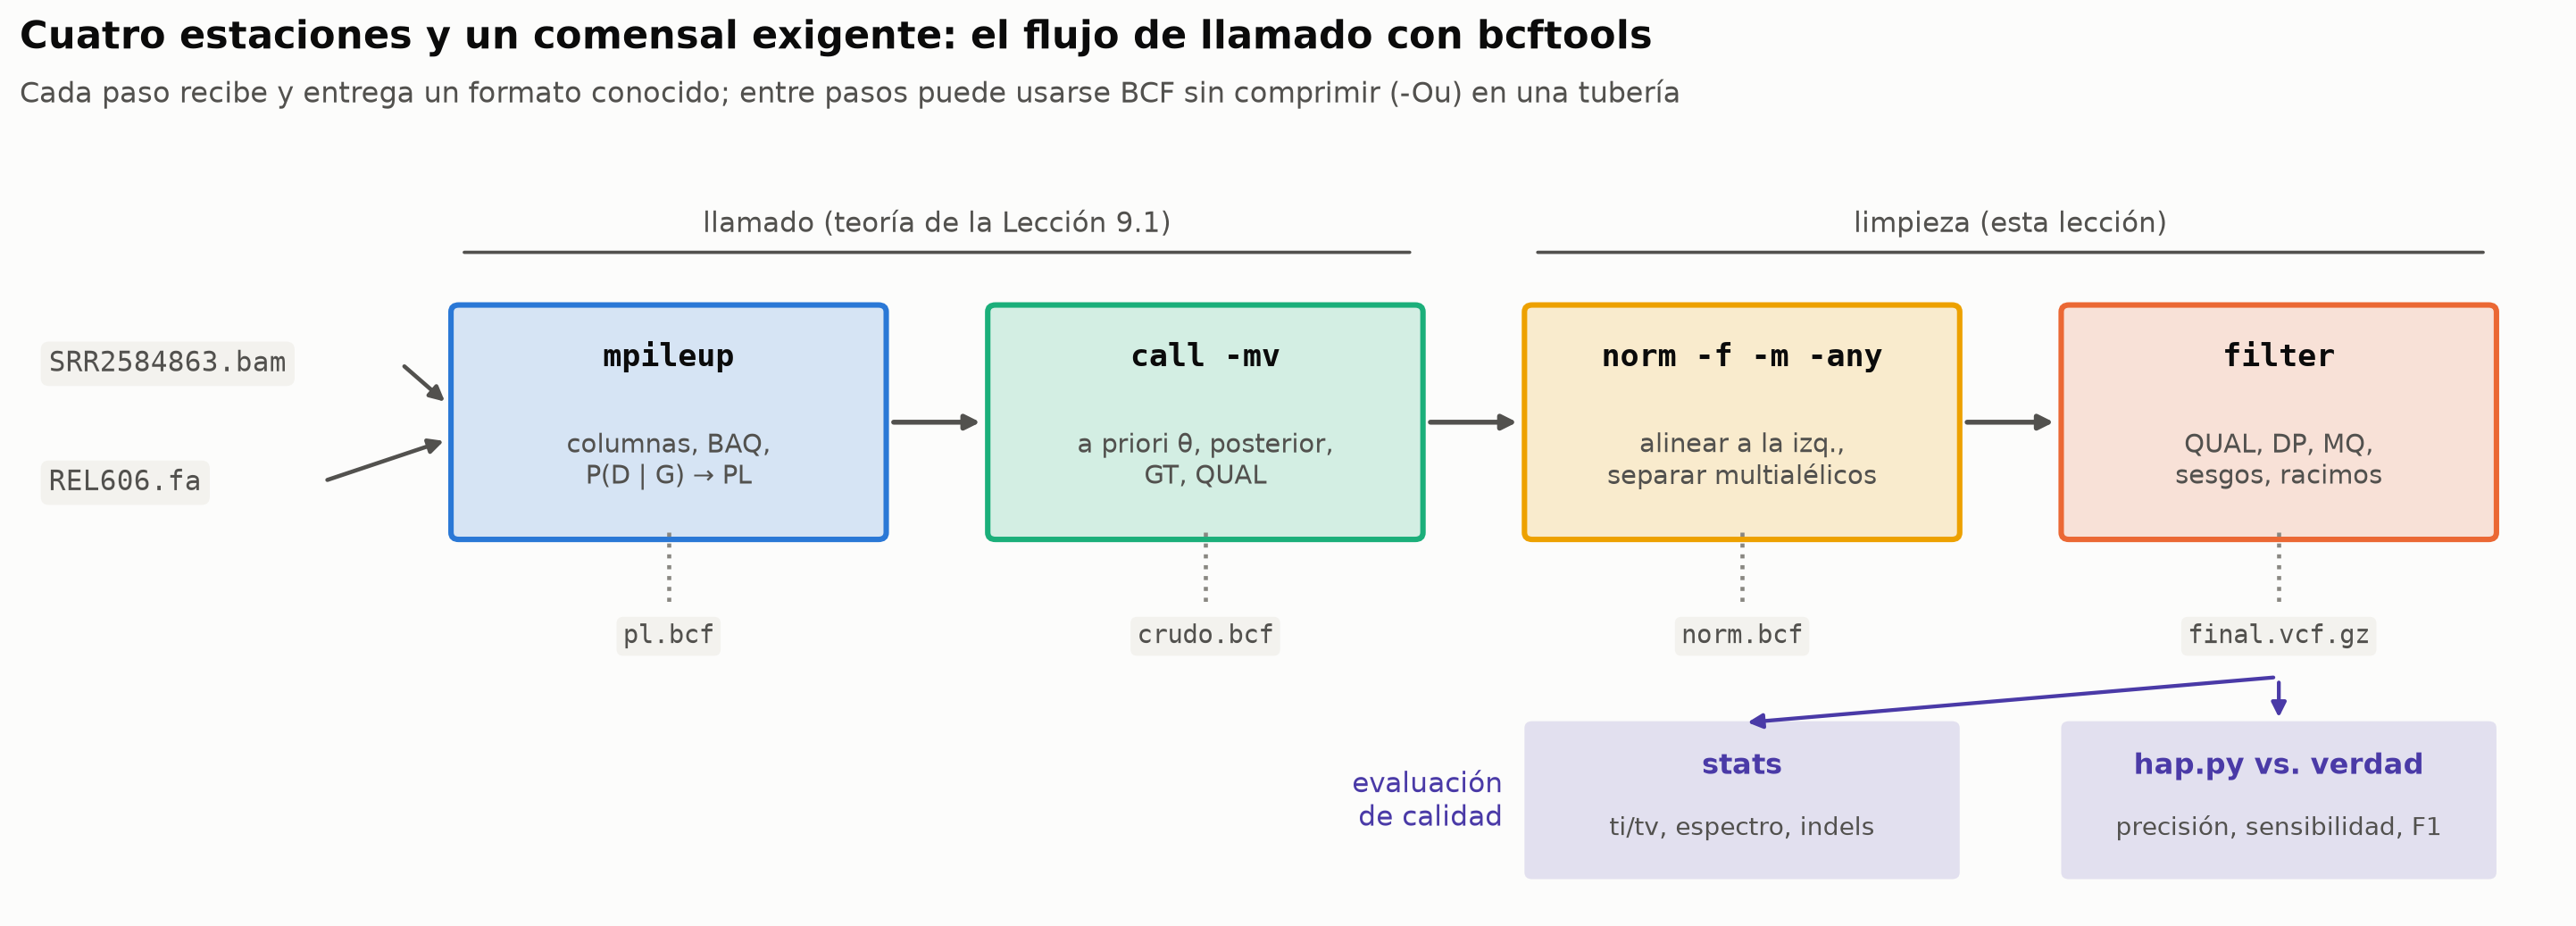

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.6); ax.axis("off")
steps = [("mpileup", "columnas, BAQ,\nP(D | G) → PL", "pl.bcf", ec.BLUE),
         ("call -mv", "a priori θ, posterior,\nGT, QUAL", "crudo.bcf", ec.AQUA),
         ("norm -f -m -any", "alinear a la izq.,\nseparar multialélicos", "norm.bcf", ec.YELLOW),
         ("filter", "QUAL, DP, MQ,\nsesgos, racimos", "final.vcf.gz", ec.ORANGE)]
ax.text(0.15, 3.15, "SRR2584863.bam", fontsize=10, family="monospace", color=ec.INK_2,
        bbox=dict(boxstyle="round,pad=0.3", fc="#f3f2ee", ec=ec.BASELINE))
ax.text(0.15, 2.45, "REL606.fa", fontsize=10, family="monospace", color=ec.INK_2,
        bbox=dict(boxstyle="round,pad=0.3", fc="#f3f2ee", ec=ec.BASELINE))
x0 = 2.25
for i, (name, what, out, col) in enumerate(steps):
    x = x0 + i * 2.75
    ax.add_patch(FancyBboxPatch((x, 2.2), 2.15, 1.3, boxstyle="round,pad=0.04", fc=col, ec="none", alpha=0.18))
    ax.add_patch(FancyBboxPatch((x, 2.2), 2.15, 1.3, boxstyle="round,pad=0.04", fc="none", ec=col, lw=2))
    ax.text(x + 1.075, 3.18, name, ha="center", fontsize=11.5, fontweight="bold", family="monospace", color=ec.INK)
    ax.text(x + 1.075, 2.62, what, ha="center", va="center", fontsize=9.5, color=ec.INK_2)
    ax.text(x + 1.075, 1.55, out, ha="center", fontsize=9.5, family="monospace", color=ec.INK_2,
            bbox=dict(boxstyle="round,pad=0.25", fc="#f3f2ee", ec=ec.BASELINE))
    ax.plot([x + 1.075, x + 1.075], [2.2, 1.78], ls=":", color=ec.MUTED, lw=1.5)
    if i < 3:
        ax.annotate("", (x + 2.7, 2.85), (x + 2.2, 2.85), arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.8))
ax.annotate("", (x0 - 0.05, 2.95), (1.95, 3.2), arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.5))
ax.annotate("", (x0 - 0.05, 2.75), (1.55, 2.5), arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.5))
for x, lab in [(x0 + 3.5, "llamado (Lección 9.1)"), (x0 + 3.5 + 5.5, "limpieza (esta lección)")]:
    pass
ax.annotate("", (x0, 3.85), (x0 + 4.9, 3.85), arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=1.2))
ax.text(x0 + 2.45, 3.97, "llamado (teoría de la Lección 9.1)", ha="center", fontsize=10, color=ec.INK_2)
ax.annotate("", (x0 + 5.5, 3.85), (x0 + 10.4, 3.85), arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=1.2))
ax.text(x0 + 7.95, 3.97, "limpieza (esta lección)", ha="center", fontsize=10, color=ec.INK_2)
for x, name, what in [(x0 + 5.5, "stats", "ti/tv, espectro, indels"),
                      (x0 + 8.25, "hap.py vs. verdad", "precisión, sensibilidad, F1")]:
    ax.add_patch(FancyBboxPatch((x, 0.2), 2.15, 0.85, boxstyle="round,pad=0.04", fc=ec.VIOLET, ec="none", alpha=0.14))
    ax.text(x + 1.075, 0.78, name, ha="center", fontsize=10.5, fontweight="bold", color=ec.VIOLET)
    ax.text(x + 1.075, 0.42, what, ha="center", fontsize=9.3, color=ec.INK_2)
    ax.annotate("", (x + 1.075, 1.08), (x0 + 3 * 2.75 + 1.075, 1.35),
                arrowprops=dict(arrowstyle="-|>", color=ec.VIOLET, lw=1.4))
ax.text(x0 + 5.35, 0.62, "evaluación\nde calidad", ha="right", va="center", fontsize=10, color=ec.VIOLET)
ec.title(ax, "Cuatro estaciones y un comensal exigente: el flujo de llamado con bcftools",
         "Cada paso recibe y entrega un formato conocido; entre pasos puede usarse BCF sin comprimir (-Ou) en una tubería")
plt.show()

### Instalar las herramientas

La celda siguiente instala `bwa`, `samtools` y `bcftools` con `apt-get` **sólo en Colab** (el Ubuntu de Colab trae
`bcftools` 1.13 o posterior, suficiente para todo lo que sigue). Fuera de Colab usa las que encuentre en el `PATH` (por
ejemplo, `conda install -c bioconda bwa samtools bcftools`). Si no hay herramientas, el notebook carga los resultados
precalculados que acompañan al curso, producidos con **los mismos comandos** (bcftools 1.24), y sigue con pysam.

Una regla de oro del laboratorio: **anote las versiones**. Los valores por omisión de `bcftools` (el modo de BAQ, por
ejemplo) han cambiado entre versiones, y un resultado sin versión no es reproducible.

In [6]:
def which_tools():
    return {t: shutil.which(t) for t in ("bwa", "samtools", "bcftools")}

tools = which_tools()
if IN_COLAB and not all(tools.values()):
    !apt-get -qq update > /dev/null
    !apt-get -qq install -y bwa samtools bcftools > /dev/null
    tools = which_tools()

def tool_version(cmd):
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    txt = (p.stdout + p.stderr).strip().splitlines()
    return next((l for l in txt if re.search(r"\d+\.\d+", l)), "?")

HAS_TOOLS = all(tools.values())
versions = {}
if HAS_TOOLS:
    versions = {"bwa": tool_version("bwa 2>&1 | grep -i version"),
                "samtools": tool_version("samtools --version | head -1"),
                "bcftools": tool_version("bcftools --version | head -1")}
    bcf_v = tuple(int(x) for x in re.search(r"(\d+)\.(\d+)", versions["bcftools"]).groups())
    if bcf_v < (1, 13):
        print(f"⚠️ bcftools {bcf_v} es antiguo: usaré los resultados precalculados")
        HAS_TOOLS = False
for t, v in versions.items():
    print(f"{t:9s}: {v}   ({tools[t]})")
if not HAS_TOOLS:
    print("⚠️ Sin bwa/samtools/bcftools: cargaré los resultados precalculados del curso (mismos comandos, bcftools 1.24).")

def sh(cmd, quiet=False):
    """Ejecuta una orden de la terminal, la muestra, y devuelve (stdout, stderr, segundos)."""
    if not quiet:
        print("$", cmd)
    t0 = time.time()
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if p.returncode != 0:
        raise RuntimeError(p.stderr[-800:])
    return p.stdout, p.stderr, time.time() - t0

EXPORT = os.environ.get("COURSE_EXPORT_CACHE")      # sólo para quien mantiene el curso: guarda los respaldos

bwa      : Version: 0.7.19-r1273   (bwa)
samtools : samtools 1.24   (samtools)
bcftools : bcftools 1.24   (bcftools)


In [7]:
# La referencia completa de REL606 (4.6 Mb) y las lecturas de las ventanas alrededor de las 40 llamadas
with gzip.open(course_file("NC_012967.1.fasta.gz"), "rt") as fh, open("REL606.fa", "w") as out:
    out.write(fh.read())
genome = "".join(l.strip() for l in open("REL606.fa") if not l.startswith(">"))
FQ1, FQ2 = course_file("SRR2584863_variant_windows_1.fastq.gz"), course_file("SRR2584863_variant_windows_2.fastq.gz")
BAM = "SRR2584863.bam"
timing = {}
print(f"REL606: {len(genome):,} pb · lecturas: {FQ1}, {FQ2}")
if HAS_TOOLS:
    rg = r"'@RG\tID:SRR2584863\tSM:REL7179B\tPL:ILLUMINA'"
    *_, timing["bwa index"] = sh("bwa index REL606.fa")
    *_, timing["samtools faidx"] = sh("samtools faidx REL606.fa")
    *_, timing["bwa mem | sort"] = sh(f"bwa mem -t 2 -R {rg} REL606.fa {FQ1} {FQ2} 2> bwa.log | "
                                      f"samtools sort -o {BAM} -")
    *_, timing["samtools index"] = sh(f"samtools index {BAM}")
    n_mapped = int(sh(f"samtools view -c -F 0x904 {BAM}", quiet=True)[0])
    print(f"\n{n_mapped:,} lecturas primarias mapeadas · tiempos (s):", {k: round(v, 1) for k, v in timing.items()})

REL606: 4,629,812 pb · lecturas: ../data/SRR2584863_variant_windows_1.fastq.gz, ../data/SRR2584863_variant_windows_2.fastq.gz
$ bwa index REL606.fa


$ samtools faidx REL606.fa
$ bwa mem -t 2 -R '@RG\tID:SRR2584863\tSM:REL7179B\tPL:ILLUMINA' REL606.fa ../data/SRR2584863_variant_windows_1.fastq.gz ../data/SRR2584863_variant_windows_2.fastq.gz 2> bwa.log | samtools sort -o SRR2584863.bam -


$ samtools index SRR2584863.bam

35,639 lecturas primarias mapeadas · tiempos (s): {'bwa index': 0.9, 'samtools faidx': 0.0, 'bwa mem | sort': 2.1, 'samtools index': 0.0}


Ahora las cuatro estaciones. Ejecutamos cada orden por separado para ver qué escribe en la terminal. Además del flujo
haploide (el correcto para *E. coli*) corremos una vez el `call -mv` del libro **tal cual**, que supone un organismo
diploide, para ver en qué se diferencian.

In [8]:
CACHE = {"raw": "92_windows_raw.vcf.gz", "final": "92_windows_final.vcf.gz", "diploid": "92_windows_diploid.vcf.gz",
         "log": "92_pipeline_log.json"}
if HAS_TOOLS:
    log = {"versions": versions, "stderr": {}, "seconds": dict(timing)}
    steps = [
        ("mpileup", f"bcftools mpileup -Ob -o pl.bcf -f REL606.fa -q 20 -Q 20 -a FORMAT/AD,FORMAT/DP {BAM}"),
        ("call (diploide, como en el libro)", "bcftools call -mv -Ob -o crudo_diploide.bcf pl.bcf"),
        ("call --ploidy 1", "bcftools call --ploidy 1 -mv -Ob -o crudo.bcf pl.bcf"),
        ("norm", "bcftools norm -f REL606.fa -m -any -Ob -o norm.bcf crudo.bcf"),
        ("filter", "bcftools filter -s BajaCal -e 'QUAL<30 || INFO/DP<10' -Oz -o final.vcf.gz norm.bcf"),
        ("index", "bcftools index -t final.vcf.gz"),
        ("stats", "bcftools stats -f PASS final.vcf.gz > final.stats"),
    ]
    for name, cmd in steps:
        out, err, secs = sh(cmd)
        log["stderr"][name] = err.strip()
        log["seconds"][name] = secs
        for l in err.strip().splitlines():
            print("   │", l)
    log["TSTV"] = [l for l in open("final.stats") if l.startswith("TSTV")]
    log["norm_line"] = next((l for l in log["stderr"]["norm"].splitlines() if l.startswith("Lines")), "")
    sh("bcftools view -Oz -o 92_windows_raw.vcf.gz crudo.bcf", quiet=True)
    sh("bcftools view -Oz -o 92_windows_diploid.vcf.gz crudo_diploide.bcf", quiet=True)
    shutil.copy("final.vcf.gz", "92_windows_final.vcf.gz")
    json.dump(log, open("92_pipeline_log.json", "w"), indent=1)
    if EXPORT:
        for f in CACHE.values():
            shutil.copy(f, os.path.join(EXPORT, f))
    FILES = CACHE
else:
    FILES = {k: course_file(v) for k, v in CACHE.items()}
    log = json.load(open(FILES["log"]))
    print("Resultados precalculados con", log["versions"])
    for name, err in log["stderr"].items():
        print(f"$ bcftools {name} …")
        for l in err.splitlines():
            print("   │", l)
print("\n$ grep ^TSTV final.stats")
print("".join(log["TSTV"]).strip())

$ bcftools mpileup -Ob -o pl.bcf -f REL606.fa -q 20 -Q 20 -a FORMAT/AD,FORMAT/DP SRR2584863.bam


   │ [mpileup] 1 samples in 1 input files
   │ [mpileup] maximum number of reads per input file set to -d 250
$ bcftools call -mv -Ob -o crudo_diploide.bcf pl.bcf
   │ Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
$ bcftools call --ploidy 1 -mv -Ob -o crudo.bcf pl.bcf
$ bcftools norm -f REL606.fa -m -any -Ob -o norm.bcf crudo.bcf
   │ [W::bcf_hdr_check_sanity] MQ should be declared as Type=Float
   │ Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	38/0/0/4/0/0/0
$ bcftools filter -s BajaCal -e 'QUAL<30 || INFO/DP<10' -Oz -o final.vcf.gz norm.bcf
   │ [W::bcf_hdr_check_sanity] MQ should be declared as Type=Float
$ bcftools index -t final.vcf.gz
$ bcftools stats -f PASS final.vcf.gz > final.stats
   │ [W::bcf_hdr_check_sanity] MQ should be declared as Type=Float



$ grep ^TSTV final.stats
TSTV	0	5	15	0.33	5	15	0.33


Detengámonos en lo que escribió cada orden y en las opciones, porque **cada una traduce un supuesto del modelo**:

| Opción | Qué hace | Por qué |
|---|---|---|
| `mpileup -f REL606.fa` | carga la referencia | sin ella no se sabe qué base es "referencia" |
| `-q 20` | descarta lecturas con MAPQ < 20 | una lectura que quizá pertenece a otra copia del genoma no debe testificar |
| `-Q 20` | ignora bases con calidad < 20 | los testigos poco fiables no entran en $P(D\mid G)$ |
| `-a FORMAT/AD,FORMAT/DP` | añade lecturas por alelo y profundidad por muestra | imprescindibles para filtrar y para detectar desequilibrios alélicos |
| (BAQ, por omisión) | recalibra la calidad de cada base según la incertidumbre del alineamiento (Lección 9.1); `-B` lo desactiva | evita falsas SNV junto a *indels* |
| `call -m` | llamador **multialélico**: evalúa todos los alelos observados en la columna | el modelo de Li (2011) de la Lección 9.1 |
| `call -v` | escribe sólo sitios variables | un genoma tiene millones de sitios sin variación |
| `call -P 1.1e-3` (por omisión) | la distribución *a priori*: el papel de $\theta$ | subirla hace el llamador más sensible y menos específico |
| `call --ploidy 1` | genotipos haploides $\{R, A\}$ | *E. coli* tiene un solo cromosoma |
| `norm -f … -m -any` | alinea a la izquierda y separa multialélicos | sección 5 |
| `filter -s BajaCal -e '…'` | **marca** (no borra) en `FILTER` los registros que cumplen la expresión | sección 6: el filtro "suave" conserva la evidencia |

Con varias muestras basta dar varios BAM (o una lista con `-b`) a `mpileup`: `call` hará entonces la llamada conjunta
de la Lección 9.1.

**Los mensajes de la terminal, uno por uno:**

* `[mpileup] maximum number of reads per input file set to -d 250`: `mpileup` lee como máximo 250 lecturas por
  posición y archivo. Con ~90× no importa; en exomas de 500× sí (súbalo con `-d`).
* `[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float`: **es ruido cosmético, no un error**. `bcftools call`
  añade a la cabecera la línea `##INFO=<ID=MQ,Number=1,Type=Integer,…>` (puede verla en el VCF de la sección 2), y la
  comprobación de sanidad de htslib espera que el campo estándar `MQ` sea `Float`. Aparece en cada orden que lee la
  cabecera (`norm`, `filter`, `index`…) y no cambia ningún resultado. Si lo ve en Colab, siga adelante.
* `Lines total/split/joined/realigned/…`: el resumen de `norm`. **realigned** cuenta los registros que movió al
  normalizar (sección 5).

El modo de BAQ depende de la versión; consúltelo en la ayuda de **su** versión y anótelo en el cuaderno de laboratorio:

In [9]:
if HAS_TOOLS:
    help_txt = subprocess.run("bcftools mpileup", shell=True, capture_output=True, text=True, stdin=subprocess.DEVNULL).stderr
    for l in help_txt.splitlines():
        if re.search(r"BAQ|-B,|--no-BAQ|-P, --platforms|--config", l):
            print(l.rstrip())
else:
    print("(sin bcftools local) En bcftools 1.24, 'bcftools mpileup' sin argumentos muestra, entre otras, las opciones "
          "-B/--no-BAQ y -D/--full-BAQ ('Apply BAQ everywhere, not just in problematic regions'): por omisión, BAQ sólo "
          "en las regiones problemáticas.")

  -B, --no-BAQ            Disable BAQ (per-Base Alignment Quality)
  -D, --full-BAQ          Apply BAQ everywhere, not just in problematic regions
  -E, --redo-BAQ          Recalculate BAQ on the fly, ignore existing BQs
  -Q, --min-BQ INT        Skip bases with baseQ/BAQ smaller than INT [1]
      --max-BQ INT        Limit baseQ/BAQ to no more than INT [60]
  -X, --config STR        Specify platform profile (use "-X list" for details)
  -M, --max-read-len INT  Maximum length of read to pass to BAQ algorithm [500]
  -P, --platforms STR     Comma separated list of platforms for indels [all]


### Diploide frente a haploide: el mismo sitio, dos modelos

El libro escribe `call -mv`, que supone ploidía 2. Comparemos algunas llamadas de las dos corridas. Recuerde de la
Lección 9.1 que con ploidía $m$ hay $\binom{k+m-1}{m}$ genotipos: tres PL $(RR, RA, AA)$ en diploide, dos $(R, A)$ en
haploide.

In [10]:
def vcf_table(path):
    """Tabla con las columnas que nos interesan de un VCF/BCF (una fila por alelo alternativo)."""
    out = []
    for r in pysam.VariantFile(path):
        s = r.samples[0]
        for alt in r.alts:
            out.append(dict(pos=r.pos, ref=r.ref, alt=alt, qual=round(r.qual, 3), filter=",".join(r.filter.keys()) or ".",
                            dp=r.info.get("DP"), mq=r.info.get("MQ"), dp4=tuple(r.info.get("DP4", ())),
                            gt="/".join(map(str, s["GT"])), pl=tuple(s["PL"]), ad=tuple(s["AD"])))
    return pd.DataFrame(out)

dip, hap = vcf_table(FILES["diploid"]), vcf_table(FILES["raw"])
cmp = hap.merge(dip, on=["pos", "ref", "alt"], suffixes=("_haploide", "_diploide"))
show = cmp[cmp.pos.isin([9972, 648692, 2103887, 4017756, 3742142])]
print(show[["pos", "ref", "alt", "gt_haploide", "pl_haploide", "qual_haploide",
            "gt_diploide", "pl_diploide", "qual_diploide"]].to_string(index=False, max_colwidth=14))
print(f"\n{len(hap)} llamadas haploides · {len(dip)} diploides · en común: {len(cmp)}")

    pos            ref            alt gt_haploide pl_haploide  qual_haploide gt_diploide   pl_diploide  qual_diploide
   9972              T              G           1    (255, 0)        225.417         1/1 (255, 255, 0)        225.417
 648692              C              T           1    (255, 0)        225.417         1/1 (255, 255, 0)        225.417
2103887 ACAGCCAGCCA... ACAGCCAGCCA...           1   (255, 10)        218.058         0/1  (255, 0, 10)        221.931
3742142              A              C           1     (34, 0)          5.757         1/1    (34, 3, 0)          5.757
4017756              C              T           1    (177, 0)        147.416         1/1  (177, 18, 0)        147.416

38 llamadas haploides · 40 diploides · en común: 38


> 🔎 **Qué observamos.** Las llamadas seguras salen como `1` en haploide y `1/1` en diploide, con el **mismo QUAL**: la
> evidencia de que el sitio es variable no depende de cuántas copias suponga el modelo cuando todas las lecturas dicen
> lo mismo. Lo que cambia es el vector PL (dos números frente a tres) y, en sitios mixtos como la repetición de
> 2 103 887 (9 lecturas REF y 14 ALT en el VCF de todas las lecturas), la **interpretación**: en un diploide un sitio así sería un
> heterocigoto perfectamente razonable (`0/1`); en una bacteria clonal no existe "heterocigoto", y una mezcla de
> alelos señala un problema de alineamiento en la repetición o una población mezclada. El modelo tiene que ser el
> del organismo.

## 4. La línea de montaje lectura a lectura, y el techo de QUAL = 225.417

¿Qué hace `call` con cada lectura? Tomemos una mutación verdadera del clon, la transición `C→T` en la posición
648 692, y apilemos sus lecturas **reales** una por una (las leemos de la BAM de ventanas con pysam). Con el modelo
haploide de la Lección 9.1, cada base $b_i$ con calidad Phred $Q_i$ aporta

$$
P(b_i\mid a)=\begin{cases}1-\varepsilon_i & b_i=a\\[2pt] \varepsilon_i/3 & b_i\neq a\end{cases},
\qquad \varepsilon_i = 10^{-Q_i/10},
\qquad
\mathrm{PL}(R) = -10\log_{10}\frac{\prod_i P(b_i\mid R)}{\prod_i P(b_i\mid A)}
$$

y la posterior con la distribución *a priori* ($\theta$ para el alelo alternativo) da

$$
\mathrm{QUAL} = -10\log_{10} P(R\mid D) = -10\log_{10}\frac{10^{-\mathrm{PL}(R)/10}}{10^{-\mathrm{PL}(R)/10} + \theta}
\;\approx\; \mathrm{PL}(R) + 10\log_{10}\theta \quad (\text{si } \mathrm{PL}(R)\gg 30).
$$

| Símbolo | Significado |
|---|---|
| $b_i,\ Q_i,\ \varepsilon_i$ | base de la lectura $i$, su calidad Phred y su probabilidad de error |
| $R,\ A$ | genotipos haploides: alelo de referencia o alternativo |
| $\mathrm{PL}(R)$ | cuánto menos verosímil es $R$ que $A$, en escala Phred (el PL de $A$ es 0) |
| $\theta$ | probabilidad *a priori* de un alelo alternativo: `-P`, por omisión $1.1\times10^{-3}$ |
| QUAL | $-10\log_{10}$ de la probabilidad posterior de que el sitio **no** sea variable |

Con $\theta = 1.1\times 10^{-3}$, $10\log_{10}\theta = -29.59$: **QUAL es el PL de la referencia menos unos 29.6
puntos**, el precio que cobra la distribución *a priori* por aceptar que el sitio es variable.

Antes de ejecutar la animación, **prediga**: ¿cuántas lecturas hacen falta para que el QUAL deje de crecer?

In [11]:
course_file("SRR2584863_REL606_variant_windows.bam.bai")     # el índice (.bai) debe estar junto al BAM
win_bam = pysam.AlignmentFile(course_file("SRR2584863_REL606_variant_windows.bam"))
SITE, SREF, SALT = 648_692, "C", "T"
col_reads = []
for col in win_bam.pileup(CHROM, SITE - 1, SITE, truncate=True, min_base_quality=0, stepper="nofilter"):
    for pr in col.pileups:
        if pr.is_del or pr.is_refskip:
            continue
        a = pr.alignment
        if a.mapping_quality < 20 or a.query_qualities[pr.query_position] < 20:   # los mismos -q 20 -Q 20 de mpileup
            continue
        col_reads.append((a.query_sequence[pr.query_position], a.query_qualities[pr.query_position], a.is_reverse))
order = np.random.default_rng(648).permutation(len(col_reads))
col_reads = [col_reads[i] for i in order][:40]

def haploid_quals(reads, theta=THETA, cap=255):
    """PL(R) acumulado (sin tope y con el tope de 255 de mpileup) y QUAL con la a priori θ."""
    pl_raw, pl_cap, qual_raw, qual_cap = [], [], [], []
    s = 0.0
    for b, q, _ in reads:
        e = 10 ** (-q / 10)
        pR = 1 - e if b == SREF else e / 3
        pA = 1 - e if b == SALT else e / 3
        s += -10 * math.log10(pR / pA)
        for pl, store_pl, store_q in ((s, pl_raw, qual_raw), (min(round(s), cap), pl_cap, qual_cap)):
            store_pl.append(pl)
            store_q.append(10 * np.logaddexp(0, (pl / 10 + math.log10(theta)) * math.log(10)) / math.log(10))
    return np.array(pl_raw), np.array(pl_cap), np.array(qual_raw), np.array(qual_cap)

pl_raw, pl_cap, q_raw, q_cap = haploid_quals(col_reads)
n_sat = int(np.argmax(np.array(pl_cap) >= 255)) + 1
print(f"{len(col_reads)} lecturas en 648 692 (en orden aleatorio): {''.join(b for b, _, _ in col_reads)}")
print(f"Calidades: {[q for _, q, _ in col_reads][:12]} …")
print(f"PL(R) llega al tope de 255 con la lectura {n_sat}; QUAL queda en {q_cap[-1]:.3f} "
      f"(sin el tope sería {q_raw[-1]:,.0f})")

40 lecturas en 648 692 (en orden aleatorio): TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
Calidades: [37, 37, 34, 39, 30, 30, 39, 34, 37, 35, 36, 33] …
PL(R) llega al tope de 255 con la lectura 7; QUAL queda en 225.414 (sin el tope sería 1,619)


![La línea de montaje: cada lectura real de la posición 648 692 suma evidencia; el PL de la referencia choca contra el tope de 255 y el QUAL se congela en 225.4](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-09-variantes/9.2_linea_montaje.gif)

*La línea de montaje: cada lectura real de la posición 648 692 suma evidencia; el PL de la referencia choca contra el tope de 255 y el QUAL se congela en 225.4*

In [12]:
fig, (axp, axq) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1, 1.35]))
N = len(col_reads)
ncol = 8
def draw(k):
    axp.clear(); axq.clear()
    axp.set_xlim(-0.5, ncol - 0.5); axp.set_ylim(-1.2, N / ncol + 0.2); axp.axis("off")
    for i in range(k):
        b, q, rev = col_reads[i]
        x, y = i % ncol, N / ncol - 1 - i // ncol
        axp.add_patch(Rectangle((x - 0.42, y - 0.42), 0.84, 0.84, color=ec.NUC_COLORS[b], alpha=0.25 + 0.75 * min(q, 40) / 40))
        axp.text(x, y + 0.05, b, ha="center", va="center", fontsize=13, fontweight="bold", color="white")
        axp.text(x, y - 0.3, ("←" if rev else "→") + str(q), ha="center", va="center", fontsize=7, color="white")
    axp.set_title(f"Columna 648 692 (C→T): {k} lecturas", loc="left", fontsize=12)
    axp.text(-0.45, -0.95, "color = base · opacidad = calidad · flecha = hebra y Q", fontsize=9, color=ec.INK_2)
    n = np.arange(1, k + 1)
    axq.plot(n, q_raw[:k], color=ec.MUTED, ls="--", lw=1.8)
    axq.plot(n, q_cap[:k], color=ec.BLUE, lw=2.6)
    axq.axhline(255 + 10 * math.log10(THETA), color=ec.ORANGE, ls=":", lw=1.5)
    axq.text(1, 250, "techo: 255 + 10·log10(θ) ≈ 225.4", color=ec.ORANGE, fontsize=10)
    if k:
        axq.text(k + 0.4, q_cap[k - 1], f"QUAL {q_cap[k-1]:.1f}", va="center", fontsize=10, color=ec.BLUE)
        if q_raw[k - 1] > 300:
            axq.text(k + 0.4, q_raw[k - 1], f"sin tope: {q_raw[k-1]:,.0f}", va="center", fontsize=9.5, color=ec.MUTED)
    axq.set_yscale("log"); axq.set_xlim(0, N + 9); axq.set_ylim(8, 3000)
    axq.set_xlabel("lecturas apiladas"); axq.set_ylabel("QUAL (escala log)")
    ec.title(axq, "El QUAL crece ~40 por lectura… hasta el techo",
             "Modelo haploide (Lección 9.1), θ = 1.1×10⁻³ · azul: con el tope PL ≤ 255")
    return []
ec.animate(fig, draw, frames=range(1, N + 1), interval=220, name="9.2_linea_montaje")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Cada lectura `T` de calidad $Q$ añade $-10\log_{10}\frac{\varepsilon/3}{1-\varepsilon}\approx Q+4.8$
> puntos al $\mathrm{PL}(R)$ (unos 40 con $Q\approx35$): con Phred, la evidencia **se suma**. Tras unas siete lecturas el
> $\mathrm{PL}(R)$ supera 255 y `mpileup` lo **recorta** a 255; desde ahí, el QUAL no
> puede pasar de $255 + 10\log_{10}(1.1\times10^{-3}) \approx 225.4$ por muchas lecturas que se apilen. La línea gris
> discontinua es lo que diría el modelo sin tope: un QUAL de miles, igual de inútil en la práctica (nadie distingue una
> probabilidad de error de $10^{-100}$ de una de $10^{-22}$).

### Comprobarlo en el código y en los datos

No es una conjetura: en el código fuente de bcftools 1.24, `bam2bcf.c` calcula cada PL y lo recorta con
`if (y > 255) y = 255;`, y `mcall.c` suma a la verosimilitud de cada alelo alternativo el logaritmo de la *a priori*
(`lk_tot += call->theta`, con `theta` $=\ln(1.1\times10^{-3})$ para una muestra haploide) y calcula
`QUAL = -4.343·(ln L(ref) − ln Σ L)`. El factor $4.343 \approx 10/\ln 10$ está redondeado, y eso explica el último
decimal. Comprobémoslo con los números del VCF real:

In [13]:
snv = calls100[~calls100.indel].copy()
snv["PL_R"] = [p[0] for p in snv.pl]
snv["QUAL_predicho"] = [4.343 * math.log(1 + THETA * 10 ** (pl / 10)) for pl in snv.PL_R]   # -4.343·ln(L_R/(L_R+θL_A))
snv["diferencia"] = snv.qual - snv.QUAL_predicho
print("Techo: 4.343·ln(1 + θ·10^(255/10)) =", round(4.343 * math.log(1 + THETA * 10 ** 25.5), 3))
print(snv[["pos", "ref", "alt", "dp", "PL_R", "qual", "QUAL_predicho", "diferencia"]]
      .drop_duplicates("PL_R").sort_values("PL_R").to_string(index=False, float_format=lambda v: f"{v:.3f}"))
others = calls100[(calls100.qual > 226)]
print(f"\nLlamadas por encima del techo: {len(others)} (QUAL {others.qual.min():.1f}–{others.qual.max():.1f}): "
      f"{', '.join(f'{p:,}' for p in others.pos)}")

Techo: 4.343·ln(1 + θ·10^(255/10)) = 225.417
    pos ref alt  dp  PL_R    qual  QUAL_predicho  diferencia
3742142   A   C   1    34   5.757          5.756       0.001
1270567   T   C   1    39   9.885          9.885       0.000
1270295   A   T   1    40  10.792         10.792       0.000
1270257   T   G   1    41  11.717         11.717       0.000
1270133   T   C   2    69  39.415         39.415      -0.000
1270204   A   G   2    70  40.415         40.415      -0.000
1270235   G   A   2    71  41.415         41.415       0.000
1270157   T   A   2    72  42.415         42.415      -0.000
1270134   T   G   2    73  43.415         43.415       0.000
1270197   A   G   3    95  65.415         65.415       0.000
4017756   C   T   4   130 100.415        100.415      -0.000
   9972   T   G  59   255 225.417        225.417       0.000

Llamadas por encima del techo: 4 (QUAL 228.4–228.4): 377,000, 433,359, 473,901, 2,333,538


> 🔎 **Qué observamos.** Para todas las SNV la fórmula reproduce el QUAL del VCF hasta el tercer decimal: con
> $\mathrm{PL}(R)=69$ el QUAL es $39.41$, con 95 es $65.41$, y con el tope de 255 es **225.417**. El QUAL de una SNV
> haploide de una sola muestra es, literalmente, "PL de la referencia menos 29.6".
>
> Queda una **observación empírica** que no hemos derivado: cuatro llamadas (tres *indels* y la SNV de 377 000, que
> tiene una lectura con la referencia) aparecen en ~228.4, unos 3 puntos ($\approx 10\log_{10}2$) por encima del
> techo. Es compatible con que `call` sume dos configuraciones alternativas en vez de una (por ejemplo, cuando en la
> columna aparece el alelo "no observado" `<*>`), pero no lo hemos verificado en el código; no dependa de ello.
>
> **Consecuencia práctica:** por encima de ~225, el QUAL de `bcftools` **ya no ordena** las llamadas. Umbrales como
> "QUAL ≥ 300" no tienen sentido, y para priorizar entre llamadas seguras hay que mirar otras columnas (DP, AD, sesgos).

> ✅ **Compruebe su comprensión.** Si repitiera el llamado con `-P 1e-2`, ¿cuál sería el nuevo techo? ¿Y el QUAL de
> una SNV con $\mathrm{PL}(R)=69$? *(Techo: $255-20=235$; QUAL $\approx 69-20 = 49$: una a priori más alta hace al
> llamador más crédulo.)*

## 5. Normalización de *indels*

### El problema, con un ejemplo cotidiano

Si en la frase "ja ja ja ja" alguien borra un "ja", ¿cuál borró: el primero, el segundo, el tercero o el cuarto? La
pregunta no tiene respuesta: el resultado, "ja ja ja", es el mismo. Con el ADN pasa lo mismo. Considere la referencia
`GGATCACACACAGT`, que contiene el microsatélite `(CA)₄` en las posiciones 5–12, y un individuo que perdió una de las
cuatro unidades `CA`. Su haplotipo es `GGATCACACAGT`. ¿Dónde está la deleción? Borrar cualquiera de las cuatro unidades,
o incluso los pares `AC` desfasados, produce exactamente el mismo haplotipo. Pero en un VCF hay que escribir **una**
posición, y distintos llamadores (o el mismo con lecturas distintas) pueden elegir distintas. Dos archivos que
describen la misma variante parecerán discrepar, y la anotación, la comparación con bases de datos y la evaluación
frente a un conjunto de verdad se vendrán abajo.

Tan, Abecasis y Kang (2015) formalizaron el problema y su solución.

> **Definición (variante normalizada).** Una variante $(\mathrm{POS},\mathrm{REF},\mathrm{ALT})$ está *normalizada* si y
> sólo si es **parsimoniosa** (se representa con los alelos más cortos posibles, sin bases compartidas superfluas) y
> está **alineada a la izquierda** (su posición no puede desplazarse más a la izquierda sin cambiar el haplotipo).

El algoritmo es sorprendentemente simple:

1. Mientras los dos alelos terminen en la misma base, se elimina esa base final de ambos. Si alguno queda vacío, se
   antepone a ambos la base anterior de la referencia y se decrementa `POS`. Se repite hasta que ninguna de las dos
   condiciones se cumpla.
2. Mientras ambos alelos tengan longitud mayor que 1 y empiecen por la misma base, se elimina esa base inicial de ambos
   y se incrementa `POS`.

El paso 1 "empuja" la variante hacia la izquierda a través de la repetición; el paso 2 recorta el contexto sobrante,
dejando una sola base de anclaje.

### Ejemplo resuelto del libro: normalizar paso a paso

Tomemos el registro `POS=10, REF=ACA, ALT=A`. Paso 1: ambos alelos terminan en `A`; se elimina: `AC`/vacío. `ALT`
quedó vacío, así que se antepone la base 9 (`C`): `POS=9`, `CAC`/`C`. Terminan en `C`: `CA`/vacío; se antepone la base
8 (`A`): `POS=8`, `ACA`/`A`. El ciclo se repite desplazando la deleción de dos en dos bases hasta `POS=4`,
`TCA`/`T`: ahora terminan en `A` y `T`, distintas, y `T` no está vacío; el paso 1 se detiene. Paso 2: `T` tiene
longitud 1, así que no hay nada que recortar. Resultado: **`4 TCA T`**.

El código es el del libro, con un registro de cada paso para seguirlo:

In [14]:
def normalize(pos, ref, alt, genome, trace=False):
    """Tan et al. (2015). pos es 1-based; genome, la referencia completa (cadena)."""
    steps = [(pos, ref, alt, "inicio")]
    while True:
        changed = False
        if ref and alt and ref[-1] == alt[-1]:            # recorte a la derecha
            ref, alt = ref[:-1], alt[:-1]
            changed = True
            steps.append((pos, ref, alt, "recorta la última base común"))
        if not ref or not alt:                            # extender a la izquierda
            pos -= 1
            b = genome[pos - 1]
            ref, alt = b + ref, b + alt
            changed = True
            steps.append((pos, ref, alt, f"alelo vacío: antepone la base {pos} ({b})"))
        if not changed:
            break
    while len(ref) > 1 and len(alt) > 1 and ref[0] == alt[0]:
        ref, alt, pos = ref[1:], alt[1:], pos + 1          # recorte a la izquierda
        steps.append((pos, ref, alt, "recorta la primera base común"))
    if trace:
        for p, r, a, why in steps:
            print(f"   POS={p:<3d} REF={r or '∅':6s} ALT={a or '∅':6s} {why}")
    return pos, ref, alt

G_BOOK = "GGATCACACACAGT"
print("Registro 10 ACA A:")
print("→", normalize(10, "ACA", "A", G_BOOK, trace=True))

Registro 10 ACA A:
   POS=10  REF=ACA    ALT=A      inicio
   POS=10  REF=AC     ALT=∅      recorta la última base común
   POS=9   REF=CAC    ALT=C      alelo vacío: antepone la base 9 (C)
   POS=9   REF=CA     ALT=∅      recorta la última base común
   POS=8   REF=ACA    ALT=A      alelo vacío: antepone la base 8 (A)
   POS=8   REF=AC     ALT=∅      recorta la última base común
   POS=7   REF=CAC    ALT=C      alelo vacío: antepone la base 7 (C)
   POS=7   REF=CA     ALT=∅      recorta la última base común
   POS=6   REF=ACA    ALT=A      alelo vacío: antepone la base 6 (A)
   POS=6   REF=AC     ALT=∅      recorta la última base común
   POS=5   REF=CAC    ALT=C      alelo vacío: antepone la base 5 (C)
   POS=5   REF=CA     ALT=∅      recorta la última base común
   POS=4   REF=TCA    ALT=T      alelo vacío: antepone la base 4 (T)
→ (4, 'TCA', 'T')


 10 ACA    A    → haplotipo GGATCACACAGT → normalizado (4, 'TCA', 'T')
  9 CAC    C    → haplotipo GGATCACACAGT → normalizado (4, 'TCA', 'T')
  6 ACA    A    → haplotipo GGATCACACAGT → normalizado (4, 'TCA', 'T')
  8 ACACA  ACA  → haplotipo GGATCACACAGT → normalizado (4, 'TCA', 'T')
  4 TCACA  TCA  → haplotipo GGATCACACAGT → normalizado (4, 'TCA', 'T')
 11 CAG    G    → haplotipo GGATCACACAGT → normalizado (4, 'TCA', 'T')
✔ Las seis representaciones describen el mismo haplotipo y convergen al mismo registro: 4 TCA T


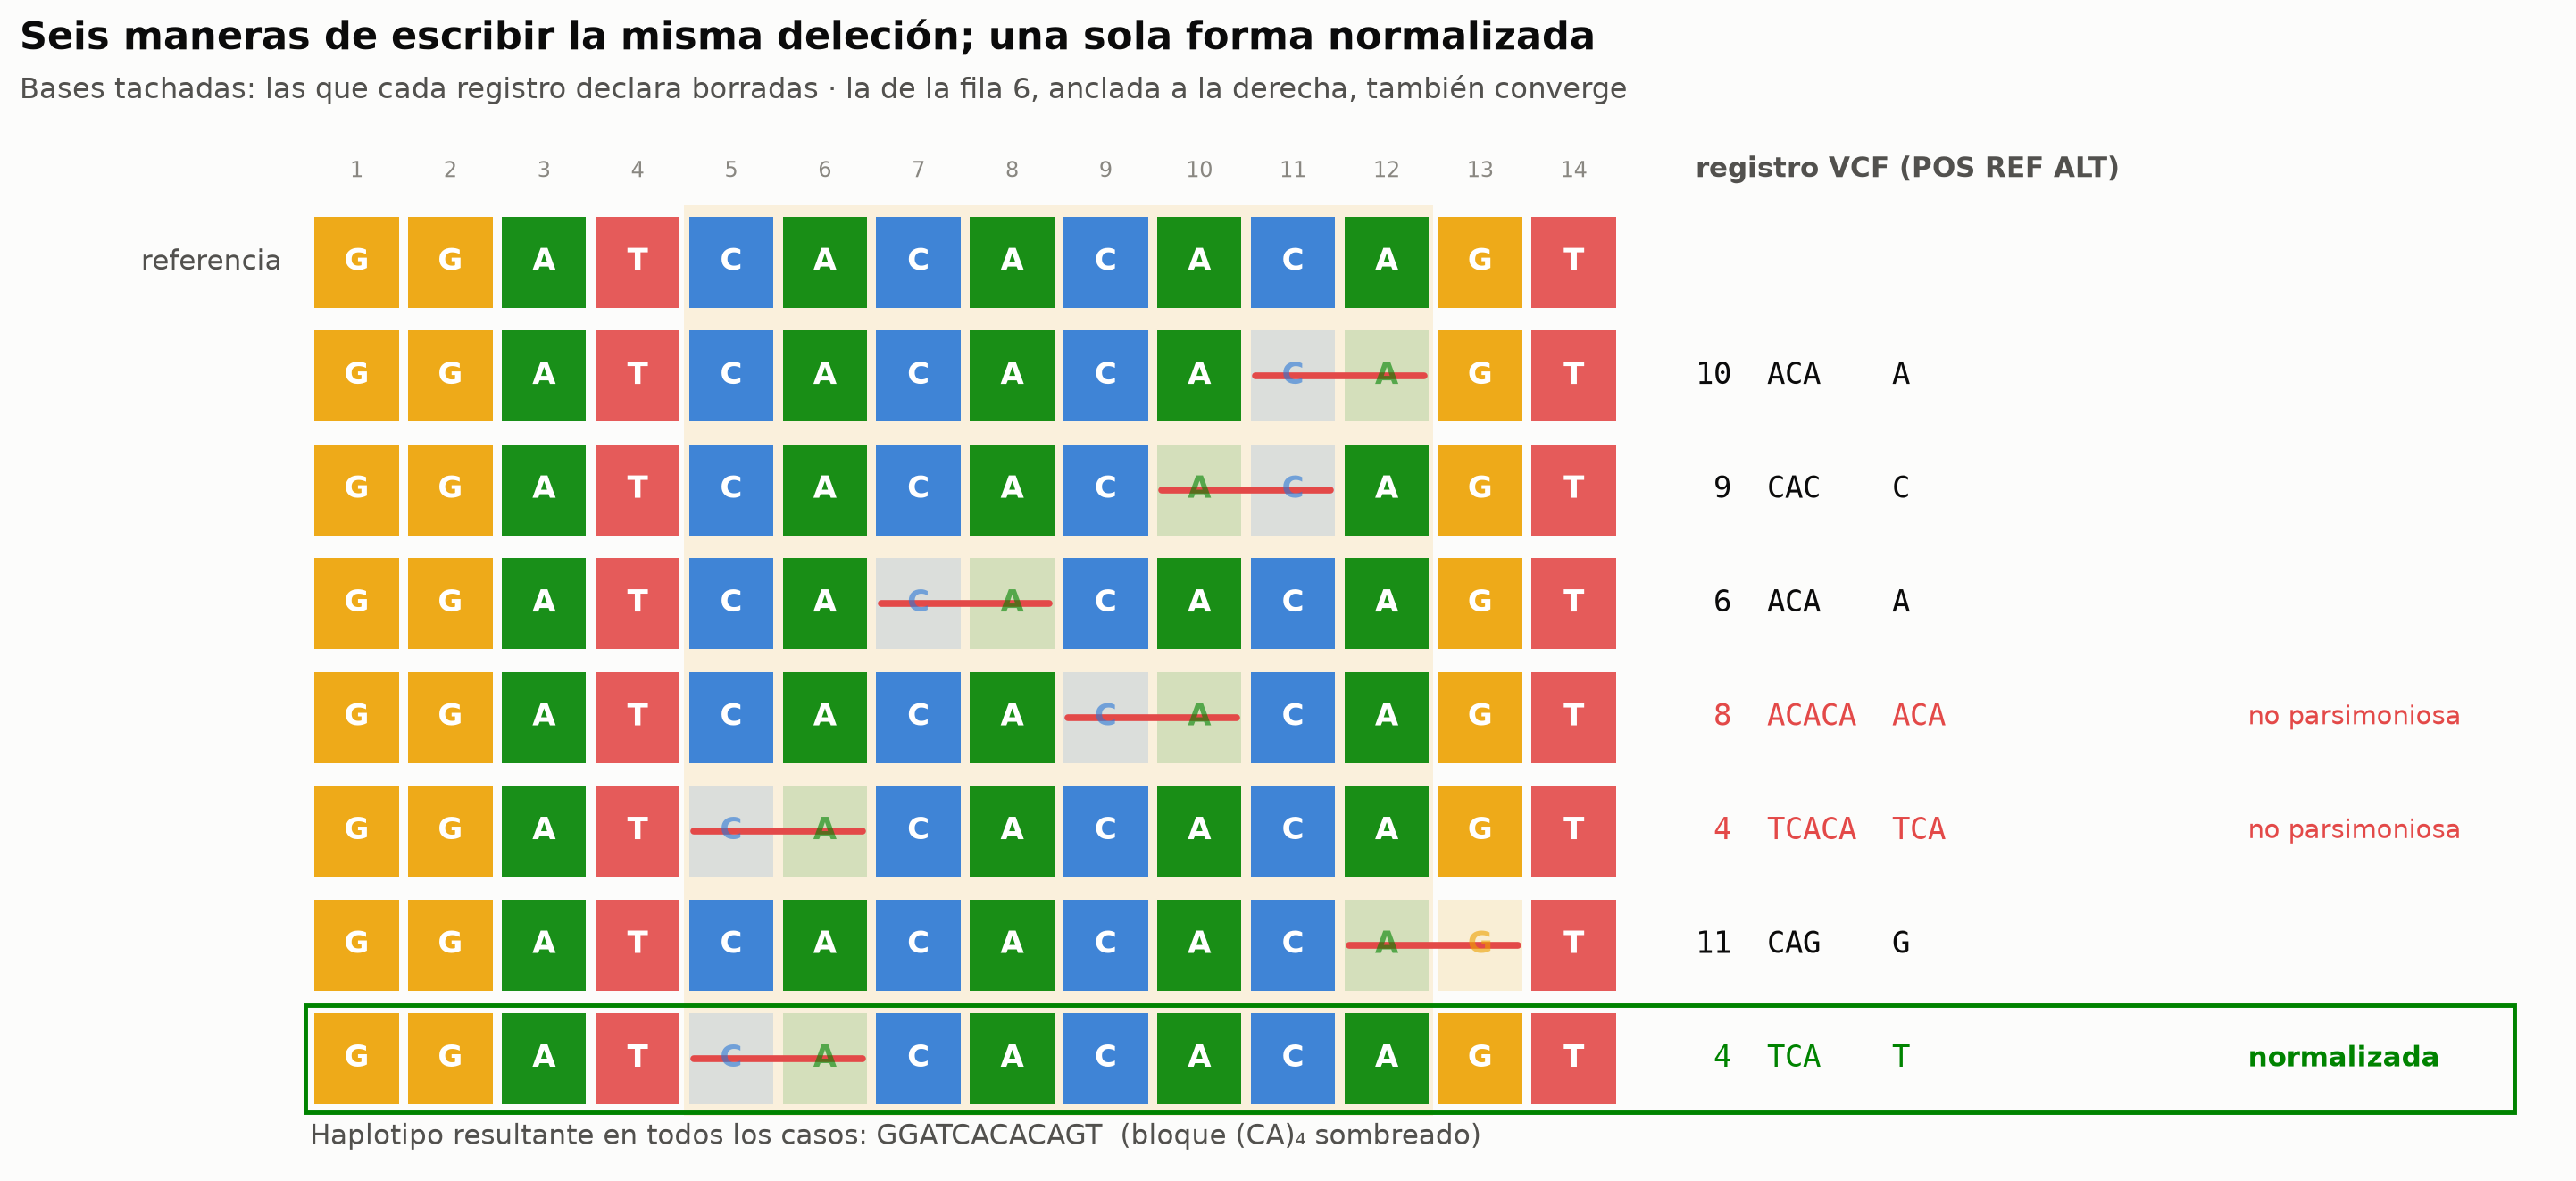

In [15]:
book_reps = [(10, "ACA", "A"), (9, "CAC", "C"), (6, "ACA", "A"), (8, "ACACA", "ACA"), (4, "TCACA", "TCA"), (11, "CAG", "G")]
hap_expected = "GGATCACACAGT"
res = []
for p, r, a in book_reps:
    assert G_BOOK[p - 1:p - 1 + len(r)] == r
    hap_seq = G_BOOK[:p - 1] + a + G_BOOK[p - 1 + len(r):]
    res.append((p, r, a, hap_seq, normalize(p, r, a, G_BOOK)))
    print(f"{p:>3d} {r:6s} {a:4s} → haplotipo {hap_seq} → normalizado {res[-1][-1]}")
assert all(h == hap_expected for *_, h, _ in res) and len({n for *_, n in res}) == 1
print("✔ Las seis representaciones describen el mismo haplotipo y convergen al mismo registro: 4 TCA T")

fig, ax = plt.subplots(figsize=(13, 5.9))
ax.set_xlim(-2.6, 24.5); ax.set_ylim(-7.9, 1.2); ax.axis("off")
ax.add_patch(Rectangle((4.5, -7.5), 8, 8.0, color=ec.YELLOW, alpha=0.12, lw=0))
def row(y, deleted=(), label=None, col=ec.INK):
    for i, b in enumerate(G_BOOK, start=1):
        dele = i in deleted
        ax.add_patch(Rectangle((i - 0.45, y - 0.4), 0.9, 0.8, color=ec.NUC_COLORS[b], alpha=0.15 if dele else 0.9, lw=0))
        ax.text(i, y, b, ha="center", va="center", fontsize=11, fontweight="bold",
                color=ec.NUC_COLORS[b] if dele else "white", alpha=0.6 if dele else 1)
    if deleted:
        ax.plot([min(deleted) - 0.4, max(deleted) + 0.4], [y, y], color=ec.RED, lw=2.5)
    if label:
        ax.text(15.3, y, label, va="center", fontsize=11, family="monospace", color=col)
for i in range(1, 15):
    ax.text(i, 0.75, str(i), ha="center", fontsize=8, color=ec.MUTED)
row(0)
ax.text(0.2, 0, "referencia", ha="right", va="center", fontsize=10, color=ec.INK_2)
ax.text(15.3, 0.75, "registro VCF (POS REF ALT)", fontsize=10, fontweight="bold", color=ec.INK_2)
spans = [(11, 12), (10, 11), (7, 8), (9, 10), (5, 6), (12, 13)]
# las seis del libro y, debajo, la forma normalizada a la que convergen todas
for k, ((p, r, a), sp) in enumerate(zip(book_reps + [(4, "TCA", "T")], spans + [(5, 6)]), start=1):
    good = k == 7
    nonpars = len(r) > 3 and len(a) > 1
    col = ec.GREEN if good else (ec.RED if nonpars else ec.INK)
    row(-k, deleted=range(sp[0], sp[1] + 1), label=f"{p:>2d}  {r:6s} {a}", col=col)
    if nonpars:
        ax.text(21.2, -k, "no parsimoniosa", va="center", fontsize=9.5, color=ec.RED)
    if good:
        ax.text(21.2, -k, "normalizada", va="center", fontsize=10, fontweight="bold", color=ec.GREEN)
        ax.add_patch(Rectangle((0.45, -k - 0.47), 23.6, 0.94, fill=False, ec=ec.GREEN, lw=1.6))
ax.text(0.5, -7.75, "Haplotipo resultante en todos los casos: GGATCACACAGT  (bloque (CA)₄ sombreado)",
        fontsize=10, color=ec.INK_2)
ec.title(ax, "Seis maneras de escribir la misma deleción; una sola forma normalizada",
         "Bases tachadas: las que cada registro declara borradas · la de la fila 6, anclada a la derecha, también converge")
plt.show()

> 🔎 **Qué observamos.** Cada fila borra dos bases distintas, pero todas dejan el mismo haplotipo. La cuarta y la
> quinta filas (`8 ACACA ACA` y `4 TCACA TCA`) además **no son parsimoniosas**: arrastran bases compartidas por `REF` y
> `ALT`. El algoritmo lleva las seis a la forma única de la fila verde, `4 TCA T`: la deleción más a la izquierda posible, con una sola base de anclaje. Tan *et al.*
> (2015) demuestran que el resultado es único; `bcftools norm` y `vt normalize` implementan este algoritmo.

### Las repeticiones reales del clon

El clon tiene dos *indels* en repeticiones que ilustran el problema a escala real: una **expansión** de la unidad
`CAGC` en 2 103 887 (dentro de una repetición en tándem de `CAGCC…`) y una base `T` de más en un **homopolímero** en
433 359. Observe cómo escribió `call` esos registros (antes de `norm`) y cómo quedaron después. Luego escribimos cada
*indel* **anclado a la derecha de su repetición**, como podría hacerlo otro llamador, y comprobamos que nuestra función
y `bcftools norm` lo devuelven a la misma forma.

In [16]:
raw_tab, fin_tab = vcf_table(FILES["raw"]), vcf_table(FILES["final"])
print("Salida de `call` (crudo) frente a la de `norm`:")
for p in (433_359, 473_901, 2_103_887, 2_333_538, 4_431_393):
    r0 = raw_tab[raw_tab.pos == p].iloc[0]
    r1 = fin_tab[fin_tab.pos == p].iloc[0]
    ours = normalize(p, r0.ref, r0.alt, genome)
    print(f"  crudo {p:>9,d} {r0.ref[:24]:25s}→ {r0.alt[:30]:31s}")
    print(f"  norm  {r1.pos:>9,d} {r1.ref[:24]:25s}→ {r1.alt[:30]:31s} · nuestra función: {ours[0]:,} {ours[1]}→{ours[2]}")
print("\nResumen de `norm`:", log.get("norm_line", ""))

def right_anchored(pos, ref, alt, genome):
    """Desplaza un indel normalizado hasta el extremo DERECHO de su repetición (otra representación válida)."""
    ins = len(alt) > len(ref)
    seq = alt[1:] if ins else ref[1:]                  # bases insertadas o borradas
    p = pos                                            # p: base de anclaje (1-based)
    # la variante "camina" una base a la derecha mientras la base siguiente sea igual a la primera de la unidad
    while (genome[p] if ins else genome[p + len(seq)]) == seq[0]:
        seq = seq[1:] + seq[0]
        p += 1
    a = genome[p - 1]
    return (p, a, a + seq) if ins else (p, a + seq, a)

print("\nRepresentación anclada a la derecha → normalizada:")
for p in (433_359, 2_103_887):
    r1 = fin_tab[fin_tab.pos == p].iloc[0]
    rp, rr, ra = right_anchored(r1.pos, r1.ref, r1.alt, genome)
    W = genome[r1.pos - 1:r1.pos + 199]                # ventana de 200 pb que empieza en el anclaje izquierdo
    hap_left = r1.alt + W[len(r1.ref):]
    hap_right = W[:rp - r1.pos] + ra + W[rp - r1.pos + len(rr):]
    back = normalize(rp, rr, ra, genome)
    print(f"  {rp:>9,d} {rr[:26]:27s}→ {ra[:30]:31s} (se desplazó {rp - r1.pos} pb) → {back[0]:,} {back[1]}→{back[2][:30]}"
          f" · mismo haplotipo: {hap_left == hap_right}")
ctx = genome[2_103_887 - 6:2_103_887 + 40]
print(f"\nContexto de 2 103 887: …{ctx[:6]}|{ctx[6:]}…  (la unidad CAGC se repite en tándem)")

Salida de `call` (crudo) frente a la de `norm`:
  crudo   433,359 CTTTTTTT                 → CTTTTTTTT                      
  norm    433,359 C                        → CT                              · nuestra función: 433,359 C→CT
  crudo   473,901 CCGC                     → CCGCGC                         
  norm    473,901 C                        → CCG                             · nuestra función: 473,901 C→CCG
  crudo 2,103,887 ACAGCCAGCCAGCCAGCCAGCCAG → ACAGCCAGCCAGCCAGCCAGCCAGCCAGCC 
  norm  2,103,887 A                        → ACAGCCAGCCAGCCAGCCAGCCAGC       · nuestra función: 2,103,887 A→ACAGCCAGCCAGCCAGCCAGCCAGC
  crudo 2,333,538 AT                       → ATT                            
  norm  2,333,538 A                        → AT                              · nuestra función: 2,333,538 A→AT
  crudo 4,431,393 TGG                      → T                              
  norm  4,431,393 TGG                      → T                               · nuestra función: 4,431,3

> 🔎 **Qué observamos.** `call` escribió los *indels* con mucho contexto (por ejemplo `CTTTTTTT → CTTTTTTTT`): son
> representaciones correctas pero **no parsimoniosas**. `norm` las recorta a su forma mínima (`C → CT`), y nuestra
> función de diez líneas coincide con `bcftools norm` en todos los casos. La misma inserción escrita en el extremo
> derecho de la repetición describe el mismo haplotipo y vuelve a la forma normalizada. Si un laboratorio compara su
> VCF con el de otro sin normalizar ambos, esta inserción aparecería como un falso positivo **y** un falso negativo a
> la vez.

La opción `-m -any` de `bcftools norm` hace una segunda normalización, igualmente importante: **separa los sitios
multialélicos** (`ALT=G,T`) en un registro por alelo alternativo, de modo que cada línea describa una sola variante.
Sin este paso, un sitio con `ALT=GA,G` (una inserción y una SNV en el mismo lugar) no puede alinearse a la izquierda
correctamente ni compararse con bases de datos que almacenan una variante por línea. Nuestro clon no tiene sitios
multialélicos (es haploide y clonal), pero en una cohorte humana son frecuentes.

> 📌 **Regla de laboratorio.** Normalice siempre, con **la misma versión de la referencia**, antes de intersectar dos
> VCF, anotar o evaluar frente a un conjunto de verdad: una fracción notable de las "discrepancias" entre llamadores en
> *indels* desaparece al hacerlo (Tan *et al.*, 2015).

## 6. Filtrado: el caso real del racimo Ldr

### ¿De dónde salen las llamadas falsas?

Un llamado crudo contiene inevitablemente falsos positivos, y sus causas típicas son conocidas: lecturas **mal
mapeadas** en regiones repetitivas o duplicaciones segmentarias ausentes de la referencia; errores de secuenciación
sistemáticos dependientes del contexto; errores de PCR; y regiones de baja complejidad donde los *indels* son
ambiguos. Heng Li (2014) los estudió con un diseño ingenioso: llamó variantes en un genoma humano **haploide** (una
línea celular de mola hidatiforme), donde todo heterocigoto es, por definición, un error. Encontró dos fuentes
principales: el realineamiento erróneo en regiones de baja complejidad y la **incompletitud de la referencia**
respecto de la muestra, cuyas secuencias ausentes se mapean sobre copias parecidas y producen falsos heterocigotos, a
menudo con profundidad excesiva. Estimó que los genotipos crudos tienen un error cada 10–15 kb, y que un filtrado
cuidadoso lo reduce a uno cada 100–200 kb sin pérdida apreciable de sensibilidad.

Nuestro clon es haploide, como la mola de Li: cualquier "heterocigoto" sería un error, y cualquier llamada con pocas
lecturas en medio de una región con ~90× es sospechosa.

Los filtros más comunes para llamados de `bcftools` son:

| Filtro | Columna | Qué detecta |
|---|---|---|
| **QUAL** mínimo (y **GQ** por muestra) | `QUAL`, `FORMAT/GQ` | poca evidencia de variación |
| **DP** mínimo y **máximo** | `INFO/DP` | poca evidencia / copias colapsadas de una repetición (profundidad excesiva) |
| **MQ** medio bajo | `INFO/MQ` | región de mapeo ambiguo |
| **Sesgo de hebra** | `DP4`, `MQSBZ` | todas las lecturas alternativas vienen de una sola hebra: sospeche de un artefacto |
| **Desequilibrio alélico** | `AD` | en un heterocigoto germinal, $\mathrm{AD}_\text{alt}/\mathrm{DP}\approx0.5$; un $0.1$ sugiere contaminación, error sistemático o mosaicismo (en un haploide clonal, se espera $\approx 1$) |
| **Proximidad a *indels*** | `filter -g` (`--SnpGap`) | SNV a menos de $n$ bases de un *indel*: suelen ser artefactos de alineamiento |
| **Racimos de *indels*** | `filter -G` (`--IndelGap`) | *indels* apiñados: se conserva sólo uno de cada grupo cercano |
| **Densidad de SNV** | sin opción propia en `bcftools filter`; se cuenta aparte (llamadas por ventana) | racimos de SNV en una región mal alineada o repetida suelen ser artefactos |

Un umbral **máximo** de profundidad suele fijarse en la media más unas pocas desviaciones típicas de Poisson,
$\bar d + k\sqrt{\bar d}$. Los filtros "duros" son transparentes, pero fijan cada umbral por separado; VQSR, de GATK,
aprende en cambio un modelo de mezcla gaussiana sobre las anotaciones de sitios de alta confianza, y requiere cohortes
grandes o genomas completos (DePristo *et al.*, 2011).

### El racimo de 1 270 133–1 270 235

En la figura de la sección 2 vimos el racimo Ldr: 11 registros (8 SNV en ~100 pb con DP 2–3 + 3 de una sola lectura
en el mismo hueco). Las ocho SNV de DP 2–3 tienen QUAL entre 39 y 65; las tres de una sola lectura, QUAL < 30. Caen sobre un tramo de REL606 con
**tres copias** de genes de toxina-antitoxina tipo I de la familia **Ldr** (1 269 316–1 270 493). Investiguemos como lo
haría el bioinformático del laboratorio antes de entregar la lista: primero el perfil de cobertura y las lecturas que
apoyan esas llamadas (en la BAM de ventanas, mapeada con **minimap2**, la misma que produjo el VCF de todas las lecturas).

In [17]:
feat = pd.read_csv(course_file("NC_012967.1_features.tsv.gz"), sep="\t", comment="#")
ldr_genes = feat[(feat.start < 1_271_000) & (feat.end > 1_269_000) & (feat.type == "CDS")]
print(ldr_genes[["locus_tag", "gene", "start", "end", "strand", "product"]].to_string(index=False))
print("Separación entre copias Ldr consecutivas:", np.diff(ldr_genes[ldr_genes["product"].str.contains("Ldr")].start.values), "pb")

lo, hi = 1_269_250, 1_271_350
cov_mm2 = np.array(win_bam.count_coverage(CHROM, lo - 1, hi, quality_threshold=0)).sum(axis=0)
cluster = calls100[calls100.ldr & (calls100.qual > 30)]
print(f"\nCobertura (minimap2, todas las lecturas): media {cov_mm2[:800].mean():.0f}× a la izquierda, "
      f"{cov_mm2[(1_270_150 - lo):(1_270_600 - lo)].mean():.1f}× en 1 270 150–1 270 600, "
      f"{cov_mm2[-600:].mean():.0f}× a la derecha")

# Las lecturas que apoyan el racimo: ¿cuántas diferencias tienen con la referencia (etiqueta NM)?
ldr_reads = {}
for a in win_bam.fetch(CHROM, 1_270_130, 1_270_240):
    if a.is_secondary or a.is_supplementary:
        continue
    ldr_reads.setdefault(a.query_name, []).append((a.reference_start + 1, a.mapping_quality, a.get_tag("NM"),
                                                   "−" if a.is_reverse else "+", a.cigarstring, a.is_read1))
print("\nLecturas que cubren el racimo (minimap2): nombre → (inicio, MAPQ, NM, hebra, CIGAR)")
for k, v in ldr_reads.items():
    print(f"  {k:20s} {v}")

  locus_tag gene   start     end strand                                                product
ECB_RS06320 kdsA 1268315 1269169      +                   3-deoxy-8-phosphooctulonate synthase
ECB_RS06325  NaN 1269316 1269423      - type I toxin-antitoxin system toxin Ldr family protein
ECB_RS06330  NaN 1269851 1269958      - type I toxin-antitoxin system toxin Ldr family protein
ECB_RS06335  NaN 1270386 1270493      - type I toxin-antitoxin system toxin Ldr family protein
ECB_RS06340 chaA 1270898 1271998      -                sodium-potassium/proton antiporter ChaA
Separación entre copias Ldr consecutivas: [535 535] pb



Cobertura (minimap2, todas las lecturas): media 63× a la izquierda, 1.9× en 1 270 150–1 270 600, 90× a la derecha

Lecturas que cubren el racimo (minimap2): nombre → (inicio, MAPQ, NM, hebra, CIGAR)
  SRR2584863.117518    [(1270039, 60, 5, '−', '150M', True)]
  SRR2584863.513729    [(1270053, 60, 5, '−', '150M', True)]
  SRR2584863.742064    [(1270160, 57, 7, '−', '150M', False)]
  SRR2584863.494074    [(1270165, 50, 5, '−', '59S91M', True)]


Las pocas lecturas que cubren el racimo tienen **5 a 7 diferencias** con la referencia en 150 bases, mientras que una
lectura típica de este clon tiene 0 o 1. ¿Dónde las pone un mapeador distinto? Nuestro BAM del pipeline se mapeó con
**BWA-MEM**; busquemos en él esas mismas lecturas.

In [18]:
names = set(ldr_reads)
if HAS_TOOLS:
    bwa_place = []
    for a in pysam.AlignmentFile(BAM).fetch(CHROM, 1_268_500, 1_271_500):
        if a.query_name in names and not a.is_secondary and not a.is_supplementary:
            bwa_place.append(dict(read=a.query_name, r1=a.is_read1, bwa_start=a.reference_start + 1, bwa_mapq=a.mapping_quality,
                                  bwa_NM=a.get_tag("NM"), bwa_XS=a.get_tag("XS") if a.has_tag("XS") else None))
    bwa_place = pd.DataFrame(bwa_place)
    bwa_place.to_csv("92_ldr_reads_bwa.tsv", sep="\t", index=False)
    if EXPORT:
        shutil.copy("92_ldr_reads_bwa.tsv", EXPORT)
else:
    bwa_place = pd.read_csv(course_file("92_ldr_reads_bwa.tsv"), sep="\t")
mm2_place = pd.DataFrame([dict(read=k, r1=r1, mm2_start=s, mm2_mapq=q, mm2_NM=nm) for k, v in ldr_reads.items()
                          for s, q, nm, _, _, r1 in v])
both = mm2_place.merge(bwa_place, on=["read", "r1"])                 # la misma lectura del par en ambos BAM
both["desplazamiento"] = both.bwa_start - both.mm2_start
print(both.to_string(index=False))
bwa_calls_ldr = vcf_table(FILES["raw"]).query("1270000 < pos < 1270700")
print(f"\nLlamadas del pipeline con BWA-MEM en 1 270 000–1 270 700: {len(bwa_calls_ldr)}")

             read    r1  mm2_start  mm2_mapq  mm2_NM  bwa_start  bwa_mapq  bwa_NM  bwa_XS  desplazamiento
SRR2584863.117518  True    1270039        60       5    1269504        60       0     125            -535
SRR2584863.513729  True    1270053        60       5    1269518        60       0     125            -535
SRR2584863.742064 False    1270160        57       7    1269625        60       0     115            -535
SRR2584863.494074  True    1270165        50       5    1269630        60       0      66            -535

Llamadas del pipeline con BWA-MEM en 1 270 000–1 270 700: 0


> 🔎 **Qué observamos.** Es una historia de detectives con final claro:
>
> 1. La cobertura cae de ~90× a casi **cero** en un tramo de unos 530 pb (≈1 270 130–1 270 660), flanqueado por
>    copias Ldr separadas por **535 pb**. Eso es **compatible con una deleción** de una unidad de la repetición en el
>    clon (la recombinación entre copias casi idénticas es una fuente clásica de deleciones), aunque aquí no lo
>    demostramos: haría falta, por ejemplo, buscar las lecturas que cruzan el punto de unión o mirar el ensamblaje del
>    Módulo 8.
> 2. Las pocas lecturas que minimap2 colocó en el hueco tienen 5–7 diferencias (NM) con la referencia. BWA-MEM coloca
>    **esas mismas lecturas** unos 535 pb antes, sobre la copia Ldr vecina, con **NM = 0**: allí encajan perfectamente.
> 3. Las "SNV" del racimo son, por tanto, las **diferencias entre dos copias parálogas** de la repetición, vistas por
>    lecturas mal ubicadas. Con BWA-MEM el racimo desaparece del llamado.
>
> Ninguno de los 11 registros del racimo es una mutación del clon. Si hubiéramos entregado la lista cruda, el
> investigador habría buscado 11 mutaciones inexistentes junto a un gen de toxina.

¿Qué filtros las habrían atrapado? Evaluémoslos uno a uno sobre las 40 llamadas de todas las lecturas (~90×).

In [19]:
c = calls100.copy()
c["alt_fwd_frac"] = [(d[2] / (d[2] + d[3])) if (d[2] + d[3]) else np.nan for d in c.dp4]
c["n_alt"] = [d[2] + d[3] for d in c.dp4]
snv_pos = c.loc[c.tipo != "indel", "pos"].values
c["snv_vecinas_100pb"] = [((abs(snv_pos - p) <= 100).sum() - 1) if t != "indel" else 0 for p, t in zip(c.pos, c.tipo)]
mean_dp = c.loc[c.qual > 200, "dp"].mean()
max_dp = mean_dp + 4 * math.sqrt(mean_dp)
filters = {
    "QUAL<30": c.qual < 30,
    "INFO/DP<10": c.dp < 10,
    f"INFO/DP>{max_dp:.0f} (media+4√media)": c.dp > max_dp,
    "INFO/MQ<30": c.mq < 30,
    "ALT en una sola hebra (n_alt≥2)": (c.n_alt >= 2) & ((c.alt_fwd_frac == 0) | (c.alt_fwd_frac == 1)),
    "≥2 SNV vecinas a ≤100 pb": c.snv_vecinas_100pb >= 2,
}
tab = pd.DataFrame({name: [int(m[c.ldr & (c.qual > 30)].sum()), int(m[~c.ldr & (c.qual > 200)].sum()),
                           int(m.sum())] for name, m in filters.items()},
                   index=["racimo Ldr (8)", "llamadas seguras (25)", "total marcadas (de 40)"]).T
print(tab.to_string())
book_mask = (c.qual < 30) | (c.dp < 10)
calls100["filter_book"] = np.where(book_mask, "BajaCal", "PASS")
print(f"\nFiltro del libro 'QUAL<30 || INFO/DP<10': {(~book_mask).sum()} PASS, {book_mask.sum()} BajaCal")
if HAS_TOOLS:
    hp = subprocess.run("bcftools filter -h", shell=True, capture_output=True, text=True, stdin=subprocess.DEVNULL)
    h = hp.stdout + hp.stderr
    print("\nbcftools filter --help (opciones de proximidad):")
    print("\n".join(l for l in h.splitlines() if re.search(r"SnpGap|IndelGap", l)))

                                 racimo Ldr (8)  llamadas seguras (25)  total marcadas (de 40)
QUAL<30                                       0                      0                       5
INFO/DP<10                                    8                      0                      14
INFO/DP>92 (media+4√media)                    0                      0                       0
INFO/MQ<30                                    0                      0                       0
ALT en una sola hebra (n_alt≥2)               8                      0                       9
≥2 SNV vecinas a ≤100 pb                      8                      0                      10

Filtro del libro 'QUAL<30 || INFO/DP<10': 26 PASS, 14 BajaCal



bcftools filter --help (opciones de proximidad):
    -g, --SnpGap INT[:TYPE]        Filter SNPs within <int> base pairs of an indel (the default) or any combination of indel,mnp,bnd,other,overlap
    -G, --IndelGap INT             Filter clusters of indels separated by <int> or fewer base pairs allowing only one to pass


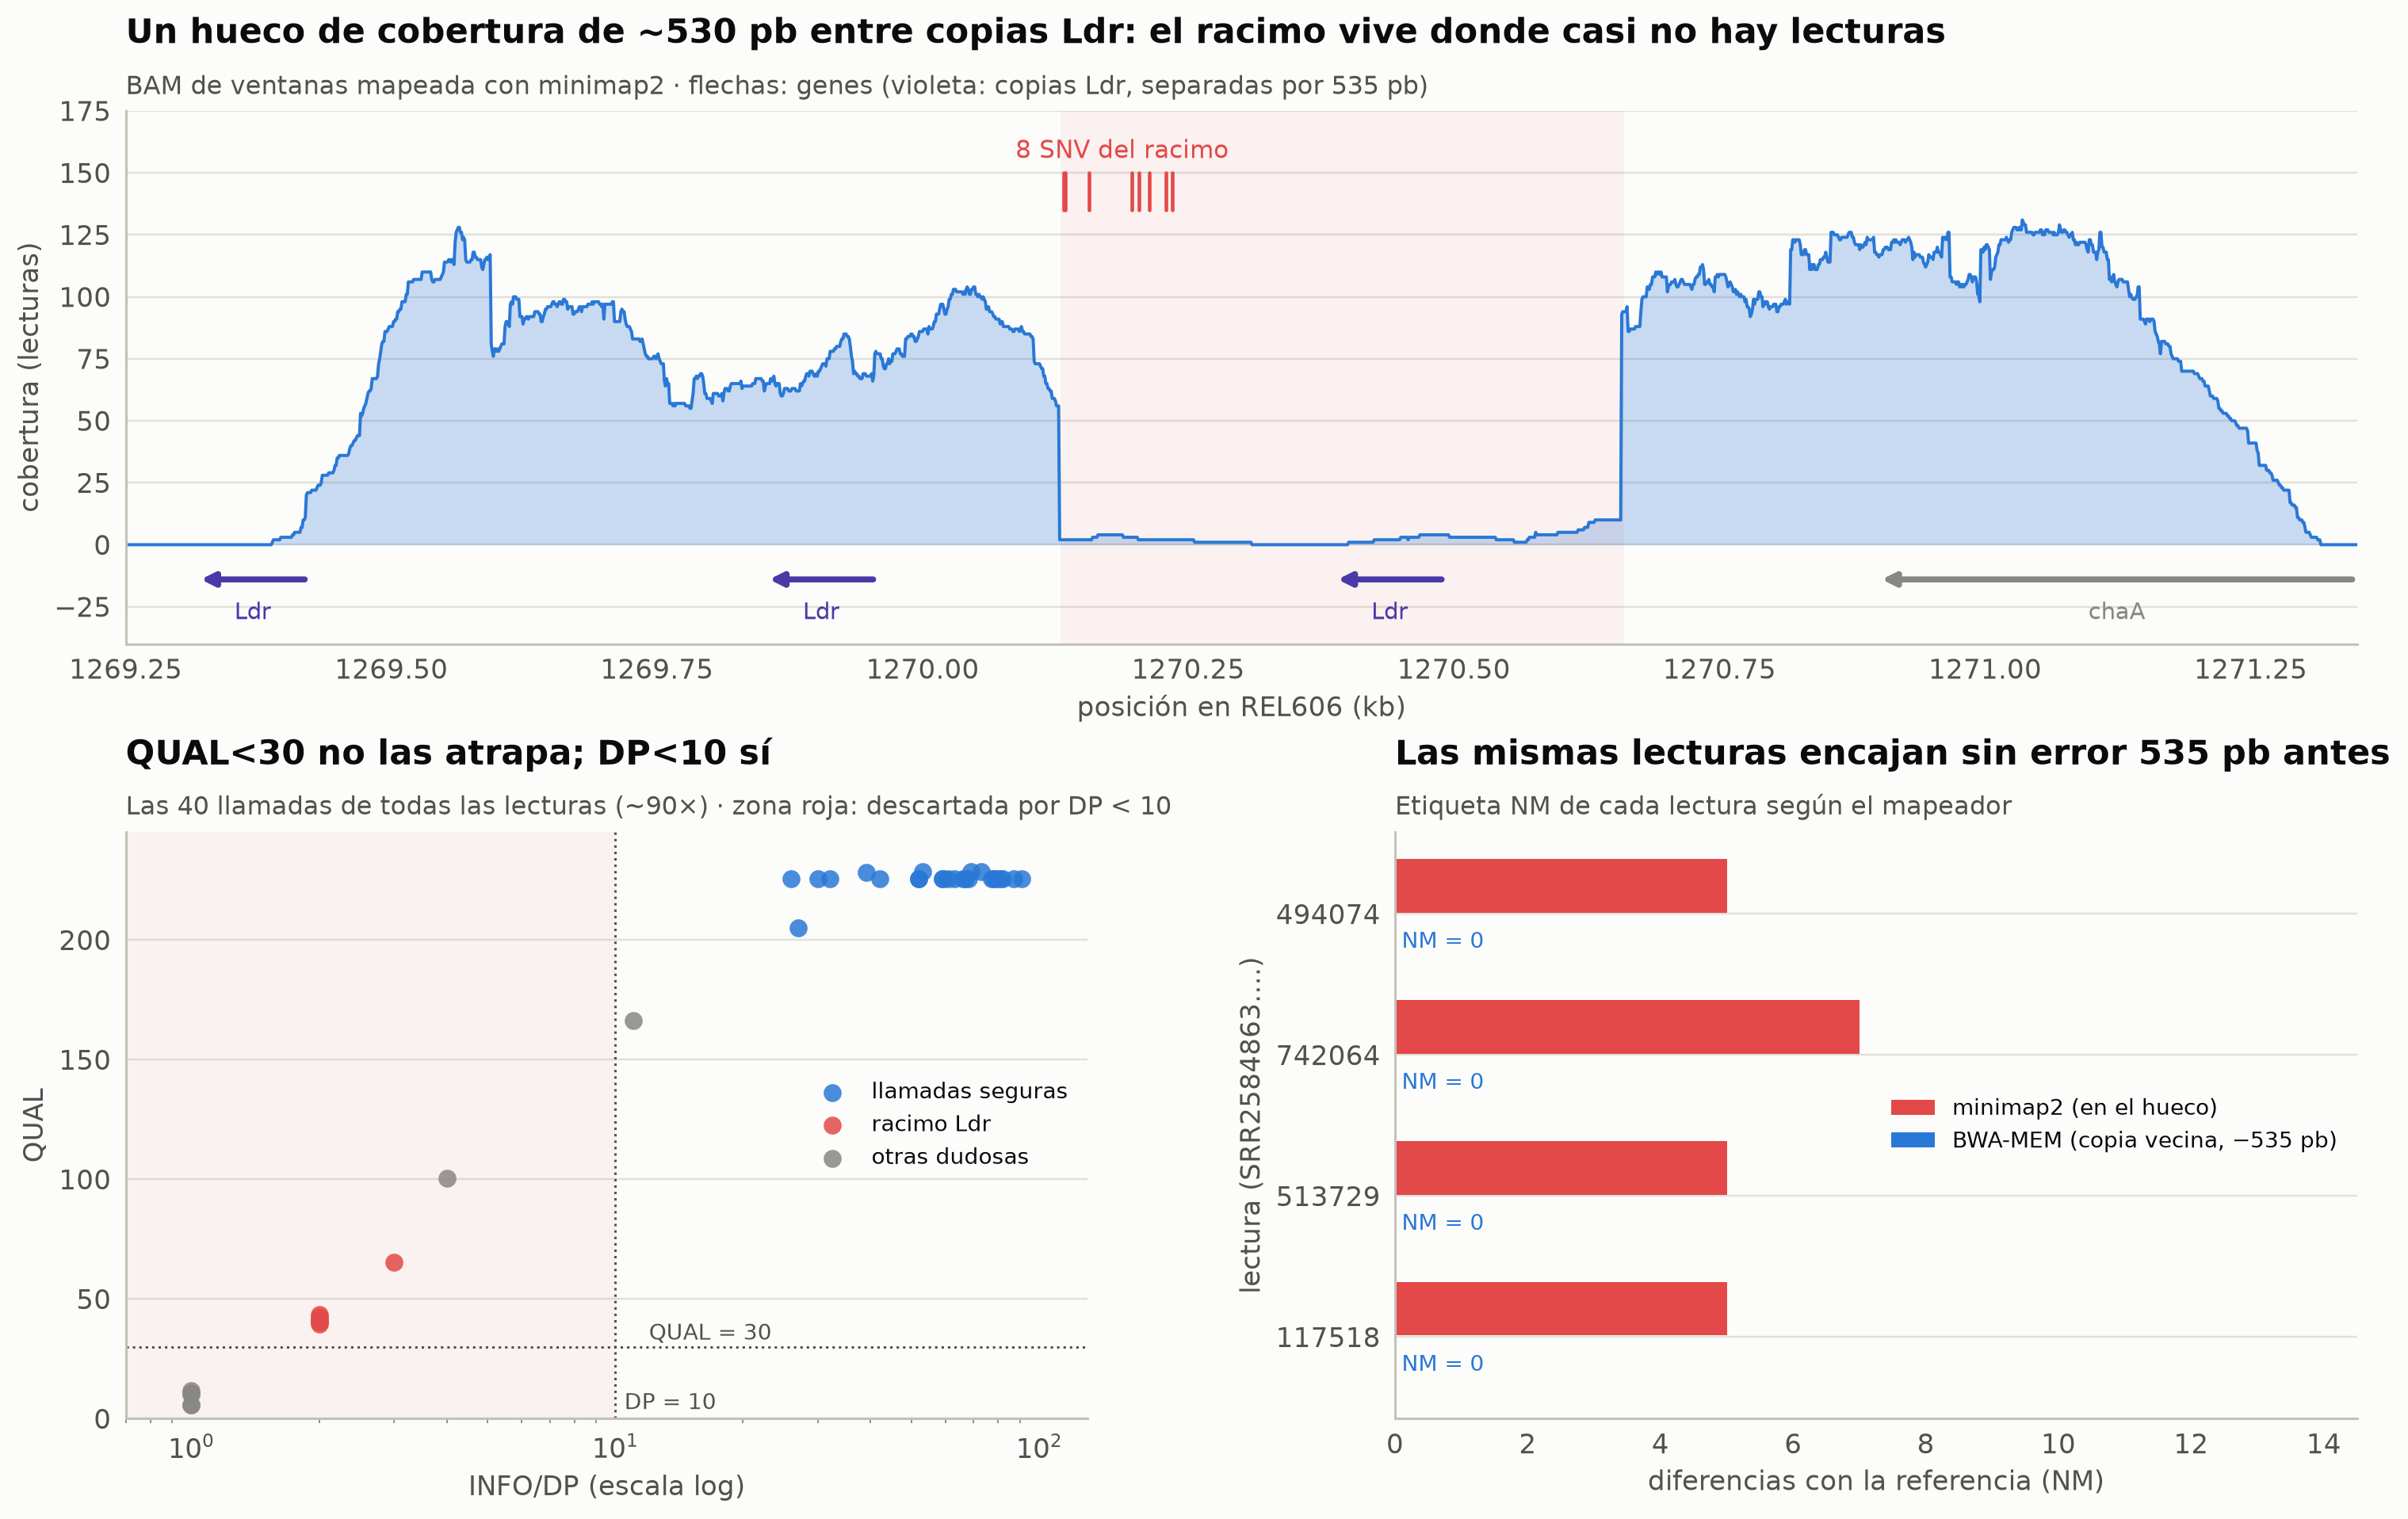

In [20]:
fig = plt.figure(figsize=(13.5, 8.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax = fig.add_subplot(gs[0, :])
x = np.arange(lo, hi + 1) / 1e3
ax.fill_between(x, cov_mm2, color=ec.BLUE, alpha=0.25, lw=0)
ax.plot(x, cov_mm2, color=ec.BLUE, lw=1.3)
for _, g in ldr_genes.iterrows():
    col = ec.VIOLET if "Ldr" in g["product"] else ec.MUTED
    gs_, ge_ = max(g.start, lo), min(g.end, hi)
    if ge_ <= gs_:
        continue
    ax.annotate("", (gs_ / 1e3, -14), (ge_ / 1e3, -14),
                arrowprops=dict(arrowstyle="-|>" if g.strand == "-" else "<|-", color=col, lw=2.5))
    ax.text((gs_ + ge_) / 2e3, -30, ("Ldr" if "Ldr" in g["product"] else (g.gene if isinstance(g.gene, str) else "")),
            ha="center", fontsize=9.5, color=col)
for p in cluster.pos:
    ax.plot([p / 1e3] * 2, [135, 150], color=ec.RED, lw=1.5)
ax.text(cluster.pos.mean() / 1e3, 156, "8 SNV del racimo", ha="center", fontsize=10, color=ec.RED)
ax.axvspan(1270.13, 1270.66, color=ec.RED, alpha=0.06)
ax.set_ylim(-40, 175); ax.set_xlim(lo / 1e3, hi / 1e3)
ax.set_xlabel("posición en REL606 (kb)"); ax.set_ylabel("cobertura (lecturas)")
ec.title(ax, "Un hueco de cobertura de ~530 pb entre copias Ldr: el racimo vive donde casi no hay lecturas",
         "BAM de ventanas mapeada con minimap2 · flechas: genes (violeta: copias Ldr, separadas por 535 pb)")

ax2 = fig.add_subplot(gs[1, 0])
grp = {"llamadas seguras": ~c.ldr & (c.qual > 200), "racimo Ldr": c.ldr & (c.qual > 30),
       "otras dudosas": ~((~c.ldr & (c.qual > 200)) | (c.ldr & (c.qual > 30)))}
for (name, m), col in zip(grp.items(), [ec.BLUE, ec.RED, ec.MUTED]):
    ax2.scatter(c.dp[m], c.qual[m], s=55, color=col, alpha=0.85, edgecolor="white", label=name, zorder=3)
ax2.set_xscale("log")
ax2.axhline(30, color=ec.INK_2, ls=":", lw=1); ax2.axvline(10, color=ec.INK_2, ls=":", lw=1)
ax2.text(10.5, 4, "DP = 10", fontsize=9, color=ec.INK_2); ax2.text(12, 33, "QUAL = 30", fontsize=9, color=ec.INK_2)
ax2.fill_between([0.7, 10], 0, 245, color=ec.RED, alpha=0.05)
ax2.set_xlim(0.7, 130); ax2.set_ylim(0, 245)
ax2.set_xlabel("INFO/DP (escala log)"); ax2.set_ylabel("QUAL")
ax2.legend(loc="center right", fontsize=9, frameon=False)
ec.title(ax2, "QUAL<30 no las atrapa; DP<10 sí", "Las 40 llamadas de todas las lecturas (~90×) · zona roja: descartada por DP < 10")

ax3 = fig.add_subplot(gs[1, 1])
nm_mm2 = both.set_index("read").mm2_NM
nm_bwa = both.set_index("read").bwa_NM
yy = np.arange(len(nm_mm2))
ax3.barh(yy + 0.2, nm_mm2.values, height=0.38, color=ec.RED, label="minimap2 (en el hueco)")
ax3.barh(yy - 0.2, nm_bwa.values, height=0.38, color=ec.BLUE, label="BWA-MEM (copia vecina, −535 pb)")
for yi, v in zip(yy, nm_bwa.values):
    if v == 0:
        ax3.text(0.1, yi - 0.2, "NM = 0", va="center", fontsize=9, color=ec.BLUE)
ax3.set_yticks(yy, [n.split(".")[-1] for n in nm_mm2.index])
ax3.set_xlabel("diferencias con la referencia (NM)"); ax3.set_ylabel("lectura (SRR2584863.…)")
ax3.legend(loc="center right", fontsize=9, frameon=False)
ax3.set_xlim(0, 14.5)
ec.title(ax3, "Las mismas lecturas encajan sin error 535 pb antes", "Etiqueta NM de cada lectura según el mapeador")
plt.show()

> 🔎 **Qué observamos.** El diagnóstico tiene matices que vale la pena aprender:
>
> * **QUAL < 30 no basta**: las ocho llamadas tienen QUAL 39–65. Dos lecturas perfectas que dicen lo mismo en un
>   haploide dan, según el modelo, bastante evidencia. El modelo no sabe que esas lecturas son de otra copia.
> * **MQ no las detecta**: minimap2 les dio MAPQ 50–60. La MAPQ mide la ambigüedad **que el mapeador percibe**; si se
>   equivoca de copia con confianza, la MAPQ no lo delata.
> * **DP < 10 sí**: 2–3 lecturas donde el resto del genoma tiene ~60 es la firma más clara. El filtro del libro
>   (`QUAL<30 || INFO/DP<10`) elimina el racimo entero y deja pasar las 25 llamadas seguras y la inserción de
>   3 901 455, que aun así no daremos por confirmada (sesgo de hebra total; véase el ejercicio 2).
> * **Sesgo de hebra y densidad** apuntan en la dirección correcta (todas las lecturas alternativas en una sola hebra,
>   ocho SNV en 100 pb en un genoma con una mutación cada ~180 kb), pero con dos lecturas el sesgo de hebra no tiene
>   potencia estadística: no se puede distinguir de la mala suerte.
> * El mejor filtro fue **otro mapeador**. Llamar con dos mapeadores y desconfiar de lo que sólo uno ve es una
>   práctica habitual en los laboratorios clínicos.
>
> Sobre la ayuda de `bcftools filter`: `-g/--SnpGap` marca SNV a menos de *n* pb de un *indel* y `-G/--IndelGap`
> agrupa *indels* cercanos; ninguno de los dos mide la densidad de SNV, que aquí calculamos a mano.

> ✅ **Compruebe su comprensión.** En un exoma humano a 500× usted aplica `INFO/DP<10`. ¿Protege contra el racimo
> Ldr equivalente? ¿Qué filtro de profundidad añadiría? *(Un racimo de parálogos en humanos suele tener DP
> **excesivo**, porque colapsan las lecturas de varias copias sobre una: hace falta el máximo $\bar d + k\sqrt{\bar d}$.
> Aquí fue un hueco, un DP mínimo; la lección es mirar la profundidad **relativa** a la de su entorno.)*

## 7. La razón ti/tv como termómetro

¿Cómo saber si un conjunto de variantes es bueno si no conocemos la verdad? Un indicador clásico aprovecha la química
de las mutaciones.

* Las **transiciones** (ti) cambian una purina por otra purina (`A↔G`) o una pirimidina por otra (`C↔T`).
* Las **transversiones** (tv) cambian una purina por una pirimidina o viceversa.

De las 12 sustituciones posibles, **4 son transiciones y 8 transversiones**, así que si las variantes fueran errores
aleatorios uniformes la razón ti/tv sería $4/8 = 0.5$. Las mutaciones reales, en cambio, están muy sesgadas hacia las
transiciones (por ejemplo, por la desaminación de citosinas metiladas en dinucleótidos CpG): en humanos, la razón en
variantes de alta calidad ronda **2.0–2.1** en genomas completos y valores cercanos a **3** en exomas. DePristo *et al.*
(2011) la usaron como una de sus métricas centrales de calidad.

### La mezcla de verdaderas y falsas

Suponga que las variantes verdaderas tienen razón $R_T$ y los falsos positivos razón $R_F = 0.5$. Si una fracción
$\alpha$ del conjunto son falsos positivos, la fracción observada de transiciones es una mezcla:

$$
p_{\text{obs}} = (1-\alpha)\,p_T + \alpha\,p_F,\qquad p = \frac{R}{1+R}
\quad\Longrightarrow\quad
\alpha = \frac{p_T - p_{\text{obs}}}{p_T - p_F}.
$$

| Símbolo | Significado |
|---|---|
| $R_T,\ R_F$ | razón ti/tv de las variantes verdaderas y de los errores |
| $p_T,\ p_F,\ p_\text{obs}$ | fracción de transiciones entre las verdaderas, los errores y el conjunto observado |
| $\alpha$ | fracción de falsos positivos en el conjunto |

La razón se convierte en fracción con $p = R/(1+R)$ porque las fracciones sí se mezclan linealmente; las razones no.

**Ejemplo resuelto del libro.** Con $R_T = 2.1$ y un conjunto observado con $R_\text{obs} = 1.8$: $p_T = 0.677$,
$p_\text{obs} = 0.643$ y $p_F = 0.333$, así que $\alpha \approx 0.10$. Una caída de la ti/tv de 2.1 a 1.8, que parece
modesta, delata que **uno de cada diez sitios es falso**. Con $R_\text{obs} = 2.0$ la estimación baja a
$\alpha \approx 0.03$.

In [21]:
def frac(R):
    return R / (1 + R)

def alpha_fp(R_obs, R_T, R_F=0.5):
    """Fracción de falsos positivos implícita en una ti/tv observada (ecuación 09-titv del libro)."""
    return (frac(R_T) - frac(R_obs)) / (frac(R_T) - frac(R_F))

pT, pobs, pF = frac(2.1), frac(1.8), frac(0.5)
print(f"p_T = {pT:.3f}   p_obs = {pobs:.3f}   p_F = {pF:.3f}")
print(f"R_obs = 1.8 → α = {alpha_fp(1.8, 2.1):.3f}")
print(f"R_obs = 2.0 → α = {alpha_fp(2.0, 2.1):.3f}")
assert round(alpha_fp(1.8, 2.1), 2) == 0.10 and round(alpha_fp(2.0, 2.1), 2) == 0.03

p_T = 0.677   p_obs = 0.643   p_F = 0.333
R_obs = 1.8 → α = 0.100
R_obs = 2.0 → α = 0.031


La figura interactiva generaliza el ejemplo: para cada $R_T$, cuánto falso positivo delata cada ti/tv observada. Pase el
cursor por las curvas.

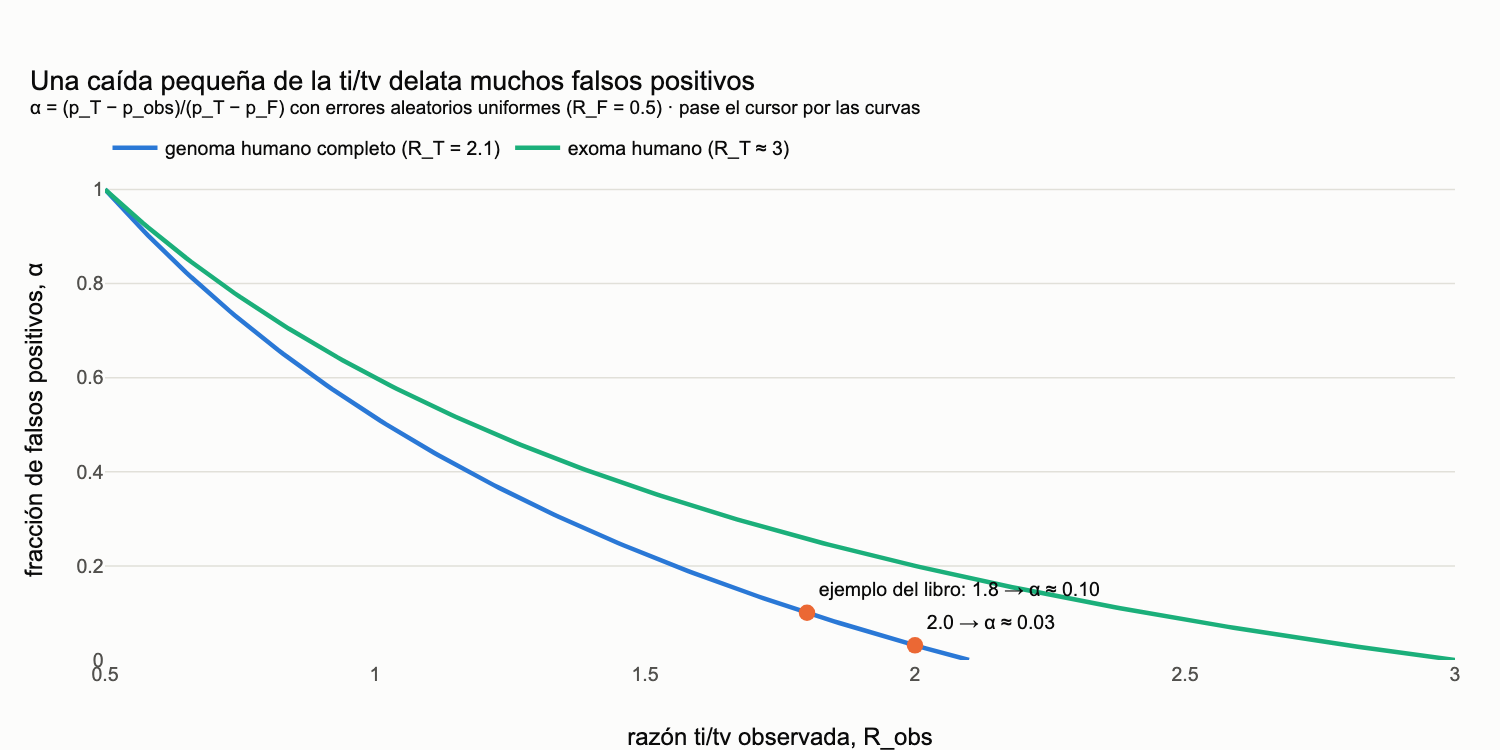

In [22]:
R_obs = np.linspace(0.5, 3.2, 271)
fig = go.Figure()
for R_T, name, col in [(2.1, "genoma humano completo (R_T = 2.1)", ec.BLUE), (3.0, "exoma humano (R_T ≈ 3)", ec.AQUA)]:
    a = alpha_fp(R_obs, R_T)
    m = (a >= 0) & (a <= 1)
    fig.add_trace(go.Scatter(
        x=R_obs[m], y=a[m], name=name, mode="lines", line=dict(color=col, width=3),
        customdata=np.stack([frac(R_obs[m]), np.round(1 / np.maximum(a[m], 1e-9))], axis=1),
        hovertemplate=(f"<b>{name}</b><br>ti/tv observada %{{x:.2f}} (p_obs = %{{customdata[0]:.3f}})<br>"
                       "α = %{y:.3f} → ≈ 1 falsa de cada %{customdata[1]:.0f}<extra></extra>")))
for R, a, txt in [(1.8, alpha_fp(1.8, 2.1), "ejemplo del libro: 1.8 → α ≈ 0.10"),
                  (2.0, alpha_fp(2.0, 2.1), "2.0 → α ≈ 0.03")]:
    fig.add_trace(go.Scatter(x=[R], y=[a], mode="markers+text", marker=dict(size=11, color=ec.ORANGE),
                             text=[txt], textposition="top right", showlegend=False, hoverinfo="skip"))
fig.update_layout(
    title=dict(text="Una caída pequeña de la ti/tv delata muchos falsos positivos"
                    "<br><sup>α = (p_T − p_obs)/(p_T − p_F) con errores aleatorios uniformes (R_F = 0.5) · "
                    "pase el cursor por las curvas</sup>"),
    xaxis=dict(title="razón ti/tv observada, R_obs"), yaxis=dict(title="fracción de falsos positivos, α", range=[0, 1.02]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=500, margin=dict(t=120, l=70, r=30, b=60))
fig.show()

> 🔎 **Qué observamos.** Cerca de la verdad la curva es empinada: pasar de 2.1 a 1.9 ya implica un 6.5 % de sitios falsos.
> Por eso la ti/tv sirve de **alarma temprana**: si al relajar un filtro la ti/tv cae, lo que se está añadiendo es
> sobre todo ruido. La estimación es aproximada (los errores reales no son uniformes y $R_T$ depende de la región).

### El termómetro en nuestro clon… y cuándo engaña

Calculemos la ti/tv de las mutaciones del clon que pasan el filtro, y veamos qué pasa si dejamos entrar el racimo Ldr.
Además de la razón, miramos el **espectro**: las seis clases de sustitución, agrupando cada una con su complementaria
(por ejemplo `A→C` y `T→G` son la misma mutación `A:T→C:G` vista desde una u otra hebra).

In [23]:
COMP = str.maketrans("ACGT", "TGCA")
def spectrum_class(ref, alt):
    """Clase de sustitución de doble hebra, con la base de referencia expresada como A o G... (convención A:T / G:C)."""
    if ref in "CT":                                      # llevar a la hebra con purina en la referencia
        ref, alt = ref.translate(COMP), alt.translate(COMP)
    pair = {"A": "A:T", "G": "G:C"}[ref]
    return f"{pair}→{ {'A': 'A:T', 'G': 'G:C', 'C': 'C:G', 'T': 'T:A'}[alt] }"

pass_snv = calls100[(calls100.filter_book == "PASS") & (calls100.tipo != "indel")]
clus_snv = calls100[calls100.ldr & (calls100.qual > 30)]
def titv(df):
    ti, tv = (df.tipo == "transición").sum(), (df.tipo == "transversión").sum()
    return ti, tv, ti / tv
for name, df in [("PASS (mutaciones del clon)", pass_snv), ("racimo Ldr", clus_snv),
                 ("PASS + racimo", pd.concat([pass_snv, clus_snv]))]:
    ti, tv, r = titv(df)
    print(f"{name:28s}: ti = {ti:2d}, tv = {tv:2d}, ti/tv = {r:.2f}")
ti, tv, R_pass = titv(pass_snv)
_, _, R_mix = titv(pd.concat([pass_snv, clus_snv]))
print(f"\nα 'ingenua' con R_T = {R_pass:.2f}, R_F = 0.5 y R_obs = {R_mix:.2f}: {alpha_fp(R_mix, R_pass):.2f}  "
      f"(fracción real de falsas: {len(clus_snv)}/{len(pass_snv) + len(clus_snv)} = "
      f"{len(clus_snv) / (len(pass_snv) + len(clus_snv)):.2f})")
spec = pd.DataFrame({"PASS": pass_snv.apply(lambda r: spectrum_class(r.ref, r.alt), axis=1).value_counts(),
                     "racimo Ldr": clus_snv.apply(lambda r: spectrum_class(r.ref, r.alt), axis=1).value_counts()}).fillna(0).astype(int)
order = ["A:T→G:C", "G:C→A:T", "A:T→C:G", "A:T→T:A", "G:C→T:A", "G:C→C:G"]
spec = spec.reindex(order).fillna(0).astype(int)
print("\n", spec.T.to_string())

PASS (mutaciones del clon)  : ti =  5, tv = 15, ti/tv = 0.33
racimo Ldr                  : ti =  6, tv =  2, ti/tv = 3.00
PASS + racimo               : ti = 11, tv = 17, ti/tv = 0.65

α 'ingenua' con R_T = 0.33, R_F = 0.5 y R_obs = 0.65: 1.71  (fracción real de falsas: 8/28 = 0.29)

             A:T→G:C  G:C→A:T  A:T→C:G  A:T→T:A  G:C→T:A  G:C→C:G
PASS              2        3        8        1        6        0
racimo Ldr        3        3        1        1        0        0


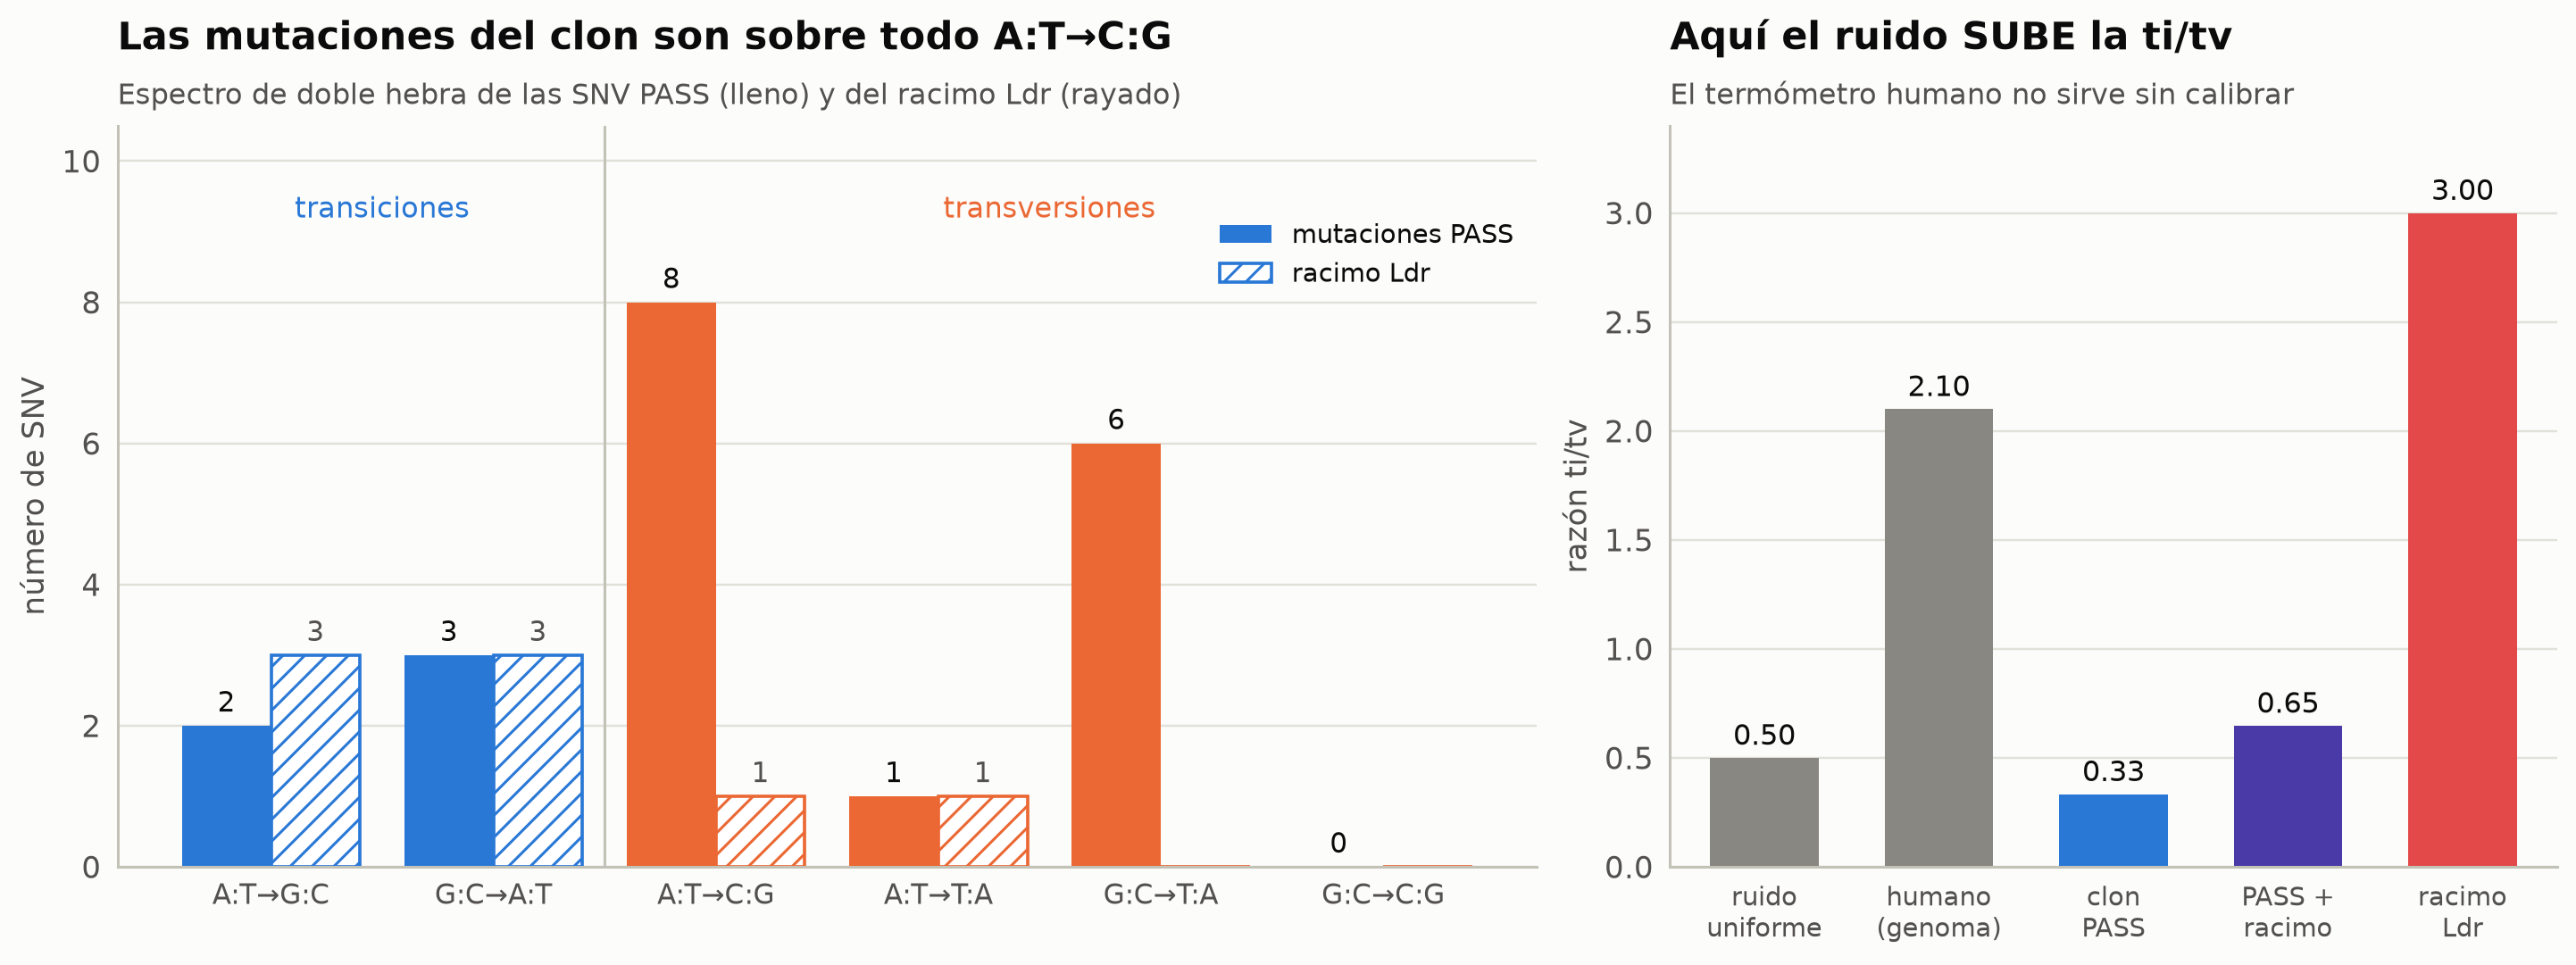

In [24]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.6, 1]))
xx = np.arange(len(order))
a1.bar(xx - 0.2, spec["PASS"], width=0.4, color=[ec.BLUE] * 2 + [ec.ORANGE] * 4, label="mutaciones PASS")
a1.bar(xx + 0.2, spec["racimo Ldr"], width=0.4, color="white", edgecolor=[ec.BLUE] * 2 + [ec.ORANGE] * 4,
       hatch="///", lw=1.2, label="racimo Ldr")
for xi, (v1, v2) in enumerate(zip(spec["PASS"], spec["racimo Ldr"])):
    a1.text(xi - 0.2, v1 + 0.2, str(v1), ha="center", fontsize=10)
    if v2:
        a1.text(xi + 0.2, v2 + 0.2, str(v2), ha="center", fontsize=10, color=ec.INK_2)
a1.set_xticks(xx, order, fontsize=10)
a1.axvline(1.5, color=ec.BASELINE, lw=1)
a1.text(0.5, spec.values.max() + 1.2, "transiciones", ha="center", color=ec.BLUE, fontsize=10.5)
a1.text(3.5, spec.values.max() + 1.2, "transversiones", ha="center", color=ec.ORANGE, fontsize=10.5)
a1.set_ylim(0, spec.values.max() + 2.5); a1.set_ylabel("número de SNV")
a1.legend(loc="upper right", frameon=False, fontsize=9.5, bbox_to_anchor=(1, 0.9))
ec.title(a1, "Las mutaciones del clon son sobre todo A:T→C:G", "Espectro de doble hebra de las SNV PASS (lleno) y del racimo Ldr (rayado)")
labels = ["ruido\nuniforme", "humano\n(genoma)", "clon\nPASS", "PASS +\nracimo", "racimo\nLdr"]
vals = [0.5, 2.1, R_pass, R_mix, titv(clus_snv)[2]]
cols = [ec.MUTED, ec.MUTED, ec.BLUE, ec.VIOLET, ec.RED]
a2.bar(range(5), vals, color=cols, width=0.62)
for i, v in enumerate(vals):
    a2.text(i, v + 0.06, f"{v:.2f}", ha="center", fontsize=10.5)
a2.set_xticks(range(5), labels, fontsize=9.5); a2.set_ylabel("razón ti/tv"); a2.set_ylim(0, 3.4)
ec.title(a2, "Aquí el ruido SUBE la ti/tv", "El termómetro humano no sirve sin calibrar")
plt.show()

> 🔎 **Qué observamos.** Dos sorpresas que ningún libro de recetas le contará:
>
> 1. **La ti/tv verdadera del clon es ~0.33**, muy por debajo incluso del 0.5 del ruido uniforme. El espectro está
>    dominado por **A:T→C:G**, una transversión. Ese patrón es compatible con la firma conocida de las lesiones
>    8-oxo-dG que normalmente elimina la enzima MutT; **no** afirmamos que este clon sea hipermutador (ninguna de las
>    llamadas cae en el gen *mutT*, en 113 848–114 237, y no lo hemos investigado), pero sí que su $R_T$ no se parece
>    en nada al humano.
> 2. **Añadir los falsos positivos del racimo sube la ti/tv** (de 0.33 a 0.65), justo lo contrario de la intuición
>    humana. Las "SNV" del racimo no son errores aleatorios de secuenciación (el supuesto $R_F = 0.5$): son diferencias
>    reales entre copias parálogas, que evolucionaron con sus propias transiciones. Con esos supuestos rotos, la
>    ecuación da una $\alpha$ absurda (mayor que 1).
>
> La lección: la ti/tv es un termómetro **calibrado para un organismo, una región y un proceso mutacional**. Antes de
> usarla hay que conocer $R_T$ y el tipo de error dominante. En humanos, con miles de variantes, es una alarma
> excelente; en 25 mutaciones de un clon bacteriano, no.

## 8. Evaluar frente a la verdad: Genome in a Bottle y hap.py

### ¿Por qué hace falta una verdad?

Todo lo anterior son indicios. La única forma rigurosa de medir la exactitud de un llamador es compararlo con un genoma
cuyo genotipo verdadero se conozca. El consorcio **Genome in a Bottle** (GIAB), coordinado por el NIST, construyó
exactamente eso: Zook *et al.* (2014) integraron y arbitraron 14 conjuntos de datos de NA12878 (HG001), obtenidos con
cinco tecnologías de secuenciación, siete alineadores y tres llamadores, para producir genotipos de alta confianza
(SNP, *indels* y homocigotos de referencia), junto con la delimitación de las **regiones** donde no era posible un
genotipo confiable. Zook *et al.* (2019) añadieron seis genomas del Personal Genome Project con consentimiento abierto
(entre ellos los tríos HG002–HG004 y HG005–HG007); respecto de las versiones anteriores, el nuevo recurso contiene un
17 % más de SNV, un 176 % más de *indels* y regiones de referencia un 12 % mayores.

Comparar dos VCF no es trivial: las mismas variantes pueden estar representadas de forma diferente (sección 5), incluso
más allá de la normalización, cuando varias variantes cercanas se escriben como una sola sustitución compleja. El
equipo de evaluación de la Global Alliance for Genomics and Health estableció buenas prácticas y herramientas, como
**hap.py**, que comparan **haplotipos** en lugar de registros (Krusche *et al.*, 2019). Esos autores muestran también por
qué importa restringirse a las regiones de alta confianza: la concordancia de SNV entre dos métodos era del **99.7 %**
dentro de ellas y de sólo el **76.5 %** fuera.

### Las métricas

Sean TP las variantes del conjunto de verdad correctamente llamadas, FP las llamadas ausentes de la verdad y FN las
variantes de la verdad no llamadas, todas restringidas a las regiones de alta confianza. Entonces

$$
\text{precisión} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}},\qquad
\text{sensibilidad} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}},\qquad
F_1 = \frac{2\,\mathrm{TP}}{2\,\mathrm{TP}+\mathrm{FP}+\mathrm{FN}}.
$$

| Símbolo | Significado |
|---|---|
| TP, FP, FN | verdaderos positivos, falsos positivos y falsos negativos |
| precisión | fracción de las llamadas que son reales (su complemento es la tasa de falsos descubrimientos) |
| sensibilidad | fracción de las variantes reales que se detectaron (*recall*) |
| $F_1$ | media armónica de precisión y sensibilidad |

En palabras del laboratorio: la **precisión** responde "de lo que le entregué al médico, ¿cuánto era cierto?"; la
**sensibilidad**, "de lo que el paciente tenía, ¿cuánto encontré?". Observe que **no aparecen los verdaderos
negativos**: en un genoma hay miles de millones de posiciones sin variante, y cualquier métrica que los incluyera (como
la especificidad) sería prácticamente 1 para cualquier llamador. Por la misma razón, en este contexto se prefieren las
curvas de precisión-sensibilidad a las curvas ROC.

### Ejemplo resuelto del libro: leer un informe de hap.py

Un llamador aplicado a HG002 produce, en las regiones de alta confianza, $\mathrm{TP} = 3\,290\,000$ SNV,
$\mathrm{FP} = 9\,800$ y $\mathrm{FN} = 21\,500$ (cifras redondas de orden realista).

In [25]:
def metrics(TP, FP, FN):
    prec = TP / (TP + FP) if TP + FP else 1.0
    sens = TP / (TP + FN) if TP + FN else float("nan")
    f1 = 2 * TP / (2 * TP + FP + FN) if TP + FP + FN else float("nan")
    return prec, sens, f1

prec, sens, f1 = metrics(3_290_000, 9_800, 21_500)
print(f"precisión    = 3 290 000 / 3 299 800 = {prec:.5f}")
print(f"sensibilidad = 3 290 000 / 3 311 500 = {sens:.5f}")
print(f"F1           = {f1:.5f}")
assert (round(prec, 5), round(sens, 5), round(f1, 5)) == (0.99703, 0.99351, 0.99527)

precisión    = 3 290 000 / 3 299 800 = 0.99703
sensibilidad = 3 290 000 / 3 311 500 = 0.99351
F1           = 0.99527


Todo parece excelente, pero en valores absolutos hay **casi diez mil falsos positivos y más de veinte mil variantes
perdidas**. En un laboratorio clínico, cada una de esas 21 500 podría ser la variante que explica la enfermedad de un
paciente. Por eso se informan las métricas **por separado para SNV e *indels*** y **estratificadas por tipo de región**
(repeticiones, homopolímeros, duplicaciones segmentarias…).

### Nuestro mini-GIAB: la verdad a ~90× y el mismo pipeline a 5, 10, 20 y 40×

Construyamos una evaluación de la misma forma, con nuestro clon:

* **Verdad**: las llamadas de **todas** las lecturas (~90× de media), normalizadas y que pasan el filtro del libro
  (`QUAL<30 || INFO/DP<10` → `PASS`), **menos** la inserción de 3 901 455: pasa el filtro, pero todas sus lecturas
  alternativas vienen de una sola hebra (`DP4 = 0,0,11,0`) y no la consideramos confirmada. Quedan **25 mutaciones**.
  Como en GIAB, la verdad sale de muchos más datos que la prueba.
* **Regiones de alta confianza**: las ventanas de ±600 pb alrededor de las 40 llamadas crudas, que es donde tenemos
  lecturas, **excepto** la ventana de la inserción dudosa, que marcamos como «no evaluable»: GIAB hace lo mismo con
  las regiones donde no puede dar un genotipo confiable. Es nuestro equivalente del BED de GIAB: todo lo que se llame
  fuera de él no se evalúa.
* **Prueba**: el pipeline de la sección 3 (BWA-MEM + `bcftools`) sobre las lecturas **submuestreadas** al azar con
  `samtools view -s SEMILLA.FRACCIÓN`, cinco réplicas con semillas distintas para cada profundidad objetivo.
* **Comparación**: por coincidencia exacta de $(\mathrm{POS},\mathrm{REF},\mathrm{ALT})$ **normalizados**; con
  variantes tan separadas, eso equivale a lo que haría hap.py.

> 🤔 **Antes de ejecutar, prediga.** A 5× (cinco lecturas por posición en promedio), ¿qué fracción de las 25 mutaciones
> verdaderas cree que se detectará? ¿Y cuántas llamadas falsas aparecerán?

In [26]:
UNCONFIRMED = [3_901_455]                              # inserción con todas las lecturas ALT en una hebra
MASK = [(p - 600, p + 600) for p in UNCONFIRMED]       # su ventana queda «no evaluable», como fuera del BED de GIAB
def masked(p):
    return any(s <= p <= e for s, e in MASK)
truth = {normalize(r.pos, r.ref, r.alt, genome) for r in calls100[calls100.filter_book == "PASS"].itertuples()
         if not masked(r.pos)}
print(f"Verdad: {len(truth)} variantes ({sum(len(r) == 1 and len(a) == 1 for _, r, a in truth)} SNV, "
      f"{sum(len(r) != len(a) for _, r, a in truth)} indels)")
iv = sorted((max(1, p - 600), p + 600 + len(r)) for p, r in zip(calls100.pos, calls100.ref))
bed = []
for s, e in iv:                                        # fusionar intervalos solapados
    if bed and s <= bed[-1][1]:
        bed[-1][1] = max(bed[-1][1], e)
    else:
        bed.append([s, e])
bed_starts = np.array([s for s, _ in bed]); bed_ends = np.array([e for _, e in bed])
def in_bed(p):
    i = np.searchsorted(bed_starts, p, side="right") - 1
    return i >= 0 and p <= bed_ends[i] and not masked(p)
n_masked = sum(masked(p) for s, e in bed for p in range(s, e + 1))
print(f"Regiones de alta confianza: {len(bed)} intervalos, {sum(e - s for s, e in bed) - n_masked:,} pb evaluables "
      f"({n_masked:,} pb «no evaluables» alrededor de {', '.join(f'{p:,}' for p in UNCONFIRMED)})")

def parse_calls(vcf_text):
    out = []
    for l in vcf_text.splitlines():
        if l and not l.startswith("#"):
            f = l.split("\t")
            dp = int(re.search(r"(?:^|;)DP=(\d+)", f[7]).group(1))
            for alt in f[4].split(","):
                out.append((int(f[1]), f[3], alt, float(f[5]), dp))
    return out

DEPTHS, REPS = [5, 10, 20, 40], 5
t0 = time.time()
if HAS_TOOLS:
    full_bam = pysam.AlignmentFile(BAM)
    def mean_cov(bamfile):
        b = pysam.AlignmentFile(bamfile)
        return float(np.mean([b.count(CHROM, p - 1, p) for p, _, _ in truth]))
    cov_full = mean_cov(BAM)
    rows = []
    for d in DEPTHS:
        fraction = d / cov_full
        for rep in range(1, REPS + 1):
            sh(f"samtools view -b -s {rep}{f'{fraction:.4f}'[1:]} -o ds.bam {BAM} && samtools index ds.bam", quiet=True)
            cov = mean_cov("ds.bam")
            vcf_txt = sh("bcftools mpileup -Ou -f REL606.fa -q 20 -Q 20 -a FORMAT/AD,FORMAT/DP ds.bam | "
                         "bcftools call --ploidy 1 -mv -Ou | bcftools norm -f REL606.fa -m -any -Ov", quiet=True)[0]
            calls = parse_calls(vcf_txt)
            rows += [dict(target=d, rep=rep, cov=cov, pos=p, ref=r, alt=a, qual=q, dp=dpp) for p, r, a, q, dpp in calls]
            rows.append(dict(target=d, rep=rep, cov=cov, pos=0, ref="", alt="", qual=np.nan, dp=0))   # fila de cobertura
    full_calls = parse_calls(gzip.open(FILES["final"], "rt").read())
    rows += [dict(target=100, rep=1, cov=cov_full, pos=p, ref=r, alt=a, qual=q, dp=dpp) for p, r, a, q, dpp in full_calls]
    rows.append(dict(target=100, rep=1, cov=cov_full, pos=0, ref="", alt="", qual=np.nan, dp=0))
    ds = pd.DataFrame(rows)
    ds.to_csv("92_downsample_calls.tsv.gz", sep="\t", index=False)
    if EXPORT:
        shutil.copy("92_downsample_calls.tsv.gz", EXPORT)
    print(f"Submuestreo en vivo: {len(DEPTHS)} profundidades × {REPS} réplicas en {time.time() - t0:.1f} s")
else:
    ds = pd.read_csv(course_file("92_downsample_calls.tsv.gz"), sep="\t", keep_default_na=True).fillna({"ref": "", "alt": ""})
    print("Llamadas precalculadas del submuestreo (mismos comandos, bcftools 1.24)")
cov_tab = ds.groupby(["target", "rep"])["cov"].first().groupby("target").mean()
ds["depth_label"] = ds.target.map(lambda t: f"{cov_tab[t]:.0f}×")
print("Cobertura media medida en los sitios verdaderos:", {f"objetivo {k}×" if k < 100 else "todas": f"{v:.1f}×"
                                                         for k, v in cov_tab.items()})

Verdad: 25 variantes (20 SNV, 5 indels)
Regiones de alta confianza: 29 intervalos, 34,111 pb evaluables (1,201 pb «no evaluables» alrededor de 3,901,455)


Submuestreo en vivo: 4 profundidades × 5 réplicas en 7.1 s
Cobertura media medida en los sitios verdaderos: {'objetivo 5×': '5.0×', 'objetivo 10×': '9.9×', 'objetivo 20×': '19.8×', 'objetivo 40×': '39.8×', 'todas': '91.7×'}


In [27]:
def evaluate(ds, target, t=0.0, min_dp=0):
    """TP, FP, FN sumados sobre las réplicas de una profundidad, con QUAL ≥ t e INFO/DP ≥ min_dp, dentro del BED."""
    sub = ds[(ds.target == target)]
    TP = FP = FN = 0
    fps = collections.Counter()
    for rep, g in sub.groupby("rep"):
        g = g[(g.pos > 0) & (g.qual >= t) & (g.dp >= min_dp)]
        called = {(p, r, a) for p, r, a in zip(g.pos, g.ref, g.alt) if in_bed(p)}
        TP += len(called & truth); FP += len(called - truth); FN += len(truth - called)
        fps.update(called - truth)
    return TP, FP, FN, fps

res = []
for tgt in sorted(ds.target.unique()):
    for label, t, mdp in [("QUAL ≥ 30", 30, 0), ("QUAL ≥ 30 y DP ≥ 10 (libro)", 30, 10)]:
        TP, FP, FN, fps = evaluate(ds, tgt, t, mdp)
        n = ds[ds.target == tgt].rep.nunique()
        p, s_, f = metrics(TP, FP, FN)
        res.append(dict(cobertura=f"{cov_tab[tgt]:.0f}×", filtro=label, TP=TP / n, FP=FP / n, FN=FN / n,
                        precisión=p, sensibilidad=s_, F1=f,
                        FP_ejemplos=", ".join(f"{q[0]:,}" for q, _ in fps.most_common(3))))
res = pd.DataFrame(res)
print("(TP, FP y FN: promedio por réplica; métricas: sobre las réplicas agregadas)\n")
print(res.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

(TP, FP y FN: promedio por réplica; métricas: sobre las réplicas agregadas)

cobertura                      filtro     TP    FP     FN  precisión  sensibilidad    F1          FP_ejemplos
       5×                   QUAL ≥ 30 20.600 0.000  4.400      1.000         0.824 0.904                     
       5× QUAL ≥ 30 y DP ≥ 10 (libro)  1.200 0.000 23.800      1.000         0.048 0.092                     
      10×                   QUAL ≥ 30 23.600 0.000  1.400      1.000         0.944 0.971                     
      10× QUAL ≥ 30 y DP ≥ 10 (libro) 12.000 0.000 13.000      1.000         0.480 0.649                     
      20×                   QUAL ≥ 30 25.000 0.000  0.000      1.000         1.000 1.000                     
      20× QUAL ≥ 30 y DP ≥ 10 (libro) 20.600 0.000  4.400      1.000         0.824 0.904                     
      40×                   QUAL ≥ 30 25.000 0.600  0.000      0.977         1.000 0.988            4,017,756
      40× QUAL ≥ 30 y DP ≥ 10 (libro) 24.60

> 🔎 **Qué observamos.** Lea la tabla como un informe de validación (las cifras exactas pueden variar un poco con otra
> versión de las herramientas, pero el patrón no):
>
> * Con **toda** la cobertura (~90×) y sólo `QUAL ≥ 30`, el pipeline encuentra las 25 mutaciones pero añade **dos
>   falsos positivos**: 4 017 756 y 4 017 761, dos sitios vecinos con muy pocas lecturas. El filtro completo del libro
>   (`DP ≥ 10`) los elimina y deja precisión y sensibilidad en 1.
> * La **sensibilidad cae con la cobertura**: en nuestra ejecución, ~0.82 a 5×, ~0.94 a 10× y 1 a 20× y 40×. Las
>   mutaciones perdidas son sitios donde por azar cayeron muy pocas lecturas, o ninguna.
> * La **precisión apenas cambia**: a baja cobertura los sitios dudosos simplemente no reciben lecturas suficientes
>   para ser llamados. Los falsos positivos de un pipeline sobre un genoma haploide y clonal son escasos; los de un
>   exoma humano, no.
> * El filtro **`DP ≥ 10` del libro es una trampa a baja cobertura**: a 5× deja la sensibilidad en ~0.05 y a 10× en
>   ~0.5. Los umbrales de un filtro se eligen **para una cobertura dada**; copiar el de un protocolo a 30× en uno de 5×
>   es un error clásico.

La figura interactiva muestra la curva precisión-sensibilidad de cada profundidad al barrer el umbral de QUAL. Pase el
cursor para leer TP, FP, FN y $F_1$ en cada umbral.

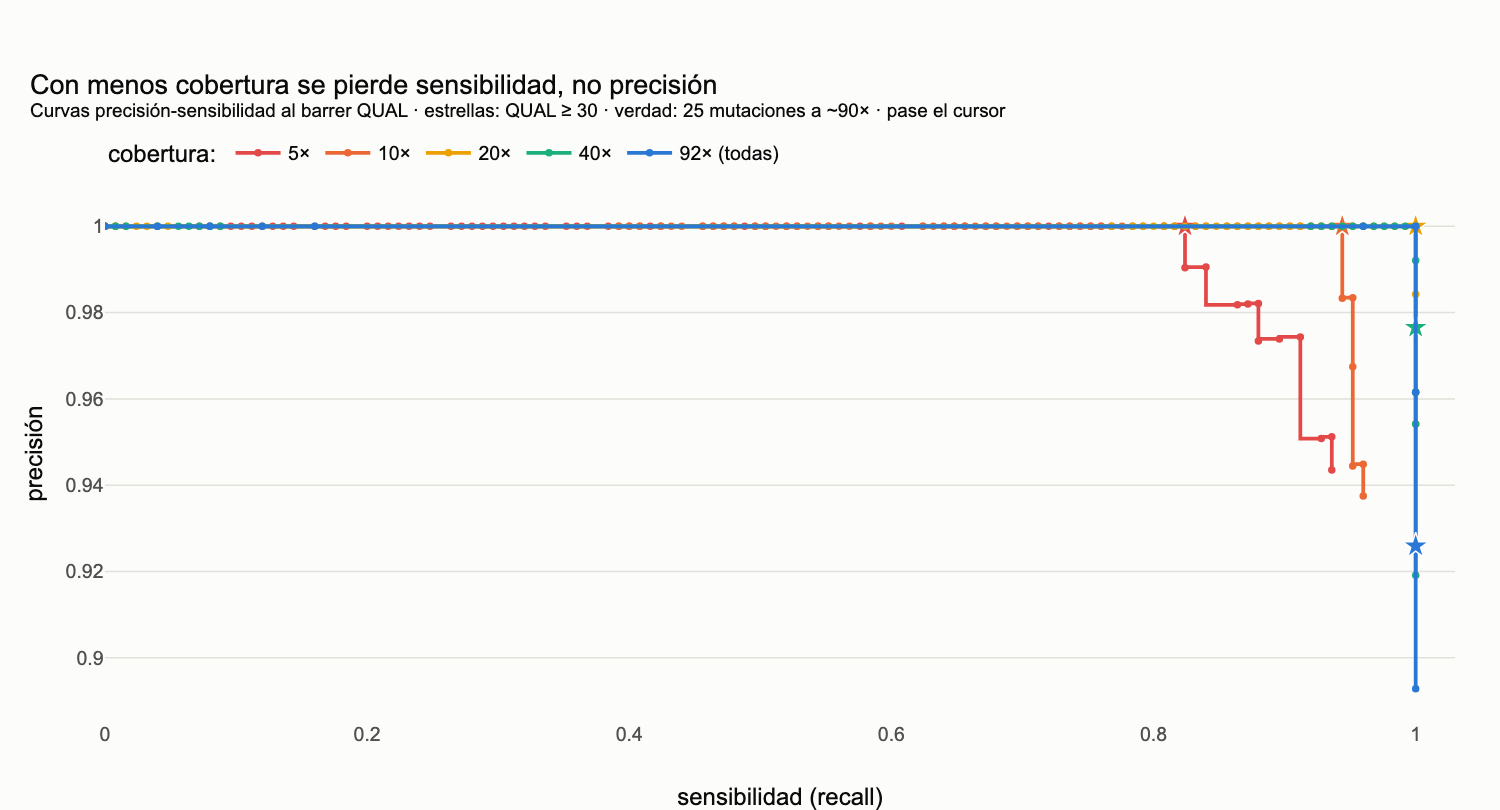

In [28]:
thr_grid = np.unique(np.concatenate([np.arange(0, 231, 1.0), ds.qual.dropna().round(3).values]))
curves = {}
for tgt in sorted(ds.target.unique()):
    pts = []
    for t in thr_grid:
        TP, FP, FN, _ = evaluate(ds, tgt, t)
        p, s_, f = metrics(TP, FP, FN)
        pts.append((t, TP, FP, FN, p, s_, f))
    curves[tgt] = pd.DataFrame(pts, columns=["t", "TP", "FP", "FN", "prec", "sens", "f1"])

pal = dict(zip(sorted(ds.target.unique()), [ec.RED, ec.ORANGE, ec.YELLOW, ec.AQUA, ec.BLUE]))
fig = go.Figure()
for tgt, cdf in curves.items():
    lab = f"{cov_tab[tgt]:.0f}×" + (" (todas)" if tgt == 100 else "")
    uniq = cdf.drop_duplicates(["TP", "FP"])
    fig.add_trace(go.Scatter(
        x=uniq.sens, y=uniq.prec, mode="lines+markers", name=lab, line=dict(color=pal[tgt], width=2.5, shape="hv"),
        marker=dict(size=5), customdata=uniq[["t", "TP", "FP", "FN", "f1"]].values,
        hovertemplate=(f"<b>{lab}</b> · QUAL ≥ %{{customdata[0]:.1f}}<br>TP %{{customdata[1]}} · FP %{{customdata[2]}} · "
                       "FN %{customdata[3]} (5 réplicas)<br>precisión %{y:.3f} · sensibilidad %{x:.3f} · "
                       "F1 %{customdata[4]:.3f}<extra></extra>")))
    r30 = cdf[cdf.t == 30].iloc[0]
    fig.add_trace(go.Scatter(x=[r30.sens], y=[r30.prec], mode="markers", showlegend=False,
                             marker=dict(size=13, color=pal[tgt], symbol="star", line=dict(color="white", width=1)),
                             hovertemplate=f"<b>{lab}</b>: QUAL ≥ 30<br>precisión %{{y:.3f}} · sensibilidad %{{x:.3f}}<extra></extra>"))
fig.update_layout(
    title=dict(text="Con menos cobertura se pierde sensibilidad, no precisión"
                    "<br><sup>Curvas precisión-sensibilidad al barrer QUAL · estrellas: QUAL ≥ 30 · verdad: 25 mutaciones "
                    "a ~90× · pase el cursor</sup>"),
    xaxis=dict(title="sensibilidad (recall)", range=[0, 1.03]), yaxis=dict(title="precisión"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, title="cobertura:"),
    height=540, margin=dict(t=125, l=70, r=30, b=60))
fig.show()

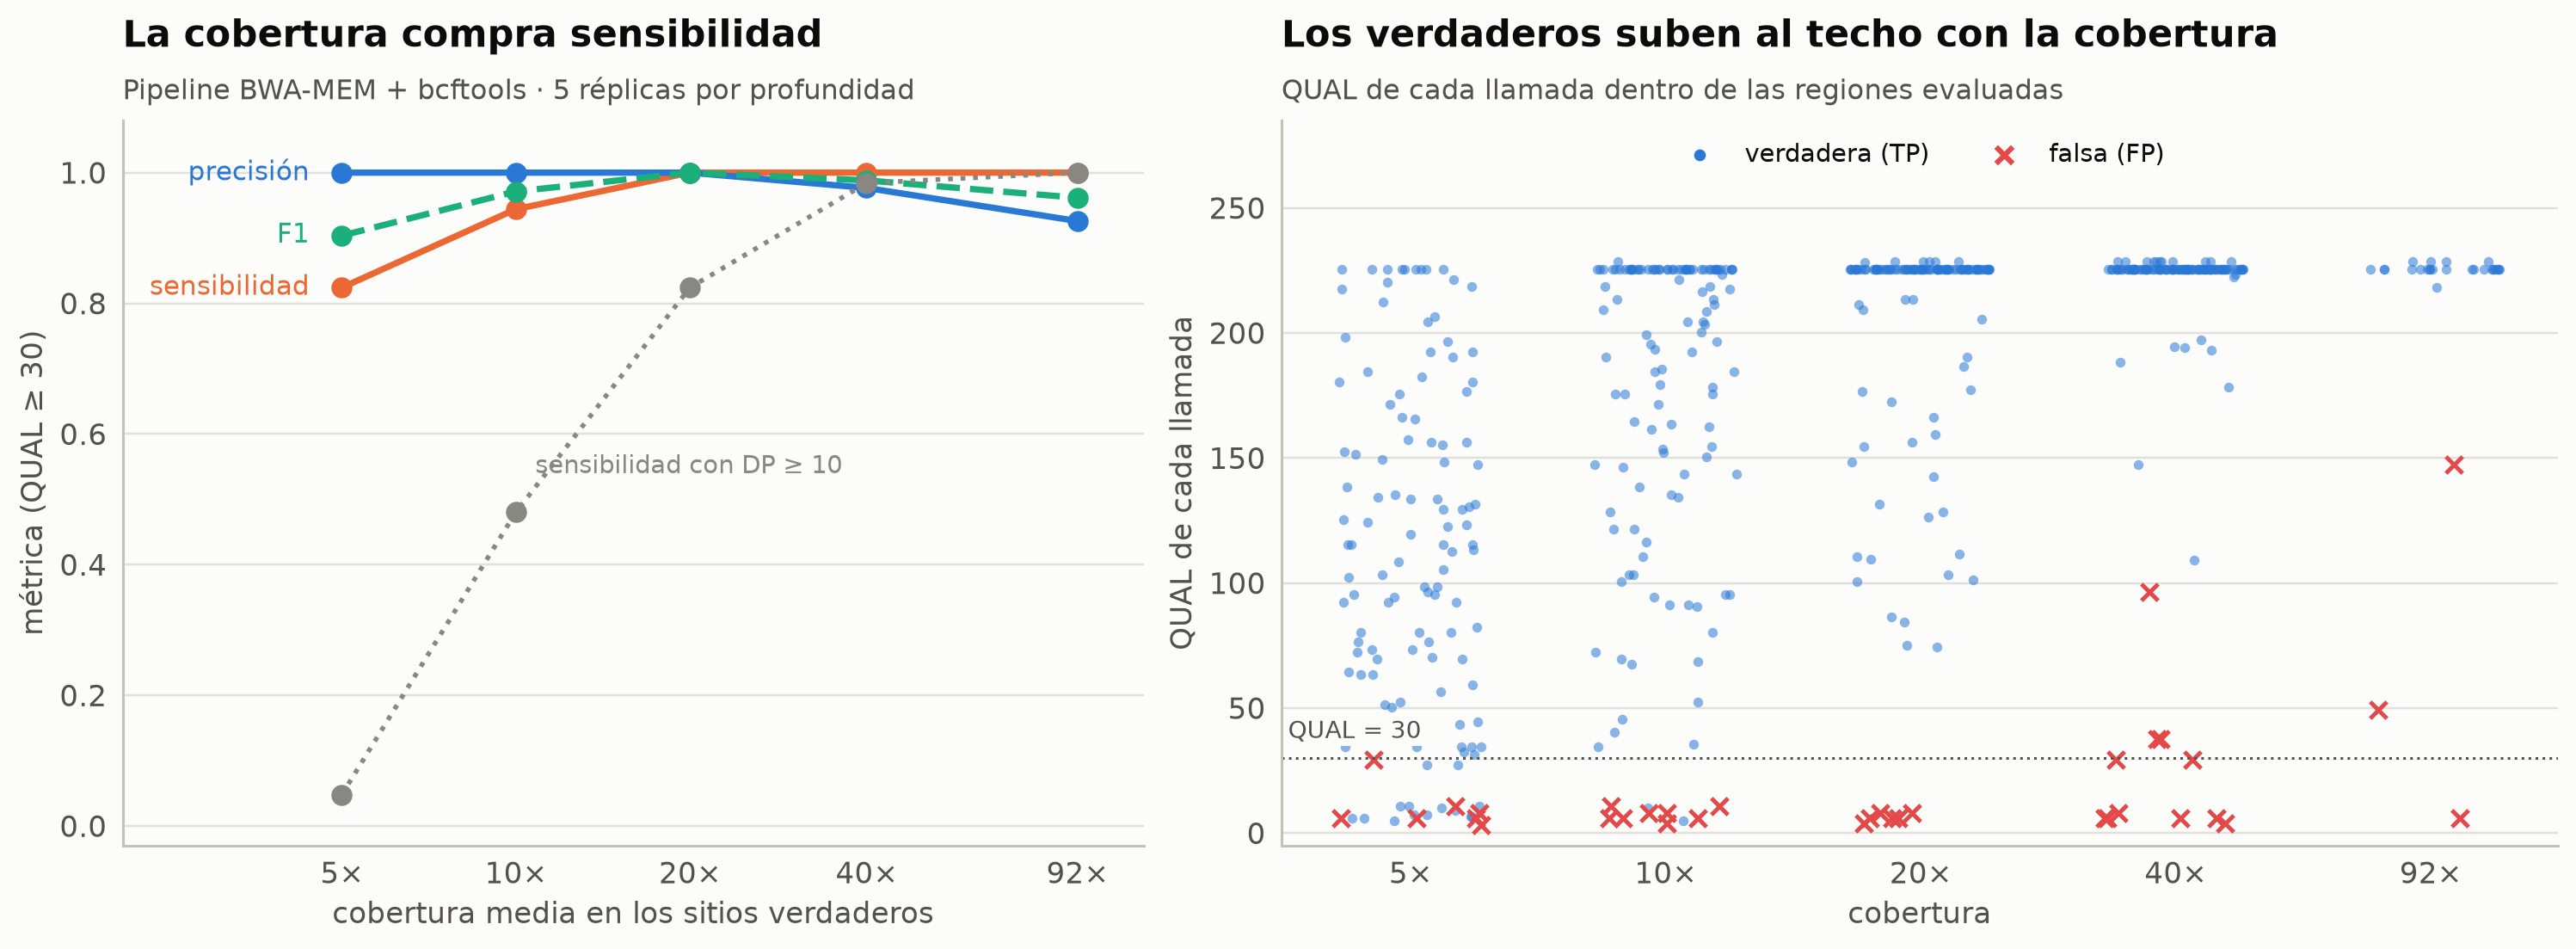

In [29]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.9), gridspec_kw=dict(width_ratios=[1, 1.25]))
r = res[res.filtro == "QUAL ≥ 30"]
xs = np.array([cov_tab[t] for t in sorted(ds.target.unique())])
for col, name, c in [("sensibilidad", "sensibilidad", ec.ORANGE), ("precisión", "precisión", ec.BLUE), ("F1", "F1", ec.AQUA)]:
    a1.plot(xs, r[col].values, marker="o", color=c, lw=2.4, ls="--" if col == "F1" else "-")
    a1.text(xs[0] * 0.88, r[col].values[0], name, va="center", ha="right", fontsize=10, color=c)
rb = res[res.filtro.str.contains("libro")]
a1.plot(xs, rb["sensibilidad"].values, marker="o", ls=":", color=ec.MUTED, lw=1.8)
a1.text(xs[1] * 1.08, rb["sensibilidad"].values[1] + 0.06, "sensibilidad con DP ≥ 10", fontsize=9.5, color=ec.MUTED)
a1.set_xscale("log"); a1.set_xticks(xs, [f"{x:.0f}×" for x in xs]); a1.minorticks_off()
a1.set_xlim(xs[0] * 0.42, xs[-1] * 1.3); a1.set_ylim(-0.03, 1.08)
a1.set_xlabel("cobertura media en los sitios verdaderos"); a1.set_ylabel("métrica (QUAL ≥ 30)")
ec.title(a1, "La cobertura compra sensibilidad", "Pipeline BWA-MEM + bcftools · 5 réplicas por profundidad")

sub = ds[(ds.pos > 0)].copy()
sub["verdad"] = [((p, r_, a) in truth) for p, r_, a in zip(sub.pos, sub.ref, sub.alt)]
sub = sub[[in_bed(p) for p in sub.pos]]
tg = sorted(sub.target.unique())
for i, t in enumerate(tg):
    g = sub[sub.target == t]
    jit = np.random.default_rng(i).uniform(-0.28, 0.28, len(g))
    a2.scatter(i + jit[g.verdad.values], g.qual[g.verdad], s=14, color=ec.BLUE, alpha=0.55, lw=0)
    a2.scatter(i + jit[~g.verdad.values], g.qual[~g.verdad], s=40, color=ec.RED, marker="x", lw=1.6)
a2.axhline(30, color=ec.INK_2, ls=":", lw=1)
a2.text(-0.48, 38, "QUAL = 30", fontsize=9, color=ec.INK_2, bbox=dict(fc=ec.SURFACE, ec="none", pad=1))
a2.set_xticks(range(len(tg)), [f"{cov_tab[t]:.0f}×" for t in tg]); a2.set_ylim(-5, 285)
a2.set_xlabel("cobertura"); a2.set_ylabel("QUAL de cada llamada")
a2.scatter([], [], s=20, color=ec.BLUE, label="verdadera (TP)"); a2.scatter([], [], s=40, color=ec.RED, marker="x", label="falsa (FP)")
a2.legend(loc="upper center", ncol=2, frameon=False, fontsize=9.5)
ec.title(a2, "Los verdaderos suben al techo con la cobertura", "QUAL de cada llamada dentro de las regiones evaluadas")
plt.show()

> 🔎 **Qué observamos.** A baja cobertura los QUAL de las mutaciones verdaderas se reparten por todo el eje (con 2–3
> lecturas un QUAL de 40–90 es lo máximo posible, como vimos en la animación), y se mezclan con los de las llamadas
> falsas. A partir de ~20× casi todas llegan al techo de 225 y la separación es limpia. Ésa es la razón práctica por la
> que los protocolos de resecuenciación bacteriana piden al menos 20–30× y los clínicos, bastante más.

## 9. Elegir el umbral de QUAL

Todo filtro establece un compromiso: subir el umbral elimina falsos positivos, pero también verdaderos. El libro lo
muestra con una simulación: **10 000 variantes verdaderas**, de las cuales el llamador propone 9 850 (las 150 restantes
nunca se llaman, por ejemplo por falta de cobertura), más **1 500 falsos positivos** con QUAL típicamente bajo. Los QUAL
de las verdaderas siguen una log-normal centrada en 180 y los de las falsas una centrada en 18. Reproducimos la
simulación con la misma semilla del generador del libro (que antes simula 40 lecturas para otra figura; repetimos esas
extracciones para que los números coincidan cifra por cifra).

In [30]:
rng_book = np.random.default_rng(909)
e30 = 10 ** (-30 / 10)
for _ in range(40):                                   # las extracciones previas del generador del libro
    allele = "A" if rng_book.random() < 0.5 else "G"
    if rng_book.random() < e30:
        rng_book.choice([x for x in "ACGT" if x != allele])
n_truth, n_tp, n_fp = 10_000, 9_850, 1_500
qual_T = np.clip(rng_book.lognormal(np.log(180), 0.75, n_tp), 3, 999)
qual_F = np.clip(rng_book.lognormal(np.log(18), 0.9, n_fp), 3, 999)

def sweep(t):
    TP, FP = (qual_T >= t).sum(), (qual_F >= t).sum()
    return (TP, FP, n_truth - TP) + metrics(TP, FP, n_truth - TP)

ts = np.concatenate([np.arange(0, 100, 1), np.arange(100, 401, 5)])
sim = pd.DataFrame([(t,) + sweep(t) for t in ts], columns=["t", "TP", "FP", "FN", "prec", "sens", "f1"])
best = sim.loc[sim.f1.idxmax()]
for t in (0, 20, 30, 50, 100):
    r = sim[sim.t == t].iloc[0]
    print(f"QUAL ≥ {t:3d}: TP {r.TP:5.0f}  FP {r.FP:5.0f}  FN {r.FN:5.0f}  precisión {r.prec:.4f}  "
          f"sensibilidad {r.sens:.4f}  F1 {r.f1:.4f}")
print(f"Máximo de F1 = {best.f1:.4f} en QUAL = {best.t:.0f}")
chk = {t: tuple(round(v, 4) for v in sim.loc[sim.t == t, ["prec", "sens"]].iloc[0]) for t in (0, 20, 30, 100)}
assert chk == {0: (0.8678, 0.985), 20: (0.9344, 0.9831), 30: (0.9568, 0.9775), 100: (0.995, 0.7742)}
assert best.t == 32 and round(best.f1, 3) == 0.968
print("✔ Coinciden con las cifras del libro")

QUAL ≥   0: TP  9850  FP  1500  FN   150  precisión 0.8678  sensibilidad 0.9850  F1 0.9227
QUAL ≥  20: TP  9831  FP   690  FN   169  precisión 0.9344  sensibilidad 0.9831  F1 0.9581
QUAL ≥  30: TP  9775  FP   441  FN   225  precisión 0.9568  sensibilidad 0.9775  F1 0.9671
QUAL ≥  50: TP  9404  FP   180  FN   596  precisión 0.9812  sensibilidad 0.9404  F1 0.9604
QUAL ≥ 100: TP  7742  FP    39  FN  2258  precisión 0.9950  sensibilidad 0.7742  F1 0.8708
Máximo de F1 = 0.9679 en QUAL = 32
✔ Coinciden con las cifras del libro


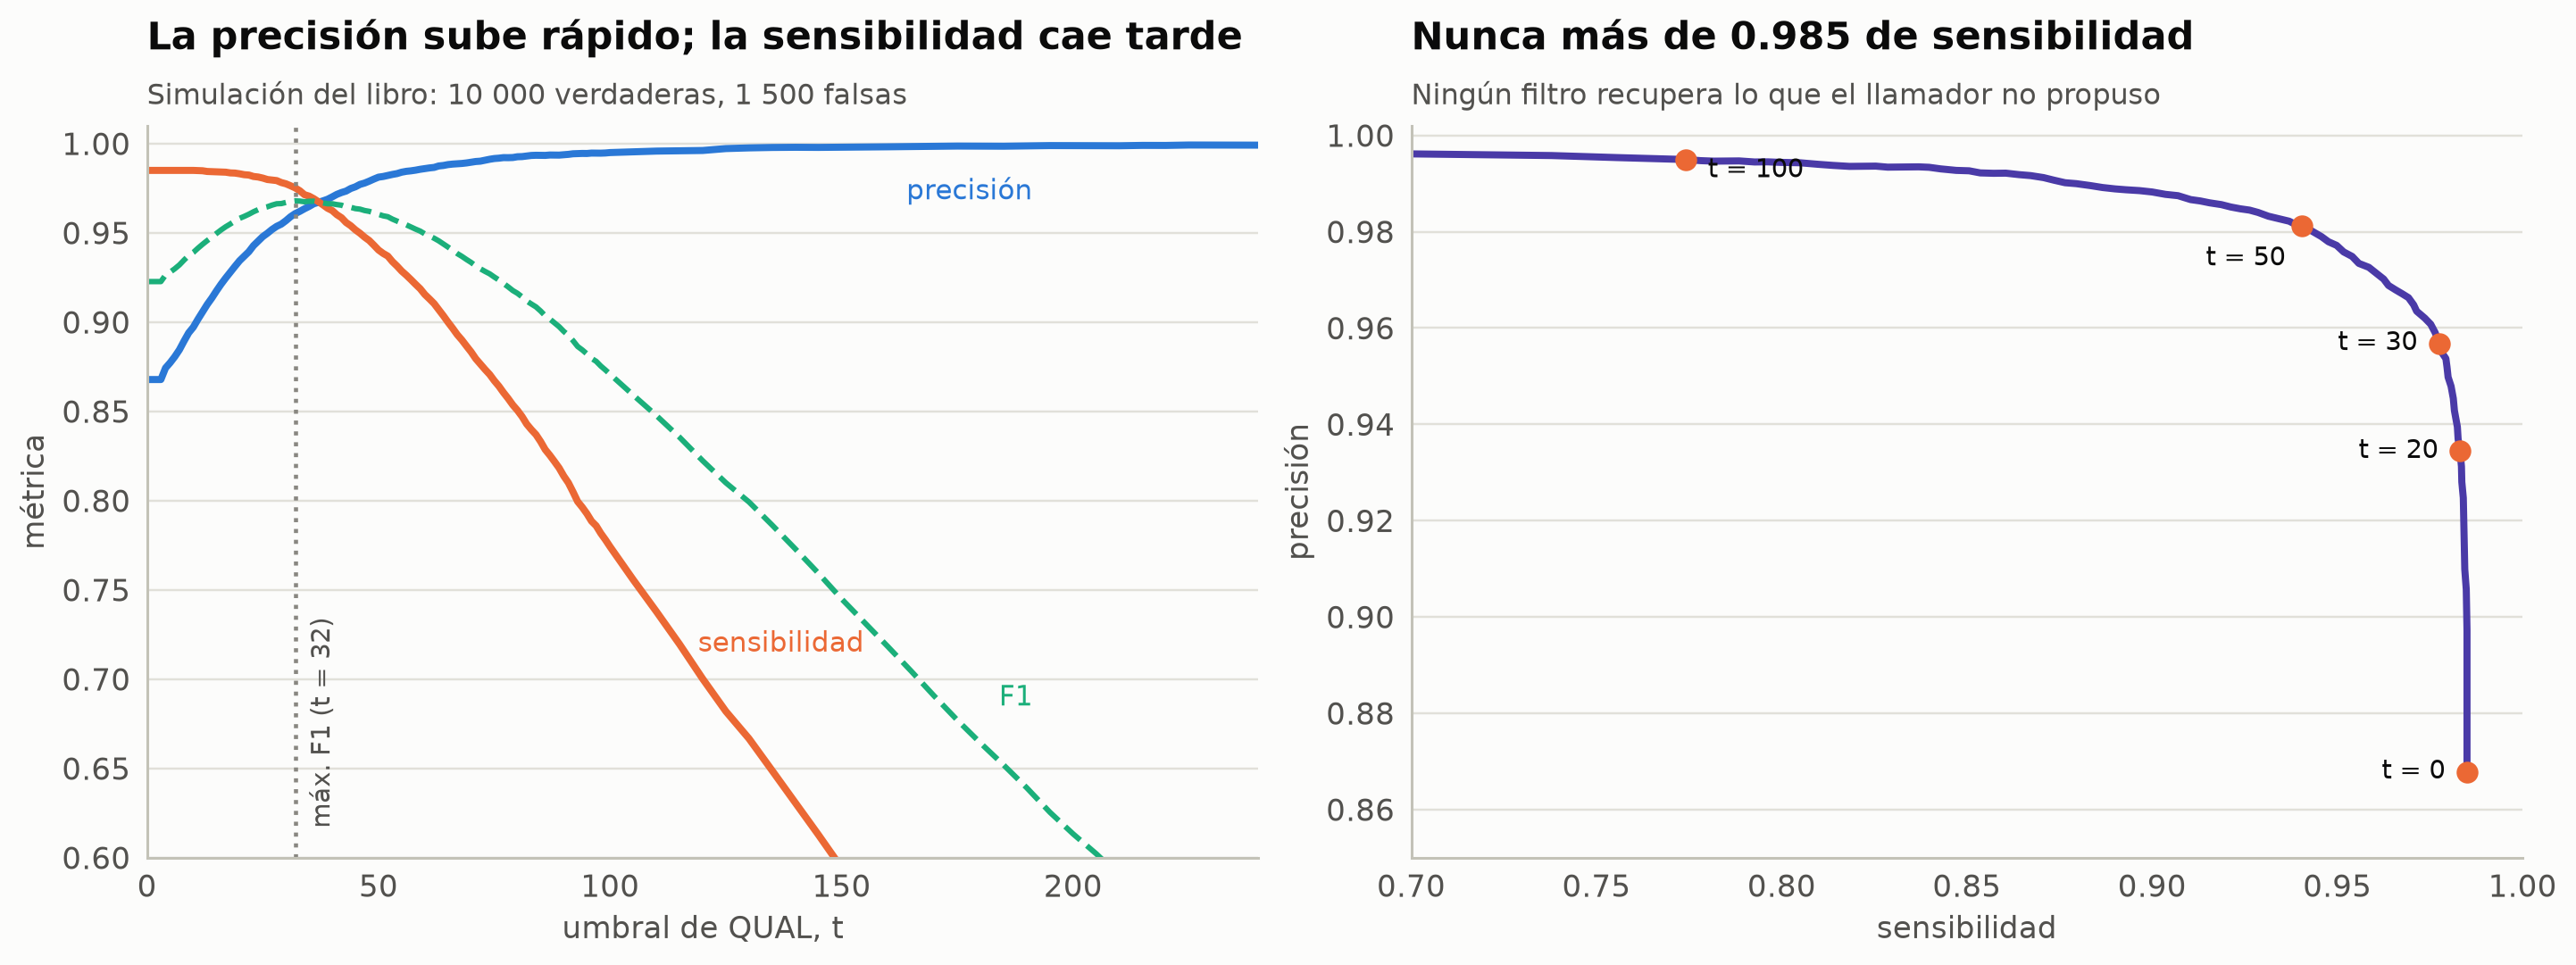

In [31]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.8))
a1.plot(sim.t, sim.prec, color=ec.BLUE, lw=2.6); a1.plot(sim.t, sim.sens, color=ec.ORANGE, lw=2.6)
a1.plot(sim.t, sim.f1, color=ec.AQUA, lw=2, ls="--")
a1.axvline(32, color=ec.MUTED, ls=":", lw=1.5); a1.text(35, 0.62, "máx. F1 (t = 32)", rotation=90, fontsize=9.5, color=ec.INK_2)
for col, name, c, tl, dy in [("prec", "precisión", ec.BLUE, 160, -0.025), ("sens", "sensibilidad", ec.ORANGE, 115, 0.0),
                             ("f1", "F1", ec.AQUA, 180, 0.025)]:
    a1.text(tl + 4, sim.loc[sim.t == tl, col].iloc[0] + dy, name, fontsize=10, color=c, va="center")
a1.set_xlim(0, 240); a1.set_ylim(0.6, 1.01); a1.set_xlabel("umbral de QUAL, t"); a1.set_ylabel("métrica")
ec.title(a1, "La precisión sube rápido; la sensibilidad cae tarde", "Simulación del libro: 10 000 verdaderas, 1 500 falsas")
a2.plot(sim.sens, sim.prec, color=ec.VIOLET, lw=2.6)
marks = {0: ("t = 0", (-8, 0), "right"), 20: ("t = 20", (-8, 0), "right"), 30: ("t = 30", (-8, 0), "right"),
         50: ("t = 50", (-6, -12), "right"), 100: ("t = 100", (8, -4), "left")}
for t, (lab, off, ha) in marks.items():
    r = sim[sim.t == t].iloc[0]
    a2.plot(r.sens, r.prec, "o", color=ec.ORANGE, ms=7)
    a2.annotate(lab, (r.sens, r.prec), xytext=off, textcoords="offset points", ha=ha, va="center", fontsize=9.5)
a2.set_xlim(0.7, 1.0); a2.set_ylim(0.85, 1.002); a2.set_xlabel("sensibilidad"); a2.set_ylabel("precisión")
ec.title(a2, "Nunca más de 0.985 de sensibilidad", "Ningún filtro recupera lo que el llamador no propuso")
plt.show()

> 🔎 **Qué observamos.** Sin filtro, la precisión es 0.868 y la sensibilidad 0.985. Con QUAL ≥ 20 la precisión sube a
> 0.934 perdiendo apenas 19 verdaderos; con QUAL ≥ 30 llega a 0.957 con sensibilidad 0.978. El máximo de $F_1$ (0.968)
> se alcanza hacia QUAL = 32. Más allá, cada unidad de precisión se paga cara: con QUAL ≥ 100 la precisión es 0.995,
> pero la sensibilidad se desploma a 0.774. La animación muestra por qué: el umbral barre primero la montaña de los
> falsos (QUAL bajo) y sólo después empieza a morder la de los verdaderos.

![El umbral de QUAL recorre las dos distribuciones (izquierda) y el punto de trabajo se desplaza por la curva precisión-sensibilidad (derecha)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-09-variantes/9.2_umbral_pr.gif)

*El umbral de QUAL recorre las dos distribuciones (izquierda) y el punto de trabajo se desplaza por la curva precisión-sensibilidad (derecha)*

In [32]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.9))
bins = np.logspace(np.log10(3), np.log10(1000), 50)
t_frames = np.unique(np.round(np.concatenate([np.linspace(0, 60, 31), np.linspace(62, 200, 19)])))
def draw_thr(t):
    a1.clear(); a2.clear()
    a1.hist(qual_T, bins=bins, color=ec.BLUE, alpha=0.55, label="verdaderas")
    a1.hist(qual_F, bins=bins, color=ec.RED, alpha=0.55, label="falsas")
    a1.axvspan(3, max(t, 3), color=ec.INK, alpha=0.08)
    a1.axvline(max(t, 3), color=ec.INK, lw=2)
    a1.set_xscale("log"); a1.set_xlim(3, 1000); a1.set_ylim(0, 820)
    a1.set_xlabel("QUAL (escala log)"); a1.set_ylabel("variantes")
    a1.legend(loc="upper right", frameon=False)
    r = sim.iloc[(sim.t - t).abs().argmin()]
    a1.text(3.4, 760, f"t = {t:.0f}: se descartan {n_fp - r.FP:.0f} falsas y {n_tp - r.TP:.0f} verdaderas",
            fontsize=10, color=ec.INK)
    ec.title(a1, "El umbral barre las falsas primero", "Zona gris: llamadas descartadas por QUAL < t")
    a2.plot(sim.sens, sim.prec, color=ec.VIOLET, lw=2.2, alpha=0.5)
    a2.plot(r.sens, r.prec, "o", color=ec.ORANGE, ms=12)
    a2.text(0.705, 0.99, f"precisión {r.prec:.3f}\nsensibilidad {r.sens:.3f}\nF1 {r.f1:.3f}", va="top", fontsize=11,
            color=ec.INK, family="monospace")
    a2.set_xlim(0.7, 1.0); a2.set_ylim(0.85, 1.002); a2.set_xlabel("sensibilidad"); a2.set_ylabel("precisión")
    ec.title(a2, "El punto de trabajo recorre la curva", "Máximo de F1 en t = 32")
    return []
ec.animate(fig, draw_thr, frames=t_frames, interval=160, name="9.2_umbral_pr")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### ¿Y en nuestro clon?

Busquemos el umbral que maximiza $F_1$ en cada profundidad de nuestro mini-GIAB, y cuánto cambia la decisión.

In [33]:
rows = []
for tgt, cdf in curves.items():
    b = cdf.loc[cdf.f1.idxmax()]
    tie = cdf[np.isclose(cdf.f1, b.f1)]
    r30 = cdf[cdf.t == 30].iloc[0]
    rows.append(dict(cobertura=f"{cov_tab[tgt]:.0f}×", **{"QUAL óptimo (rango)": f"{tie.t.min():.0f}–{tie.t.max():.0f}"},
                     F1_max=b.f1, prec_opt=b.prec, sens_opt=b.sens, F1_Q30=r30.f1, prec_Q30=r30.prec, sens_Q30=r30.sens))
choice = pd.DataFrame(rows)
print(choice.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

cobertura QUAL óptimo (rango)  F1_max  prec_opt  sens_opt  F1_Q30  prec_Q30  sens_Q30
       5×                 3–5   0.944     0.951     0.936   0.904     1.000     0.824
      10×               11–34   0.971     1.000     0.944   0.971     1.000     0.944
      20×                8–74   1.000     1.000     1.000   1.000     1.000     1.000
      40×              97–109   1.000     1.000     1.000   0.988     0.977     1.000
      92×             148–218   1.000     1.000     1.000   0.962     0.926     1.000


> 🔎 **Qué observamos.** El umbral óptimo **crece con la cobertura**. A 5× lo mejor es aceptar casi todo (QUAL ≥ ~5):
> apenas hay falsos positivos y las mutaciones verdaderas, con 2–4 lecturas, tienen QUAL bajo. A ~90× las verdaderas
> están todas en el techo de 225 y los falsos (sitios con pocas lecturas) quedan por debajo de ~150, así que un umbral
> alto los separa. La razón es la de la animación de la sección 4: **el QUAL mide cuántas lecturas coinciden**, de
> modo que un mismo umbral significa cosas distintas a distinta cobertura.
>
> Pero ojo con leer demasiado en estos "óptimos": con 25 verdaderas y uno o dos falsos, basta una llamada para mover el
> umbral de ~100 a ~150. Elegir un umbral así, sobre tan pocos datos, es **sobreajustarlo**. Por eso GIAB tiene millones
> de variantes, y por eso en nuestro clon el filtro de profundidad **relativa** fue más robusto que cualquier QUAL.

**¿Cómo se elige el umbral en la práctica?** No hay un número universal; depende del uso:

| Uso | Prioridad | Consecuencia |
|---|---|---|
| cribado clínico de primera línea (lo que se encuentre se confirma por Sanger) | **sensibilidad**: no perder una variante causal | umbral bajo; se tolera algún falso positivo |
| catálogo de referencia o base de datos pública | **precisión**: no contaminar a otros usuarios | umbral alto |
| confirmar las mutaciones de un clon del LTEE | ambas, con pocas variantes y mucha cobertura | QUAL ≥ 30 + DP relativo + revisión manual de lo dudoso |

Y siempre: elegir el umbral con datos **de verdad** (GIAB, una muestra de referencia propia o, como aquí, un conjunto de
alta cobertura), a la **cobertura real** del protocolo, y por separado para SNV e *indels*.

> ✅ **Compruebe su comprensión.** Un colega dice: "Subí el umbral de QUAL a 100 y la precisión pasó de 0.957 a 0.995;
> ¡mucho mejor!". Con la simulación del libro, ¿qué le respondería? *(Que perdió 2 033 variantes verdaderas: la
> sensibilidad bajó de 0.978 a 0.774 y el $F_1$ de 0.967 a 0.871. "Mejor" depende del uso, y hay que informar ambas
> métricas.)*

## 10. Ejercicios

**Ejercicio 1 — Normalizar una inserción a mano.** En la referencia del libro `GGATCACACACAGT`, un individuo tiene
**cinco** unidades `CA` en lugar de cuatro. Un llamador lo escribió como `POS=12, REF=A, ALT=ACA`. (a) Compruebe que
el registro es válido (que `REF` coincide con la referencia). (b) Normalícelo a mano con los dos pasos del algoritmo y
verifique su respuesta con `normalize`. (c) Escriba otra representación del mismo haplotipo, anclada en otra posición.

**Ejercicio 2 — Leer un registro dudoso.** Con la tabla `calls100`, examine la inserción de 3 901 455. Calcule la
fracción de lecturas alternativas y la fracción de las alternativas que están en la hebra directa (use `DP4`). ¿Qué
diría a un investigador que pregunta si es una mutación real? ¿Qué haría para confirmarlo?

**Ejercicio 3 — El termómetro en un exoma.** En un exoma humano ($R_T \approx 3.0$) usted observa $R_\text{obs} = 2.6$.
Estime la fracción de falsos positivos con la ecuación 09-titv. ¿Y si $R_\text{obs}=2.0$? Compare con un genoma completo
($R_T=2.1$) que baja a 1.8.

**Ejercicio 4 — Un informe de hap.py para *indels*.** Para el mismo llamador del ejemplo del libro, el informe de
*indels* (cifras hipotéticas) dice $\mathrm{TP}=480\,000$, $\mathrm{FP}=4\,100$ y $\mathrm{FN}=12\,300$. Calcule precisión,
sensibilidad y $F_1$ y compárelas con las de SNV. ¿Por qué se informan por separado?

**Ejercicio 5 — Otro filtro.** Escriba la orden `bcftools filter` que marque como `BajaCal` los sitios con
`QUAL<30`, `INFO/DP<10` **o** una profundidad mayor que la media más cuatro desviaciones de Poisson (calcúlela con las
llamadas seguras). Aplíquela en Python a `calls100` y cuente cuántas llamadas pasan. ¿Cambia algo respecto al filtro del
libro? ¿En qué tipo de genoma cambiaría mucho?

**Ejercicio 6 — Mover el techo.** Prediga el QUAL máximo de `bcftools call --ploidy 1 -mv -P 0.01`. Si tiene las
herramientas, ejecútelo sobre `pl.bcf` y compruébelo; si no, calcúlelo con la fórmula de la sección 4.

In [34]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
G = "GGATCACACACAGT"
print("(a) base 12 de la referencia:", G[11], "→ REF = A es válido")
hap1 = G[:11] + "ACA" + G[12:]
print("    haplotipo:", hap1, "(cinco CA)")
print("(b) paso 1: A/ACA terminan en A → ∅/AC; REF vacío → antepone la base 11 (C): 11 C/CAC → ∅/CA → 10 A/ACA … → 4 T/TCA")
print("    normalize:", normalize(12, "A", "ACA", G, trace=True))
# (c) por ejemplo, insertar "AC" tras la base 5 (C): POS=5 REF=C ALT=CAC
alt_rep = (5, "C", "CAC")
print("(c)", alt_rep, "→ haplotipo", G[:4] + "CAC" + G[5:], "igual:", G[:4] + "CAC" + G[5:] == hap1,
      "→ normalizado", normalize(*alt_rep, G))

(a) base 12 de la referencia: A → REF = A es válido
    haplotipo: GGATCACACACACAGT (cinco CA)
(b) paso 1: A/ACA terminan en A → ∅/AC; REF vacío → antepone la base 11 (C): 11 C/CAC → ∅/CA → 10 A/ACA … → 4 T/TCA
   POS=12  REF=A      ALT=ACA    inicio
   POS=12  REF=∅      ALT=AC     recorta la última base común
   POS=11  REF=C      ALT=CAC    alelo vacío: antepone la base 11 (C)
   POS=11  REF=∅      ALT=CA     recorta la última base común
   POS=10  REF=A      ALT=ACA    alelo vacío: antepone la base 10 (A)
   POS=10  REF=∅      ALT=AC     recorta la última base común
   POS=9   REF=C      ALT=CAC    alelo vacío: antepone la base 9 (C)
   POS=9   REF=∅      ALT=CA     recorta la última base común
   POS=8   REF=A      ALT=ACA    alelo vacío: antepone la base 8 (A)
   POS=8   REF=∅      ALT=AC     recorta la última base común
   POS=7   REF=C      ALT=CAC    alelo vacío: antepone la base 7 (C)
   POS=7   REF=∅      ALT=CA     recorta la última base común
   POS=6   REF=A      ALT=ACA 

In [35]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
r = calls100[calls100.pos == 3_901_455].iloc[0]
rf, rr, af, ar = r.dp4
print(f"{r.ref}→{r.alt} · QUAL {r.qual:.1f} · DP {r.dp} · AD {r.ad} · DP4 {r.dp4}")
print(f"fracción alternativa = {(af + ar) / (rf + rr + af + ar):.2f} · alternativas en hebra directa = {af / (af + ar):.2f}")
print("Todas las lecturas apoyan la inserción (esperable en un haploide clonal), pero TODAS vienen de la misma hebra y la")
print("profundidad (11) es ~1/6 de la típica: señales de artefacto (sesgo de hebra, VDB muy pequeño). Pasa el filtro")
print("del libro, pero yo la entregaría como 'por confirmar' (por eso quedó fuera del conjunto de verdad, sección 8):")
print("revisar el pileup (IGV), llamar con otro mapeador y, si importa biológicamente, confirmar por PCR y Sanger.")

A→AC · QUAL 166.4 · DP 11 · AD (0, 11) · DP4 (0, 0, 11, 0)
fracción alternativa = 1.00 · alternativas en hebra directa = 1.00
Todas las lecturas apoyan la inserción (esperable en un haploide clonal), pero TODAS vienen de la misma hebra y la
profundidad (11) es ~1/6 de la típica: señales de artefacto (sesgo de hebra, VDB muy pequeño). Pasa el filtro
del libro, pero yo la entregaría como 'por confirmar' (por eso quedó fuera del conjunto de verdad, sección 8):
revisar el pileup (IGV), llamar con otro mapeador y, si importa biológicamente, confirmar por PCR y Sanger.


In [36]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for R_T, R_obs in [(3.0, 2.6), (3.0, 2.0), (2.1, 1.8)]:
    print(f"R_T = {R_T}, R_obs = {R_obs}: α = {alpha_fp(R_obs, R_T):.3f}")
print("En el exoma la misma caída relativa implica menos falsos que en el genoma porque p_T está más lejos de p_F;")
print("pero bajar de 3.0 a 2.0 ya supone ~20 % de sitios falsos.")

R_T = 3.0, R_obs = 2.6: α = 0.067
R_T = 3.0, R_obs = 2.0: α = 0.200
R_T = 2.1, R_obs = 1.8: α = 0.100
En el exoma la misma caída relativa implica menos falsos que en el genoma porque p_T está más lejos de p_F;
pero bajar de 3.0 a 2.0 ya supone ~20 % de sitios falsos.


In [37]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
p_i, s_i, f_i = metrics(480_000, 4_100, 12_300)
p_s, s_s, f_s = metrics(3_290_000, 9_800, 21_500)
print(f"indels: precisión {p_i:.4f} · sensibilidad {s_i:.4f} · F1 {f_i:.4f}")
print(f"SNV   : precisión {p_s:.4f} · sensibilidad {s_s:.4f} · F1 {f_s:.4f}")
print("Los indels son más difíciles (repeticiones, homopolímeros, representación ambigua); si se mezclaran con las SNV,")
print("los ~3.3 millones de SNV esconderían un rendimiento peor en indels.")

indels: precisión 0.9915 · sensibilidad 0.9750 · F1 0.9832
SNV   : precisión 0.9970 · sensibilidad 0.9935 · F1 0.9953
Los indels son más difíciles (repeticiones, homopolímeros, representación ambigua); si se mezclaran con las SNV,
los ~3.3 millones de SNV esconderían un rendimiento peor en indels.


In [38]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
mean_dp = calls100.loc[calls100.qual > 200, "dp"].mean()
max_dp = mean_dp + 4 * math.sqrt(mean_dp)
print(f"bcftools filter -s BajaCal -e 'QUAL<30 || INFO/DP<10 || INFO/DP>{max_dp:.0f}' -Oz -o final2.vcf.gz norm.bcf")
m = (calls100.qual < 30) | (calls100.dp < 10) | (calls100.dp > max_dp)
print(f"PASS: {(~m).sum()} (filtro del libro: {(calls100.filter_book == 'PASS').sum()})")
print("No cambia nada aquí: el racimo Ldr era un hueco (DP bajo), no un colapso de copias. En un genoma humano, donde las")
print("duplicaciones segmentarias ausentes de la referencia producen DP excesivo, el máximo elimina muchos falsos (Li, 2014).")

bcftools filter -s BajaCal -e 'QUAL<30 || INFO/DP<10 || INFO/DP>92' -Oz -o final2.vcf.gz norm.bcf
PASS: 26 (filtro del libro: 26)
No cambia nada aquí: el racimo Ldr era un hueco (DP bajo), no un colapso de copias. En un genoma humano, donde las
duplicaciones segmentarias ausentes de la referencia producen DP excesivo, el máximo elimina muchos falsos (Li, 2014).


In [39]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
pred = 4.343 * math.log(1 + 0.01 * 10 ** 25.5)
print(f"Predicción: 255 + 10·log10(0.01) = {pred:.3f}")
if HAS_TOOLS:
    out = sh("bcftools call --ploidy 1 -mv -P 0.01 pl.bcf | grep -v '^#' | cut -f6 | sort | uniq -c | sort -nr | head -3",
             quiet=True)[0]
    print("QUAL más frecuentes con -P 0.01 (número de llamadas, QUAL):")
    print(out)

Predicción: 255 + 10·log10(0.01) = 235.003
QUAL más frecuentes con -P 0.01 (número de llamadas, QUAL):
  20 235.003
   3 4.77888
   2 40.0009



## 📌 Resumen

* Un **VCF** se describe a sí mismo: la cabecera `##` declara cada campo; el cuerpo tiene ocho columnas fijas, `FORMAT`
  y una columna por muestra. `POS` es 1-based, los *indels* llevan base de anclaje y un sitio con $k$ alelos tiene
  $\binom{k+m-1}{m}$ PL ($m$ = ploidía).
* El flujo del libro (`mpileup -f -q 20 -Q 20 -a FORMAT/AD,FORMAT/DP` → `call -mv` → `norm -f -m -any` → `filter` →
  `stats`) corrió en segundos sobre lecturas reales del clon del LTEE. Para una bacteria, `--ploidy 1`.
* **QUAL = 225.417** no es casualidad: `mpileup` recorta los PL a 255 y `call` resta el precio de la *a priori*,
  $10\log_{10}(1.1\times10^{-3}) \approx -29.6$. Por encima de ~225 el QUAL de `bcftools` ya no ordena llamadas. El aviso
  `MQ should be declared as Type=Float` es cosmético.
* **Normalizar** (Tan *et al.*, 2015) hace única la representación de cada variante: parsimoniosa y alineada a la
  izquierda. Sin ello, comparar dos VCF produce falsos FP y FN a la vez.
* El **racimo Ldr** fue un caso real de falsas SNV por lecturas mal ubicadas entre copias parálogas junto a un probable
  hueco de ~530 pb: no lo detectaron ni QUAL ni MQ, sí la profundidad relativa (y un segundo mapeador).
* La **ti/tv** es un termómetro útil sólo si está calibrado: la del clon es ~0.33 (espectro dominado por A:T→C:G) y los
  falsos positivos la **suben**.
* La evaluación rigurosa exige una **verdad** y regiones de confianza (GIAB, hap.py): precisión, sensibilidad y $F_1$,
  por separado para SNV e *indels*. En nuestro mini-GIAB la cobertura decidió la sensibilidad, y un filtro `DP ≥ 10`
  pensado para 30× destruyó el llamado a 5–10×.
* El **umbral de QUAL** se elige con una curva precisión-sensibilidad, para una cobertura y un uso concretos, sobre
  suficientes datos para no sobreajustarlo.

## 📚 Lecturas y referencias

* Danecek, P. *et al.* (2011). The variant call format and VCFtools. *Bioinformatics* 27(15):2156–2158.
  [doi:10.1093/bioinformatics/btr330](https://doi.org/10.1093/bioinformatics/btr330)
* Danecek, P. *et al.* (2021). Twelve years of SAMtools and BCFtools. *GigaScience* 10(2):giab008.
  [doi:10.1093/gigascience/giab008](https://doi.org/10.1093/gigascience/giab008)
* Li, H. (2011). A statistical framework for SNP calling, mutation discovery, association mapping and population
  genetical parameter estimation from sequencing data. *Bioinformatics* 27(21):2987–2993.
  [doi:10.1093/bioinformatics/btr509](https://doi.org/10.1093/bioinformatics/btr509)
* Tan, A., Abecasis, G. R. y Kang, H. M. (2015). Unified representation of genetic variants. *Bioinformatics*
  31(13):2202–2204. [doi:10.1093/bioinformatics/btv112](https://doi.org/10.1093/bioinformatics/btv112)
* Li, H. (2014). Toward better understanding of artifacts in variant calling from high-coverage samples.
  *Bioinformatics* 30(20):2843–2851. [doi:10.1093/bioinformatics/btu356](https://doi.org/10.1093/bioinformatics/btu356)
* DePristo, M. A. *et al.* (2011). A framework for variation discovery and genotyping using next-generation DNA
  sequencing data. *Nature Genetics* 43(5):491–498. [doi:10.1038/ng.806](https://doi.org/10.1038/ng.806)
* Zook, J. M. *et al.* (2014). Integrating human sequence data sets provides a resource of benchmark SNP and indel
  genotype calls. *Nature Biotechnology* 32(3):246–251. [doi:10.1038/nbt.2835](https://doi.org/10.1038/nbt.2835)
* Zook, J. M. *et al.* (2019). An open resource for accurately benchmarking small variant and reference calls.
  *Nature Biotechnology* 37(5):561–566. [doi:10.1038/s41587-019-0074-6](https://doi.org/10.1038/s41587-019-0074-6)
* Krusche, P. *et al.* (2019). Best practices for benchmarking germline small-variant calls in human genomes.
  *Nature Biotechnology* 37(5):555–560. [doi:10.1038/s41587-019-0054-x](https://doi.org/10.1038/s41587-019-0054-x)
* Nielsen, R., Paul, J. S., Albrechtsen, A. y Song, Y. S. (2011). Genotype and SNP calling from next-generation
  sequencing data. *Nature Reviews Genetics* 12(6):443–451. [doi:10.1038/nrg2986](https://doi.org/10.1038/nrg2986)
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*
  536:165–170. [doi:10.1038/nature18959](https://doi.org/10.1038/nature18959) (origen de las lecturas SRR2584863)
* Documentación de bcftools: [samtools.github.io/bcftools/bcftools.html](https://samtools.github.io/bcftools/bcftools.html)
  y su código fuente ([github.com/samtools/bcftools](https://github.com/samtools/bcftools): `bam2bcf.c`, `mcall.c`).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)